In [1]:
# ============================================================
# KDD WORKSHOP PAPER FIGURE GENERATION SCRIPT
# QuadHDR Visualization Suite
# ============================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

# ------------------------------------------------------------
# PATHS
# ------------------------------------------------------------

BASE_DIR = "seoul_station_multimodal/results"

RECON_PATH = f"{BASE_DIR}/quad_reconstructed_hidden_demand_result.csv"
QUAD_PATH = f"{BASE_DIR}/quad_latent_decomposition.csv"

os.makedirs(BASE_DIR, exist_ok=True)

# ------------------------------------------------------------
# LOAD
# ------------------------------------------------------------

recon = pd.read_csv(RECON_PATH)
quad = pd.read_csv(QUAD_PATH)

print(recon.shape)
print(quad.shape)

# ============================================================
# FIGURE 1
# QUAD RECONSTRUCTION SPACE
# ============================================================

plt.figure(figsize=(10, 8))

label_colors = {
    "High Priority Hidden Demand": "red",
    "Potential Hidden Demand": "orange",
    "Already Captured Core Demand": "blue",
    "Transit-Dominant Demand": "green",
    "Low Priority": "gray",
    "Morphology-Supported Hidden Demand": "purple",
}

for lab, sub in recon.groupby("reconstruction_label"):

    plt.scatter(
        sub["axis_mobility_demand_score"],
        sub["axis_observed_subway_score"],
        s=55,
        alpha=0.75,
        label=lab,
        color=label_colors.get(lab, None),
    )

plt.axline((0.5, 0), (0.5, 1), linestyle="--", alpha=0.5)
plt.axline((0, 0.5), (1, 0.5), linestyle="--", alpha=0.5)

plt.xlabel("Mobility Demand Score")
plt.ylabel("Observed Subway Score")

plt.title("QuadHDR Reconstruction Space")

plt.legend(fontsize=8)

plt.tight_layout()

save_path = f"{BASE_DIR}/quad_reconstruction_space.png"

plt.savefig(save_path, dpi=300)
plt.close()

print("Saved:", save_path)

# ============================================================
# FIGURE 2
# BASELINE COMPARISON BARPLOT
# ============================================================

baseline_csv = f"{BASE_DIR}/baseline_reconstruction_comparison.csv"

if os.path.exists(baseline_csv):

    baseline = pd.read_csv(baseline_csv)

    plt.figure(figsize=(9, 5))

    x = np.arange(len(baseline))

    plt.bar(
        x,
        baseline["spearman_with_gap"],
    )

    plt.xticks(
        x,
        baseline["method"],
        rotation=35,
        ha="right",
    )

    plt.ylabel("Spearman Correlation")

    plt.title("Baseline Comparison")

    plt.tight_layout()

    save_path = f"{BASE_DIR}/baseline_reconstruction_comparison.png"

    plt.savefig(save_path, dpi=300)
    plt.close()

    print("Saved:", save_path)

# ============================================================
# FIGURE 3
# WEIGHT SENSITIVITY
# ============================================================

weight_csv = f"{BASE_DIR}/weight_sensitivity_results.csv"

if os.path.exists(weight_csv):

    weight_df = pd.read_csv(weight_csv)

    plt.figure(figsize=(8, 5))

    plt.hist(
        weight_df["spearman_with_gap"],
        bins=20,
    )

    plt.xlabel("Spearman Correlation")
    plt.ylabel("Count")

    plt.title("Weight Sensitivity Distribution")

    plt.tight_layout()

    save_path = f"{BASE_DIR}/weight_sensitivity_distribution.png"

    plt.savefig(save_path, dpi=300)
    plt.close()

    print("Saved:", save_path)

# ============================================================
# FIGURE 4
# TOP STATION ROBUSTNESS
# ============================================================

robust_csv = f"{BASE_DIR}/top_station_robustness.csv"

if os.path.exists(robust_csv):

    robust = pd.read_csv(robust_csv)

    robust = robust.sort_values(
        "top10_frequency",
        ascending=False,
    ).head(15)

    plt.figure(figsize=(9, 6))

    plt.barh(
        robust["station_name"],
        robust["top10_frequency"],
    )

    plt.gca().invert_yaxis()

    plt.xlabel("Top-10 Frequency")

    plt.title("Robust Hidden-Demand Stations")

    plt.tight_layout()

    save_path = f"{BASE_DIR}/top_station_robustness.png"

    plt.savefig(save_path, dpi=300)
    plt.close()

    print("Saved:", save_path)

# ============================================================
# FIGURE 5
# SEMANTIC PROFILE
# ============================================================

semantic_csv = f"{BASE_DIR}/hidden_demand_semantic_profile.csv"

if os.path.exists(semantic_csv):

    sem = pd.read_csv(semantic_csv)

    sem = sem.sort_values(
        "mean_similarity",
        ascending=True,
    )

    plt.figure(figsize=(8, 6))

    plt.barh(
        sem["semantic_prompt"],
        sem["mean_similarity"],
    )

    plt.xlabel("Mean Similarity")

    plt.title("Hidden-Demand Semantic Profile")

    plt.tight_layout()

    save_path = f"{BASE_DIR}/hidden_demand_semantic_profile.png"

    plt.savefig(save_path, dpi=300)
    plt.close()

    print("Saved:", save_path)

# ============================================================
# FIGURE 6
# HIDDEN VS NON-HIDDEN DIFFERENCE
# ============================================================

diff_csv = f"{BASE_DIR}/hidden_vs_nonhidden_semantic_difference.csv"

if os.path.exists(diff_csv):

    diff = pd.read_csv(diff_csv)

    diff = diff.sort_values(
        "difference_hidden_minus_nonhidden",
        ascending=True,
    )

    plt.figure(figsize=(8, 6))

    plt.barh(
        diff["semantic_prompt"],
        diff["difference_hidden_minus_nonhidden"],
    )

    plt.xlabel("Difference")

    plt.title("Hidden vs Non-Hidden Semantic Difference")

    plt.tight_layout()

    save_path = f"{BASE_DIR}/hidden_vs_nonhidden_semantic_difference.png"

    plt.savefig(save_path, dpi=300)
    plt.close()

    print("Saved:", save_path)

# ============================================================
# FIGURE 7
# CASE STUDY MULTI-PANEL FIGURE
# ============================================================

TOPK = 5

top_df = recon.sort_values(
    "hidden_demand_reconstruction_score_norm",
    ascending=False,
).head(TOPK)

MAP_DIR = "images/station_tiles/map"
SAT_DIR = "images/station_tiles/satellite"

fig, axes = plt.subplots(
    TOPK,
    4,
    figsize=(14, TOPK * 3.5),
)

for i, (_, row) in enumerate(top_df.iterrows()):

    sid = row["station_id"]
    name = row["nearest_station"]

    map_path = f"{MAP_DIR}/{sid}_{name}.png"
    sat_path = f"{SAT_DIR}/{sid}_{name}.png"

    # --------------------------------------------------------
    # MAP
    # --------------------------------------------------------

    if os.path.exists(map_path):

        img = Image.open(map_path)

        axes[i, 0].imshow(img)

    axes[i, 0].axis("off")

    axes[i, 0].set_title(f"{name}\nMap")

    # --------------------------------------------------------
    # SATELLITE
    # --------------------------------------------------------

    if os.path.exists(sat_path):

        img = Image.open(sat_path)

        axes[i, 1].imshow(img)

    axes[i, 1].axis("off")

    axes[i, 1].set_title("Satellite")

    # --------------------------------------------------------
    # LATENT BARS
    # --------------------------------------------------------

    latent_names = [
        "Mobility",
        "Subway",
        "HiddenGap",
        "Temporal",
        "Visual",
    ]

    latent_vals = [
        row["axis_mobility_demand_score"],
        row["axis_observed_subway_score"],
        row["axis_hidden_gap_score"],
        row["axis_temporal_dynamics_score"],
        row["axis_visual_morphology_score"],
    ]

    axes[i, 2].barh(
        latent_names,
        latent_vals,
    )

    axes[i, 2].set_xlim(0, 1)

    axes[i, 2].set_title("Latent Axes")

    # --------------------------------------------------------
    # RECON SCORE
    # --------------------------------------------------------

    axes[i, 3].barh(
        ["Reconstruction"],
        [row["hidden_demand_reconstruction_score_norm"]],
    )

    axes[i, 3].set_xlim(0, 1)

    axes[i, 3].set_title(
        row["reconstruction_label"]
    )

plt.tight_layout()

save_path = f"{BASE_DIR}/case_study_top_hidden_demand.png"

plt.savefig(save_path, dpi=300)

plt.close()

print("Saved:", save_path)

# ============================================================
# CASE STUDY TABLE
# ============================================================

case_cols = [
    "priority_rank",
    "nearest_station",
    "nearest_line",
    "reconstruction_label",
    "hidden_demand_reconstruction_score_norm",
    "axis_mobility_demand_score",
    "axis_observed_subway_score",
    "axis_hidden_gap_score",
    "axis_temporal_dynamics_score",
    "axis_visual_morphology_score",
]

case_table = top_df[case_cols]

save_path = f"{BASE_DIR}/case_study_top_hidden_demand_table.csv"

case_table.to_csv(
    save_path,
    index=False,
)

print("Saved:", save_path)

# ============================================================
# FIGURE 8
# PCA CLUSTER SPACE
# ============================================================

if "pca_x" in recon.columns:

    plt.figure(figsize=(9, 7))

    plt.scatter(
        recon["pca_x"],
        recon["pca_y"],
        c=recon["cluster"],
        s=45,
        alpha=0.8,
    )

    plt.xlabel("PCA X")
    plt.ylabel("PCA Y")

    plt.title("Multimodal Cluster PCA Space")

    plt.tight_layout()

    save_path = f"{BASE_DIR}/multimodal_cluster_pca.png"

    plt.savefig(save_path, dpi=300)

    plt.close()

    print("Saved:", save_path)

# ============================================================
# DONE
# ============================================================

print("\nDONE.")
print("All paper figures saved to:")
print(BASE_DIR)

(327, 21)
(327, 17)
Saved: seoul_station_multimodal/results/quad_reconstruction_space.png
Saved: seoul_station_multimodal/results/baseline_reconstruction_comparison.png
Saved: seoul_station_multimodal/results/weight_sensitivity_distribution.png


/tmp/ipykernel_297956/978370239.py:181: UserWarning: Glyph 47560 (\N{HANGUL SYLLABLE MA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_297956/978370239.py:181: UserWarning: Glyph 52380 (\N{HANGUL SYLLABLE CEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_297956/978370239.py:181: UserWarning: Glyph 45800 (\N{HANGUL SYLLABLE DAN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_297956/978370239.py:181: UserWarning: Glyph 45824 (\N{HANGUL SYLLABLE DAE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_297956/978370239.py:181: UserWarning: Glyph 50724 (\N{HANGUL SYLLABLE O}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_297956/978370239.py:181: UserWarning: Glyph 44144 (\N{HANGUL SYLLABLE GEO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_297956/978370239.py:181: UserWarning: Glyph 47532 (\N{HANGUL SYLLABLE RI}) missing from font(s) DejaVu Sans.
  

Saved: seoul_station_multimodal/results/top_station_robustness.png
Saved: seoul_station_multimodal/results/hidden_demand_semantic_profile.png
Saved: seoul_station_multimodal/results/hidden_vs_nonhidden_semantic_difference.png


/tmp/ipykernel_297956/978370239.py:363: UserWarning: Glyph 47560 (\N{HANGUL SYLLABLE MA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_297956/978370239.py:363: UserWarning: Glyph 52380 (\N{HANGUL SYLLABLE CEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_297956/978370239.py:363: UserWarning: Glyph 45800 (\N{HANGUL SYLLABLE DAN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_297956/978370239.py:363: UserWarning: Glyph 45824 (\N{HANGUL SYLLABLE DAE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_297956/978370239.py:363: UserWarning: Glyph 50724 (\N{HANGUL SYLLABLE O}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_297956/978370239.py:363: UserWarning: Glyph 44144 (\N{HANGUL SYLLABLE GEO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_297956/978370239.py:363: UserWarning: Glyph 47532 (\N{HANGUL SYLLABLE RI}) missing from font(s) DejaVu Sans.
  

Saved: seoul_station_multimodal/results/case_study_top_hidden_demand.png
Saved: seoul_station_multimodal/results/case_study_top_hidden_demand_table.csv

DONE.
All paper figures saved to:
seoul_station_multimodal/results


In [2]:
# ============================================================
# KDD WORKSHOP PAPER FIGURE GENERATION SCRIPT
# English-only Figure Version
# ============================================================

import os
import re
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

# ============================================================
# PATHS
# ============================================================

RESULT_DIR = "seoul_station_multimodal/results"

RECON_PATH = f"{RESULT_DIR}/quad_reconstructed_hidden_demand_result.csv"
QUAD_PATH = f"{RESULT_DIR}/quad_latent_decomposition.csv"

IMAGE_ROOT = "/workspace/yunsoyoung_cikm_kdd../images/station_tiles"
MAP_DIR = f"{IMAGE_ROOT}/map"
SAT_DIR = f"{IMAGE_ROOT}/satellite"

os.makedirs(RESULT_DIR, exist_ok=True)

# ============================================================
# LOAD
# ============================================================

recon = pd.read_csv(RECON_PATH)
quad = pd.read_csv(QUAD_PATH)

name_col = "nearest_station" if "nearest_station" in recon.columns else "station_name"

# ============================================================
# ENGLISH STATION NAME MAPPING
# ============================================================

station_name_map = {
    "마천": "Macheon",
    "단대오거리": "Dandaeogeori",
    "신정네거리": "Sinjeongnegeori",
    "까치산": "Kkachisan",
    "부천시청": "Bucheon City Hall",
    "남한산성입구(성남법원.검찰청)": "Namhansanseong",
    "거여": "Geoyeo",
    "북한산보국문": "Bukhansan Bogungmun",
    "가양": "Gayang",
    "양천구청": "Yangcheon-gu Office",
    "홍제": "Hongje",
    "광명사거리": "Gwangmyeongsageori",
    "중앙보훈병원": "VHS Medical Center",
    "신중동": "Sinjung-dong",
    "개화": "Gaehwa",
    "신목동": "Sinmokdong",
    "장지": "Jangji",
    "수진": "Sujin",
    "등촌": "Deungchon",
    "일원": "Irwon",
    "신흥": "Sinheung",
    "용마산": "Yongmasan",
    "매봉": "Maebong",
    "장한평": "Janghanpyeong",
    "구파발": "Gupabal",
    "양천향교": "Yangcheon Hyanggyo",
}

def to_english_station_name(x):
    x = str(x)
    return station_name_map.get(x, x)

recon["station_name_en"] = recon[name_col].apply(to_english_station_name)

if name_col in quad.columns:
    quad["station_name_en"] = quad[name_col].apply(to_english_station_name)

# ============================================================
# UTIL
# ============================================================

def find_station_image(img_dir, station_id):
    patterns = [
        os.path.join(img_dir, f"{station_id}_*.png"),
        os.path.join(img_dir, f"{station_id}_*.jpg"),
        os.path.join(img_dir, f"{station_id}_*.jpeg"),
    ]
    matches = []
    for p in patterns:
        matches.extend(glob.glob(p))
    return matches[0] if matches else None


def savefig(path):
    plt.tight_layout()
    plt.savefig(path, dpi=300, bbox_inches="tight")
    plt.close()
    print("Saved:", path)


# ============================================================
# FIGURE 1. QUAD RECONSTRUCTION SPACE
# ============================================================

plt.figure(figsize=(10, 8))

for lab, sub in recon.groupby("reconstruction_label"):
    plt.scatter(
        sub["axis_mobility_demand_score"],
        sub["axis_observed_subway_score"],
        s=55,
        alpha=0.75,
        label=lab,
    )

plt.axvline(0.5, linestyle="--", linewidth=1, alpha=0.5)
plt.axhline(0.5, linestyle="--", linewidth=1, alpha=0.5)

top_annot = recon.sort_values(
    "hidden_demand_reconstruction_score_norm",
    ascending=False
).head(8)

for _, row in top_annot.iterrows():
    plt.text(
        row["axis_mobility_demand_score"],
        row["axis_observed_subway_score"],
        row["station_name_en"],
        fontsize=8,
    )

plt.xlabel("Mobility Demand Score")
plt.ylabel("Observed Subway Score")
plt.title("QuadHDR Reconstruction Space")
plt.legend(fontsize=8)
savefig(f"{RESULT_DIR}/fig1_quad_reconstruction_space_en.png")

# ============================================================
# FIGURE 2. BASELINE COMPARISON
# ============================================================

baseline_csv = f"{RESULT_DIR}/baseline_reconstruction_comparison.csv"

if os.path.exists(baseline_csv):
    baseline = pd.read_csv(baseline_csv)

    baseline["method_en"] = baseline["method"].replace({
        "subway_inverse_only": "Subway Inverse",
        "mobility_only": "Mobility Only",
        "hidden_gap_only": "Hidden Gap Only",
        "temporal_only": "Temporal Only",
        "visual_only": "Visual Only",
        "mobility_minus_subway": "Mobility - Subway",
        "quad_reconstruction": "QuadHDR",
    })

    baseline = baseline.sort_values("spearman_with_gap", ascending=False)

    plt.figure(figsize=(9, 5))
    plt.barh(
        baseline["method_en"][::-1],
        baseline["spearman_with_gap"][::-1],
    )
    plt.xlabel("Spearman Correlation with Mobility-Subway Gap")
    plt.ylabel("Method")
    plt.title("Baseline Comparison for Hidden Demand Reconstruction")
    savefig(f"{RESULT_DIR}/fig2_baseline_comparison_en.png")

# ============================================================
# FIGURE 3. WEIGHT SENSITIVITY DISTRIBUTION
# ============================================================

weight_csv = f"{RESULT_DIR}/weight_sensitivity_results.csv"

if os.path.exists(weight_csv):
    weight_df = pd.read_csv(weight_csv)

    plt.figure(figsize=(8, 5))
    plt.hist(weight_df["spearman_with_gap"], bins=20)
    plt.xlabel("Spearman Correlation with Mobility-Subway Gap")
    plt.ylabel("Number of Weight Settings")
    plt.title("Weight Sensitivity Distribution")
    savefig(f"{RESULT_DIR}/fig3_weight_sensitivity_distribution_en.png")

# ============================================================
# FIGURE 4. TOP STATION ROBUSTNESS
# ============================================================

robust_csv = f"{RESULT_DIR}/top_station_robustness.csv"

if os.path.exists(robust_csv):
    robust = pd.read_csv(robust_csv)

    robust["station_name_en"] = robust["station_name"].apply(to_english_station_name)

    robust = robust.sort_values(
        "top10_frequency",
        ascending=False,
    ).head(15)

    plt.figure(figsize=(9, 6))
    plt.barh(
        robust["station_name_en"][::-1],
        robust["top10_frequency"][::-1],
    )
    plt.xlabel("Top-10 Appearance Frequency Across Weight Settings")
    plt.ylabel("Station")
    plt.title("Robust Hidden Demand Stations")
    savefig(f"{RESULT_DIR}/fig4_top_station_robustness_en.png")

# ============================================================
# FIGURE 5. CASE STUDY MULTI-PANEL
# ============================================================

TOPK = 5

top_df = recon.sort_values(
    "hidden_demand_reconstruction_score_norm",
    ascending=False,
).head(TOPK).copy()

fig, axes = plt.subplots(
    TOPK,
    3,
    figsize=(14, TOPK * 3.2),
    gridspec_kw={"width_ratios": [1.2, 1.2, 1.8]},
)

if TOPK == 1:
    axes = axes.reshape(1, -1)

score_cols = [
    "axis_mobility_demand_score",
    "axis_hidden_gap_score",
    "axis_temporal_dynamics_score",
    "axis_visual_morphology_score",
    "axis_observed_subway_score",
]

score_labels = [
    "Mobility",
    "Hidden Gap",
    "Temporal",
    "Visual",
    "Observed Subway",
]

for i, (_, row) in enumerate(top_df.iterrows()):
    sid = row["station_id"]
    station_name = row["station_name_en"]

    map_path = find_station_image(MAP_DIR, sid)
    sat_path = find_station_image(SAT_DIR, sid)

    ax = axes[i, 0]
    if map_path and os.path.exists(map_path):
        img = Image.open(map_path).convert("RGB")
        ax.imshow(img)
    ax.axis("off")
    ax.set_title(f"Map\n{station_name}", fontsize=10)

    ax = axes[i, 1]
    if sat_path and os.path.exists(sat_path):
        img = Image.open(sat_path).convert("RGB")
        ax.imshow(img)
    ax.axis("off")
    ax.set_title("Satellite", fontsize=10)

    ax = axes[i, 2]
    vals = [row[c] for c in score_cols]
    ax.barh(score_labels, vals)
    ax.set_xlim(0, 1)
    ax.invert_yaxis()
    ax.set_title(
        f"Rank {int(row['priority_rank'])}: {station_name}\n"
        f"{row['reconstruction_label']} | Score={row['hidden_demand_reconstruction_score_norm']:.3f}",
        fontsize=10,
    )
    ax.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.savefig(
    f"{RESULT_DIR}/fig5_case_study_top_hidden_demand_en.png",
    dpi=300,
    bbox_inches="tight",
)
plt.close()
print("Saved:", f"{RESULT_DIR}/fig5_case_study_top_hidden_demand_en.png")

# Save English case table
case_cols = [
    "priority_rank",
    "station_id",
    "station_name_en",
    "nearest_line",
    "reconstruction_label",
    "hidden_demand_reconstruction_score_norm",
    "axis_mobility_demand_score",
    "axis_observed_subway_score",
    "axis_hidden_gap_score",
    "axis_temporal_dynamics_score",
    "axis_visual_morphology_score",
]

top_df[case_cols].to_csv(
    f"{RESULT_DIR}/case_study_top_hidden_demand_table_en.csv",
    index=False,
)
print("Saved:", f"{RESULT_DIR}/case_study_top_hidden_demand_table_en.csv")

# ============================================================
# FIGURE 6. SEMANTIC PROFILE
# ============================================================

semantic_csv = f"{RESULT_DIR}/hidden_demand_semantic_profile.csv"

if os.path.exists(semantic_csv):
    sem = pd.read_csv(semantic_csv)

    sem["semantic_prompt_en"] = (
        sem["semantic_prompt"]
        .str.replace("_", " ", regex=False)
        .str.title()
    )

    sem = sem.sort_values("mean_similarity", ascending=True)

    plt.figure(figsize=(8, 6))
    plt.barh(
        sem["semantic_prompt_en"],
        sem["mean_similarity"],
    )
    plt.xlabel("Mean CLIP Similarity")
    plt.ylabel("Semantic Prompt")
    plt.title("Semantic Profile of Hidden Demand Stations")
    savefig(f"{RESULT_DIR}/fig6_hidden_demand_semantic_profile_en.png")

# ============================================================
# FIGURE 7. HIDDEN VS NON-HIDDEN SEMANTIC DIFFERENCE
# ============================================================

diff_csv = f"{RESULT_DIR}/hidden_vs_nonhidden_semantic_difference.csv"

if os.path.exists(diff_csv):
    diff = pd.read_csv(diff_csv)

    diff["semantic_prompt_en"] = (
        diff["semantic_prompt"]
        .str.replace("_", " ", regex=False)
        .str.title()
    )

    diff = diff.sort_values(
        "difference_hidden_minus_nonhidden",
        ascending=True,
    )

    plt.figure(figsize=(8, 6))
    plt.barh(
        diff["semantic_prompt_en"],
        diff["difference_hidden_minus_nonhidden"],
    )
    plt.xlabel("Hidden - Non-Hidden Mean Similarity")
    plt.ylabel("Semantic Prompt")
    plt.title("Semantic Difference Between Hidden and Non-Hidden Stations")
    savefig(f"{RESULT_DIR}/fig7_hidden_vs_nonhidden_semantic_difference_en.png")

# ============================================================
# FIGURE 8. MULTIMODAL CLUSTER PCA SPACE
# ============================================================

if "pca_x" in recon.columns and "pca_y" in recon.columns:
    plt.figure(figsize=(9, 7))

    scatter = plt.scatter(
        recon["pca_x"],
        recon["pca_y"],
        c=recon["cluster"],
        s=45,
        alpha=0.8,
    )

    plt.xlabel("PCA Dimension 1")
    plt.ylabel("PCA Dimension 2")
    plt.title("Multimodal Cluster PCA Space")
    plt.colorbar(scatter, label="Cluster")
    savefig(f"{RESULT_DIR}/fig8_multimodal_cluster_pca_en.png")

# ============================================================
# PAPER CAPTION FILE
# ============================================================

caption_text = """
Figure 1. QuadHDR reconstruction space.
Stations are plotted by mobility demand score and observed subway score. Labels indicate high-ranking hidden-demand candidates. Stations in the high-mobility and low-subway region correspond to reconstructed hidden transit demand.

Figure 2. Baseline comparison for hidden demand reconstruction.
QuadHDR is compared with unimodal and diagnostic baselines using Spearman correlation with the mobility-subway gap.

Figure 3. Weight sensitivity distribution.
The distribution summarizes hidden-demand reconstruction performance across 81 weight configurations.

Figure 4. Robust hidden demand stations.
The figure shows how frequently each station appears in the top-10 hidden-demand list across weight configurations.

Figure 5. Representative stations with high reconstructed hidden transit demand.
Each row shows a station-centered map tile, satellite tile, and decomposed latent demand scores, including Mobility, Hidden Gap, Temporal, Visual, and Observed Subway.

Figure 6. Semantic profile of hidden demand stations.
CLIP-based image-text similarity is used to interpret station-centered visual morphology through urban semantic prompts.

Figure 7. Semantic difference between hidden and non-hidden stations.
The figure compares average semantic prompt similarity between hidden-demand and non-hidden stations.

Figure 8. Multimodal cluster PCA space.
Stations are projected into a two-dimensional PCA space using multimodal representations.
"""

caption_path = f"{RESULT_DIR}/paper_figure_captions_en.txt"

with open(caption_path, "w", encoding="utf-8") as f:
    f.write(caption_text)

print("Saved:", caption_path)

print("\nDONE. English-only figures saved in:")
print(RESULT_DIR)

Saved: seoul_station_multimodal/results/fig1_quad_reconstruction_space_en.png
Saved: seoul_station_multimodal/results/fig2_baseline_comparison_en.png
Saved: seoul_station_multimodal/results/fig3_weight_sensitivity_distribution_en.png
Saved: seoul_station_multimodal/results/fig4_top_station_robustness_en.png
Saved: seoul_station_multimodal/results/fig5_case_study_top_hidden_demand_en.png
Saved: seoul_station_multimodal/results/case_study_top_hidden_demand_table_en.csv
Saved: seoul_station_multimodal/results/fig6_hidden_demand_semantic_profile_en.png
Saved: seoul_station_multimodal/results/fig7_hidden_vs_nonhidden_semantic_difference_en.png
Saved: seoul_station_multimodal/results/paper_figure_captions_en.txt

DONE. English-only figures saved in:
seoul_station_multimodal/results


In [3]:
# ============================================================
# SEOUL MULTIMODAL URBAN REPRESENTATION
# Existing map/satellite images + CLIP embedding + clustering
# ============================================================

# distutils 충돌 방지: 모든 import보다 먼저
import os
os.environ["SETUPTOOLS_USE_DISTUTILS"] = "stdlib"

import re
import warnings
from glob import glob

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
from PIL import Image
from tqdm import tqdm
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

import torch
from transformers import CLIPModel, CLIPProcessor


# ============================================================
# PATHS
# ============================================================

MOBILITY_FEATURE_CSV = r"08_compare_subway_total_filtered.csv"

ROOT = "seoul_station_multimodal"

IMAGE_ROOT = r"/workspace/yunsoyoung_cikm_kdd../images/station_tiles"
MAP_DIR = f"{IMAGE_ROOT}/map"
SAT_DIR = f"{IMAGE_ROOT}/satellite"

META_DIR = f"{ROOT}/metadata"
EMB_DIR = f"{ROOT}/embeddings"
RESULT_DIR = f"{ROOT}/results"

for d in [ROOT, META_DIR, EMB_DIR, RESULT_DIR]:
    os.makedirs(d, exist_ok=True)


# ============================================================
# CONFIG
# ============================================================

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
CLIP_NAME = "openai/clip-vit-base-patch32"
BATCH_SIZE = 128
N_CLUSTERS = 6


print("Python device:", DEVICE)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))


# ============================================================
# UTILS
# ============================================================

def get_station_id_from_path(path):
    return os.path.basename(path).split("_")[0]


def get_station_name_from_path(path):
    base = os.path.basename(path)
    base = os.path.splitext(base)[0]
    if "_" in base:
        return base.split("_", 1)[1]
    return base


# ============================================================
# 1. BUILD METADATA FROM EXISTING IMAGES
# ============================================================

def build_existing_image_metadata_from_folders():
    print("\n[1] Building metadata from existing image folders...")

    map_files = glob(os.path.join(MAP_DIR, "*.png")) + glob(os.path.join(MAP_DIR, "*.jpg"))
    sat_files = glob(os.path.join(SAT_DIR, "*.png")) + glob(os.path.join(SAT_DIR, "*.jpg"))

    print(f"Map files: {len(map_files)}")
    print(f"Satellite files: {len(sat_files)}")

    map_dict = {get_station_id_from_path(p): p for p in map_files}
    sat_dict = {get_station_id_from_path(p): p for p in sat_files}

    common_sids = sorted(set(map_dict.keys()) & set(sat_dict.keys()))

    rows = []

    for sid in common_sids:
        name = get_station_name_from_path(map_dict[sid])

        caption = (
            f"{name} station area in Seoul. "
            f"This area represents urban morphology, road structure, "
            f"building density, and local mobility context around the station."
        )

        rows.append({
            "station_id": sid,
            "station_name": name,
            "map_path": map_dict[sid],
            "satellite_path": sat_dict[sid],
            "caption": caption,
        })

    meta = pd.DataFrame(rows)

    meta_csv = f"{META_DIR}/station_metadata.csv"
    meta.to_csv(meta_csv, index=False)

    print(f"Matched image pairs: {len(meta)}")
    print(f"Saved metadata: {meta_csv}")

    if len(meta) == 0:
        raise ValueError("No matched image pairs found. Check MAP_DIR and SAT_DIR.")

    return meta


# ============================================================
# 2. LOAD CLIP
# ============================================================

def load_clip():
    print(f"\n[2] Loading CLIP on {DEVICE}...")

    model = CLIPModel.from_pretrained(CLIP_NAME).to(DEVICE)
    processor = CLIPProcessor.from_pretrained(CLIP_NAME)

    model.eval()
    return model, processor


# ============================================================
# 3. EMBEDDING
# ============================================================

@torch.no_grad()
def embed_images(image_paths, model, processor):
    all_embs = []

    for i in tqdm(range(0, len(image_paths), BATCH_SIZE), desc="Image embedding"):
        batch_paths = image_paths[i:i + BATCH_SIZE]

        images = [
            Image.open(p).convert("RGB").resize((224, 224))
            for p in batch_paths
        ]

        inputs = processor(
            images=images,
            return_tensors="pt",
            padding=True,
        ).to(DEVICE)

        outputs = model.vision_model(
            pixel_values=inputs["pixel_values"]
        )

        z = outputs.pooler_output
        z = model.visual_projection(z)
        z = torch.nn.functional.normalize(z, dim=-1)

        all_embs.append(z.cpu().numpy())

    return np.vstack(all_embs)


@torch.no_grad()
def embed_texts(texts, model, processor):
    all_embs = []

    for i in tqdm(range(0, len(texts), BATCH_SIZE), desc="Text embedding"):
        batch_texts = texts[i:i + BATCH_SIZE]

        inputs = processor(
            text=batch_texts,
            return_tensors="pt",
            padding=True,
            truncation=True,
        ).to(DEVICE)

        outputs = model.text_model(
            input_ids=inputs["input_ids"],
            attention_mask=inputs["attention_mask"],
        )

        z = outputs.pooler_output
        z = model.text_projection(z)
        z = torch.nn.functional.normalize(z, dim=-1)

        all_embs.append(z.cpu().numpy())

    return np.vstack(all_embs)


def make_embeddings(meta, force_recompute=False):
    print("\n[3] Extracting CLIP embeddings...")

    visual_csv = f"{EMB_DIR}/visual_embedding_table.csv"

    if os.path.exists(visual_csv) and not force_recompute:
        print("Loading cached embeddings...")
        return pd.read_csv(visual_csv)

    model, processor = load_clip()

    map_emb = embed_images(meta["map_path"].tolist(), model, processor)
    sat_emb = embed_images(meta["satellite_path"].tolist(), model, processor)
    text_emb = embed_texts(meta["caption"].tolist(), model, processor)

    fused_visual = np.concatenate([map_emb, sat_emb, text_emb], axis=1)

    np.save(f"{EMB_DIR}/map_embeddings.npy", map_emb)
    np.save(f"{EMB_DIR}/sat_embeddings.npy", sat_emb)
    np.save(f"{EMB_DIR}/text_embeddings.npy", text_emb)
    np.save(f"{EMB_DIR}/visual_embeddings.npy", fused_visual)

    rows = []

    for idx, row in meta.iterrows():
        out = {
            "station_id": str(row["station_id"]),
            "station_name": row["station_name"],
        }

        for j, v in enumerate(fused_visual[idx]):
            out[f"visual_emb_{j}"] = float(v)

        rows.append(out)

    emb_df = pd.DataFrame(rows)
    emb_df.to_csv(visual_csv, index=False)

    print(f"Saved visual embeddings: {visual_csv}")
    return emb_df


# ============================================================
# 4. MOBILITY MERGE
# ============================================================

def load_mobility_features():
    print("\n[4] Loading mobility features...")

    mob = pd.read_csv(MOBILITY_FEATURE_CSV)

    mob.columns = [c.lower() for c in mob.columns]

    if "master_station_id" in mob.columns:
        mob = mob.rename(
            columns={
                "master_station_id": "station_id"
            }
        )

    if "station_id" not in mob.columns:
        raise ValueError(
            f"Available columns: {mob.columns.tolist()}"
    )

    mob["station_id"] = mob["station_id"].astype(str)

    print("Mobility shape:", mob.shape)
    print(mob.head())

    return mob


def merge_multimodal(mobility_df, visual_df):
    print("\n[5] Merging mobility + visual...")

    visual_df = visual_df.copy()
    visual_df.columns = [c.lower() for c in visual_df.columns]
    visual_df["station_id"] = visual_df["station_id"].astype(str)

    merged = mobility_df.merge(
        visual_df,
        on="station_id",
        how="left",
        suffixes=("_mobility", "_visual")
    )

    out_csv = f"{RESULT_DIR}/multimodal_feature_table.csv"
    merged.to_csv(out_csv, index=False)

    print("Merged shape:", merged.shape)
    print("Rows with visual embedding:", merged["visual_emb_0"].notna().sum())
    print(f"Saved merged table: {out_csv}")

    return merged


# ============================================================
# 5. CLUSTERING
# ============================================================

def run_clustering(df):
    print("\n[6] Running clustering...")

    df = df.copy()

    exclude_cols = {
        "station_id",
        "station_name",
        "station_name_mobility",
        "station_name_visual",
        "master_station_name",
        "map_path",
        "satellite_path",
        "caption",
    }

    feature_cols = [
        c for c in df.columns
        if c not in exclude_cols
        and pd.api.types.is_numeric_dtype(df[c])
    ]

    print(f"Feature columns used: {len(feature_cols)}")

    X = df[feature_cols].fillna(0).values
    X = StandardScaler().fit_transform(X)

    pca = PCA(n_components=2, random_state=42)
    xy = pca.fit_transform(X)

    km = KMeans(
        n_clusters=N_CLUSTERS,
        random_state=42,
        n_init=10,
    )

    labels = km.fit_predict(X)

    df["cluster"] = labels
    df["pca_x"] = xy[:, 0]
    df["pca_y"] = xy[:, 1]

    out_csv = f"{RESULT_DIR}/multimodal_cluster_result.csv"
    df.to_csv(out_csv, index=False)

    plt.figure(figsize=(8, 6))
    plt.scatter(df["pca_x"], df["pca_y"], c=df["cluster"], s=35)
    plt.title("Seoul Multimodal Urban Representation")
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.tight_layout()

    fig_path = f"{RESULT_DIR}/multimodal_cluster_pca.png"
    plt.savefig(fig_path, dpi=180)
    plt.close()

    print(f"Saved clustering result: {out_csv}")
    print(f"Saved PCA figure: {fig_path}")

    return df


# ============================================================
# MAIN
# ============================================================

def main():
    print("=" * 60)
    print("SEOUL MULTIMODAL URBAN REPRESENTATION")
    print("=" * 60)

    print("MAP_DIR:", MAP_DIR)
    print("SAT_DIR:", SAT_DIR)

    meta = build_existing_image_metadata_from_folders()
    visual_df = make_embeddings(meta, force_recompute=False)

    mobility_df = load_mobility_features()
    merged = merge_multimodal(mobility_df, visual_df)

    result = run_clustering(merged)

    print("\nDONE.")
    print(f"Outputs saved in: {ROOT}/")

    return result


result_df = main()

Python device: cuda
GPU: NVIDIA L40S
SEOUL MULTIMODAL URBAN REPRESENTATION
MAP_DIR: /workspace/yunsoyoung_cikm_kdd../images/station_tiles/map
SAT_DIR: /workspace/yunsoyoung_cikm_kdd../images/station_tiles/satellite

[1] Building metadata from existing image folders...
Map files: 327
Satellite files: 327
Matched image pairs: 327
Saved metadata: seoul_station_multimodal/metadata/station_metadata.csv

[3] Extracting CLIP embeddings...
Loading cached embeddings...

[4] Loading mobility features...
Mobility shape: (327, 47)
  station_id nearest_station nearest_line  mapped_cell_count  \
0       2519             까치산          5호선                 57   
1       2824           단대오거리          8호선                 95   
2       2561              마천          5호선                312   
3        249           신정네거리          2호선                 60   
4       2716              중계          7호선                 33   

   active_cell_count  surrounding_total_flow  surrounding_outflow  \
0                 57 

In [2]:
import torch
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

True
NVIDIA L40S


2.5.1+cu121


In [2]:
import torch
print(torch.__version__)

2.5.1+cu121


In [4]:
# ============================================================
# LOAD RESULT
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt

RESULT_CSV = (
    "seoul_station_multimodal/results/"
    "multimodal_cluster_result.csv"
)

df = pd.read_csv(RESULT_CSV)

print(df.shape)
df.head()

(327, 1587)


,station_id,nearest_station,nearest_line,mapped_cell_count,active_cell_count,surrounding_total_flow,surrounding_outflow,surrounding_inflow,surrounding_netflow,mean_cell_flow,...,visual_emb_1529,visual_emb_1530,visual_emb_1531,visual_emb_1532,visual_emb_1533,visual_emb_1534,visual_emb_1535,cluster,pca_x,pca_y
0,2519,까치산,5호선,57,57,3.689355e+08,1.854868e+08,1.834487e+08,-2038111.28,6.472553e+06,...,0.008692,0.005295,0.022118,0.011978,-0.002505,-0.021008,-0.027853,0,-3.184059,-6.417024
1,2824,단대오거리,8호선,95,67,2.698392e+08,1.354319e+08,1.344073e+08,-1024670.79,2.840412e+06,...,-0.001061,0.025692,0.016560,0.024013,0.018185,-0.023860,-0.033743,1,-21.864345,-6.033088
2,2561,마천,5호선,312,105,2.534684e+08,1.279869e+08,1.254814e+08,-2505534.43,8.123986e+05,...,0.005660,0.011145,0.007205,0.018434,0.031918,-0.018152,-0.034326,1,-29.411626,4.220032
3,249,신정네거리,2호선,60,57,2.391256e+08,1.203076e+08,1.188180e+08,-1489597.98,3.985426e+06,...,0.004188,0.026234,0.015614,0.027099,0.018470,-0.012405,-0.035946,4,-8.033705,-2.685862
4,2716,중계,7호선,33,32,2.431422e+08,1.219065e+08,1.212357e+08,-670840.33,7.367945e+06,...,0.006008,0.013448,0.018981,0.027703,0.026619,-0.028956,-0.026101,1,-12.679966,-5.823113


Loaded: (327, 1587)
   station_id nearest_station nearest_line  mapped_cell_count  \
0        2519             까치산          5호선                 57   
1        2824           단대오거리          8호선                 95   
2        2561              마천          5호선                312   
3         249           신정네거리          2호선                 60   
4        2716              중계          7호선                 33   

   active_cell_count  surrounding_total_flow  surrounding_outflow  \
0                 57            3.689355e+08         1.854868e+08   
1                 67            2.698392e+08         1.354319e+08   
2                105            2.534684e+08         1.279869e+08   
3                 57            2.391256e+08         1.203076e+08   
4                 32            2.431422e+08         1.219065e+08   

   surrounding_inflow  surrounding_netflow  mean_cell_flow  ...  \
0        1.834487e+08          -2038111.28    6.472553e+06  ...   
1        1.344073e+08          -1024670.

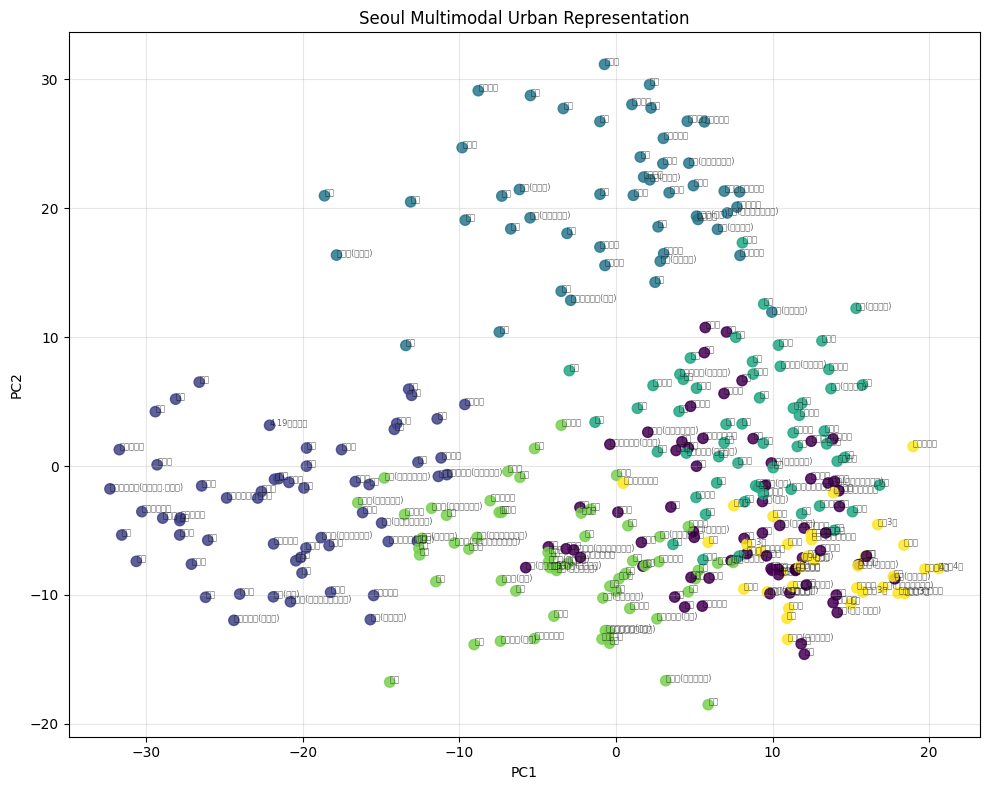

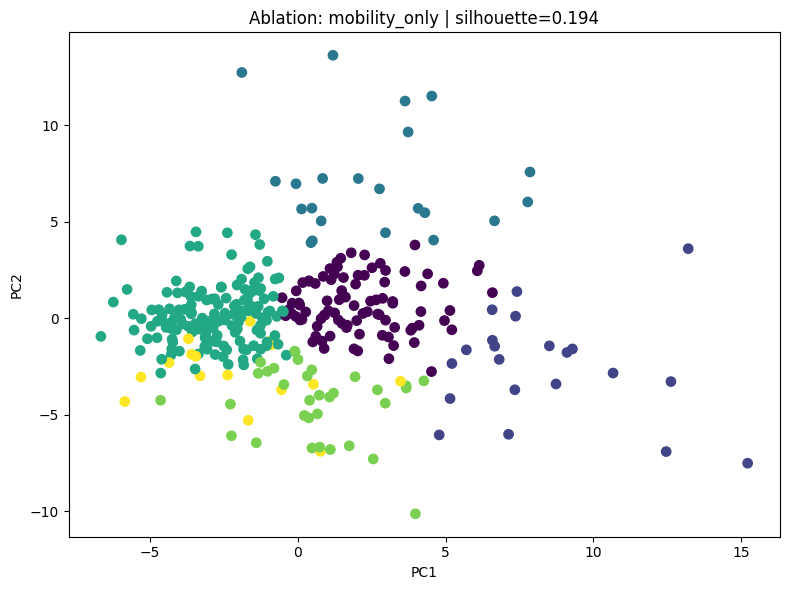

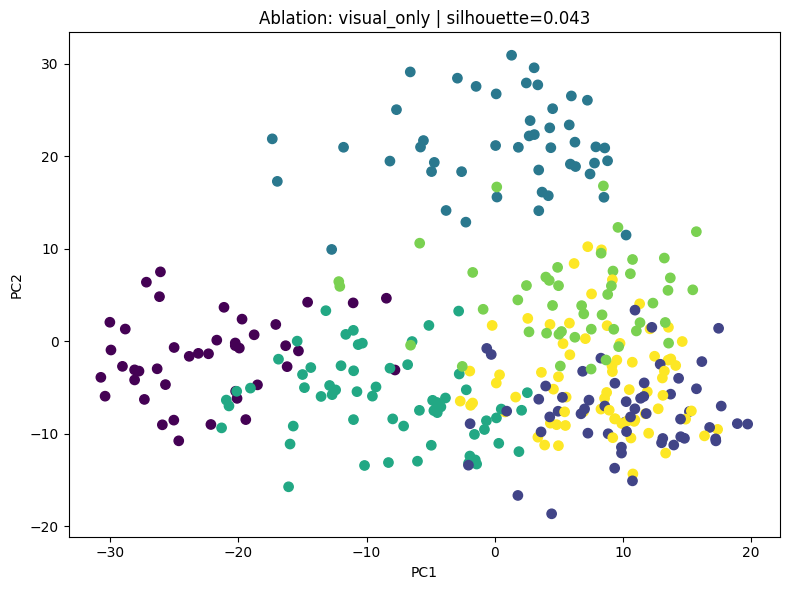

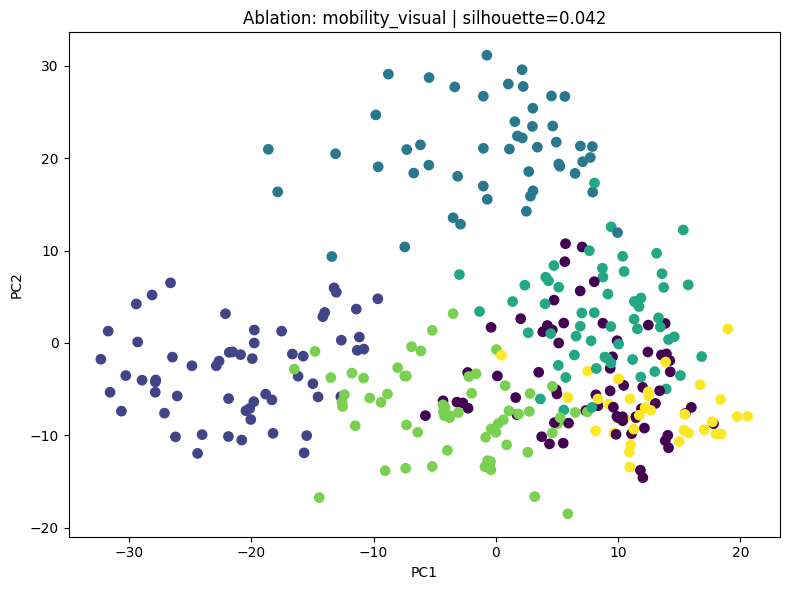


Ablation summary:
           setting  n_features  silhouette
0    mobility_only          42    0.193575
1      visual_only        1536    0.042677
2  mobility_visual        1578    0.042316

Representative stations saved:
 cluster  station_id     station_name hidden_type  surrounding_total_flow  subway_total_activity subway_capture_rate
       0        2519              까치산        None            368935521.44              261857667                None
       0         221               역삼        None            321518950.32              423543667                None
       0         232          구로디지털단지        None            290029165.87              527334634                None
       0         211               성수        None            271949529.45              328911927                None
       0         202            을지로입구        None            251067436.83              417701659                None
       0         413               쌍문        None            239649333.77  

In [5]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score


# ============================================================
# PATH
# ============================================================

RESULT_DIR = "seoul_station_multimodal/results"
RESULT_CSV = f"{RESULT_DIR}/multimodal_cluster_result.csv"

os.makedirs(RESULT_DIR, exist_ok=True)

df = pd.read_csv(RESULT_CSV)

print("Loaded:", df.shape)
print(df.head())


# ============================================================
# 1. BASIC CHECK
# ============================================================

print("\nColumns:", len(df.columns))
print("Rows:", len(df))

if "visual_emb_0" in df.columns:
    print("Rows with visual embedding:", df["visual_emb_0"].notna().sum())

print("\nCluster counts:")
print(df["cluster"].value_counts().sort_index())


# ============================================================
# 2. CLUSTER MEMBERS
# ============================================================

name_col = "station_name_mobility" if "station_name_mobility" in df.columns else "station_name"

for c in sorted(df["cluster"].unique()):
    print("\n" + "=" * 80)
    print(f"CLUSTER {c}")
    print("=" * 80)

    show_cols = [
        x for x in [
            "station_id",
            name_col,
            "nearest_line",
            "hidden_type",
            "surrounding_total_flow",
            "subway_total_activity",
            "subway_capture_rate",
            "cluster"
        ]
        if x in df.columns
    ]

    tmp = (
        df[df["cluster"] == c][show_cols]
        .sort_values(
            "surrounding_total_flow",
            ascending=False
            if "surrounding_total_flow" in df.columns else True
        )
    )

    print(tmp.head(40).to_string(index=False))


# ============================================================
# 3. HIDDEN TYPE DISTRIBUTION
# ============================================================

if "hidden_type" in df.columns:
    hidden_table = pd.crosstab(
        df["cluster"],
        df["hidden_type"],
        margins=True
    )

    print("\nHidden type distribution:")
    print(hidden_table)

    hidden_table.to_csv(f"{RESULT_DIR}/cluster_hidden_type_distribution.csv")


# ============================================================
# 4. CLUSTER PROFILE
# ============================================================

profile_candidates = [
    "mapped_cell_count",
    "active_cell_count",
    "surrounding_total_flow",
    "surrounding_outflow",
    "surrounding_inflow",
    "surrounding_netflow",
    "mean_cell_flow",
    "subway_total_activity",
    "subway_capture_rate",
    "subway_flow_ratio",
    "mobility_minus_subway_gap",
    "temporal_entropy",
    "distance_entropy",
    "outer_1km_plus_share",
]

profile_cols = [c for c in profile_candidates if c in df.columns]

if len(profile_cols) > 0:
    cluster_profile = (
        df.groupby("cluster")[profile_cols]
        .mean()
        .round(3)
    )

    print("\nCluster profile:")
    print(cluster_profile.T)

    cluster_profile.to_csv(f"{RESULT_DIR}/cluster_profile.csv")


# ============================================================
# 5. PCA VISUALIZATION
# ============================================================

plt.figure(figsize=(10, 8))

plt.scatter(
    df["pca_x"],
    df["pca_y"],
    c=df["cluster"],
    s=55,
    alpha=0.85
)

plt.title("Seoul Multimodal Urban Representation")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.grid(True, alpha=0.3)

for _, row in df.iterrows():
    plt.text(
        row["pca_x"],
        row["pca_y"],
        str(row[name_col]),
        fontsize=6,
        alpha=0.6
    )

plt.tight_layout()
plt.savefig(f"{RESULT_DIR}/pca_with_station_names.png", dpi=220)
plt.show()


# ============================================================
# 6. HIDDEN ONLY VISUALIZATION
# ============================================================

if "hidden_type" in df.columns:
    hidden_mask = (
        df["hidden_type"]
        .astype(str)
        .str.contains("hidden", case=False, na=False)
    )

    plt.figure(figsize=(10, 8))

    plt.scatter(
        df["pca_x"],
        df["pca_y"],
        c="lightgray",
        s=45,
        alpha=0.45,
        label="others"
    )

    plt.scatter(
        df.loc[hidden_mask, "pca_x"],
        df.loc[hidden_mask, "pca_y"],
        c="red",
        s=70,
        alpha=0.9,
        label="hidden demand"
    )

    for _, row in df.loc[hidden_mask].iterrows():
        plt.text(
            row["pca_x"],
            row["pca_y"],
            str(row[name_col]),
            fontsize=7
        )

    plt.title("Hidden Demand Stations in Multimodal Latent Space")
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(f"{RESULT_DIR}/hidden_demand_pca.png", dpi=220)
    plt.show()

    hidden_df = df.loc[hidden_mask].copy()
    hidden_df.to_csv(f"{RESULT_DIR}/hidden_demand_stations.csv", index=False)

    print("\nHidden demand stations saved.")


# ============================================================
# 7. ABLATION COMPARISON
# ============================================================

def get_feature_sets(df):
    visual_cols = [c for c in df.columns if c.startswith("visual_emb_")]

    exclude = {
        "station_id",
        "station_name",
        "station_name_mobility",
        "station_name_visual",
        "nearest_station",
        "nearest_line",
        "hidden_type",
        "map_path",
        "satellite_path",
        "caption",
        "cluster",
        "pca_x",
        "pca_y",
    }

    numeric_cols = [
        c for c in df.columns
        if pd.api.types.is_numeric_dtype(df[c])
        and c not in exclude
    ]

    mobility_cols = [
        c for c in numeric_cols
        if not c.startswith("visual_emb_")
    ]

    return mobility_cols, visual_cols


def run_ablation(df, feature_cols, name, n_clusters=6):
    X = df[feature_cols].fillna(0).values
    X = StandardScaler().fit_transform(X)

    km = KMeans(
        n_clusters=n_clusters,
        random_state=42,
        n_init=10
    )

    labels = km.fit_predict(X)

    sil = silhouette_score(X, labels)

    pca = PCA(n_components=2, random_state=42)
    xy = pca.fit_transform(X)

    out = df[["station_id", name_col]].copy()
    out[f"{name}_cluster"] = labels
    out[f"{name}_pca_x"] = xy[:, 0]
    out[f"{name}_pca_y"] = xy[:, 1]

    out.to_csv(f"{RESULT_DIR}/ablation_{name}.csv", index=False)

    plt.figure(figsize=(8, 6))
    plt.scatter(xy[:, 0], xy[:, 1], c=labels, s=45)
    plt.title(f"Ablation: {name} | silhouette={sil:.3f}")
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.tight_layout()
    plt.savefig(f"{RESULT_DIR}/ablation_{name}.png", dpi=220)
    plt.show()

    return {
        "setting": name,
        "n_features": len(feature_cols),
        "silhouette": sil
    }


mobility_cols, visual_cols = get_feature_sets(df)

ablation_results = []

if len(mobility_cols) > 0:
    ablation_results.append(
        run_ablation(df, mobility_cols, "mobility_only", N_CLUSTERS if "N_CLUSTERS" in globals() else 6)
    )

if len(visual_cols) > 0:
    ablation_results.append(
        run_ablation(df, visual_cols, "visual_only", N_CLUSTERS if "N_CLUSTERS" in globals() else 6)
    )

if len(mobility_cols) > 0 and len(visual_cols) > 0:
    ablation_results.append(
        run_ablation(df, mobility_cols + visual_cols, "mobility_visual", N_CLUSTERS if "N_CLUSTERS" in globals() else 6)
    )

ablation_df = pd.DataFrame(ablation_results)
ablation_df.to_csv(f"{RESULT_DIR}/ablation_summary.csv", index=False)

print("\nAblation summary:")
print(ablation_df)


# ============================================================
# 8. TOP REPRESENTATIVE STATIONS PER CLUSTER
# ============================================================

rep_rows = []

for c in sorted(df["cluster"].unique()):
    tmp = df[df["cluster"] == c].copy()

    if "surrounding_total_flow" in tmp.columns:
        tmp = tmp.sort_values("surrounding_total_flow", ascending=False)

    for _, row in tmp.head(10).iterrows():
        rep_rows.append({
            "cluster": c,
            "station_id": row["station_id"],
            "station_name": row[name_col],
            "hidden_type": row["hidden_type"] if "hidden_type" in df.columns else None,
            "surrounding_total_flow": row["surrounding_total_flow"] if "surrounding_total_flow" in df.columns else None,
            "subway_total_activity": row["subway_total_activity"] if "subway_total_activity" in df.columns else None,
            "subway_capture_rate": row["subway_capture_rate"] if "subway_capture_rate" in df.columns else None,
        })

rep_df = pd.DataFrame(rep_rows)
rep_df.to_csv(f"{RESULT_DIR}/cluster_representative_stations.csv", index=False)

print("\nRepresentative stations saved:")
print(rep_df.head(30).to_string(index=False))


# ============================================================
# 9. SAVE FINAL INTERPRETATION TABLE
# ============================================================

summary_rows = []

for c in sorted(df["cluster"].unique()):
    tmp = df[df["cluster"] == c]

    row = {
        "cluster": c,
        "n_stations": len(tmp),
    }

    if "hidden_type" in df.columns:
        top_hidden = tmp["hidden_type"].astype(str).value_counts().head(3)
        row["top_hidden_types"] = "; ".join([f"{k}:{v}" for k, v in top_hidden.items()])

    for col in profile_cols:
        row[f"mean_{col}"] = tmp[col].mean()

    summary_rows.append(row)

summary_df = pd.DataFrame(summary_rows)
summary_df.to_csv(f"{RESULT_DIR}/cluster_interpretation_summary.csv", index=False)

print("\nFinal summary saved:")
print(summary_df)

Mobility dims: 42
Visual dims: 1536


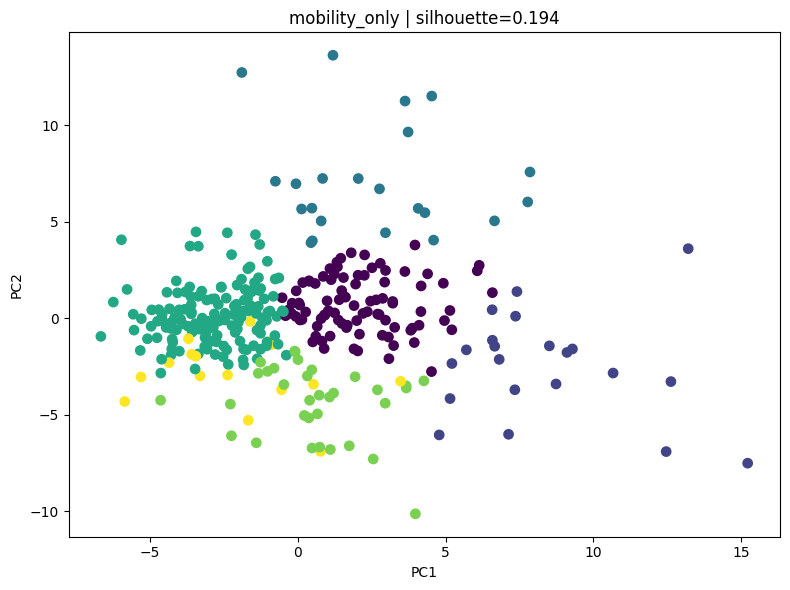

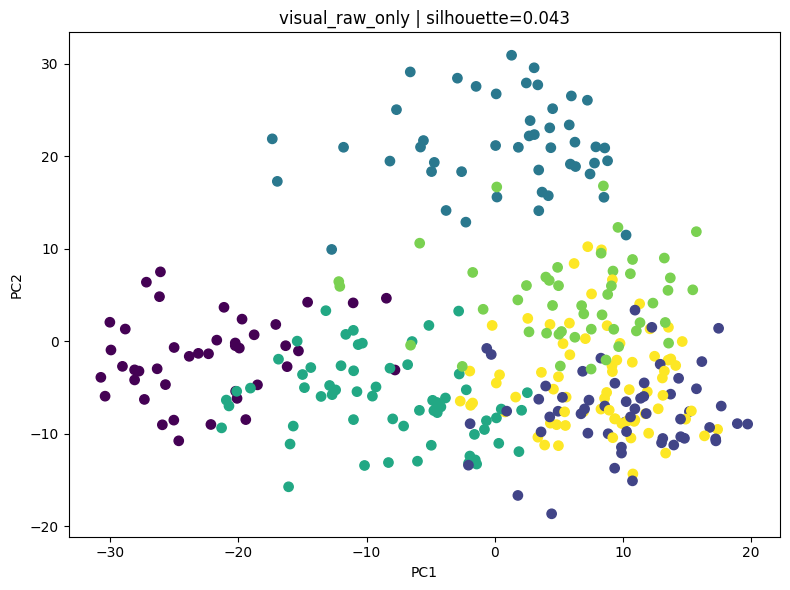

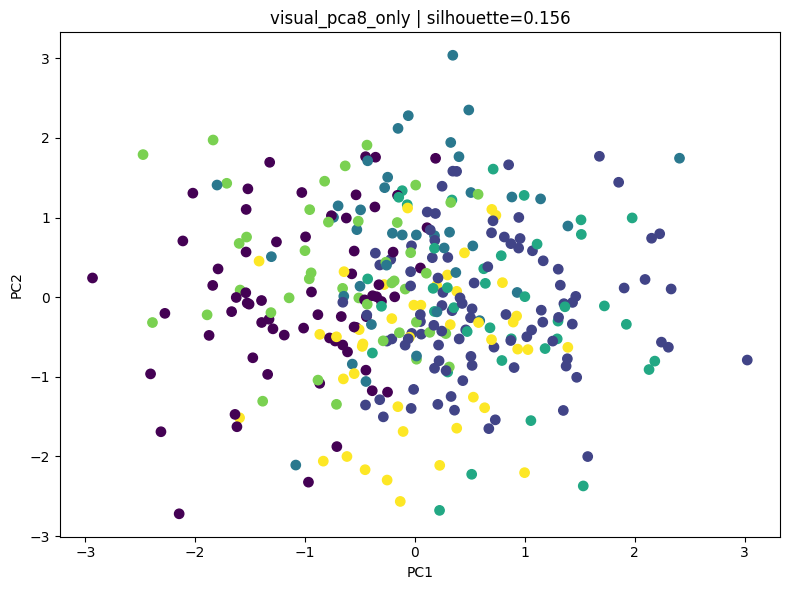

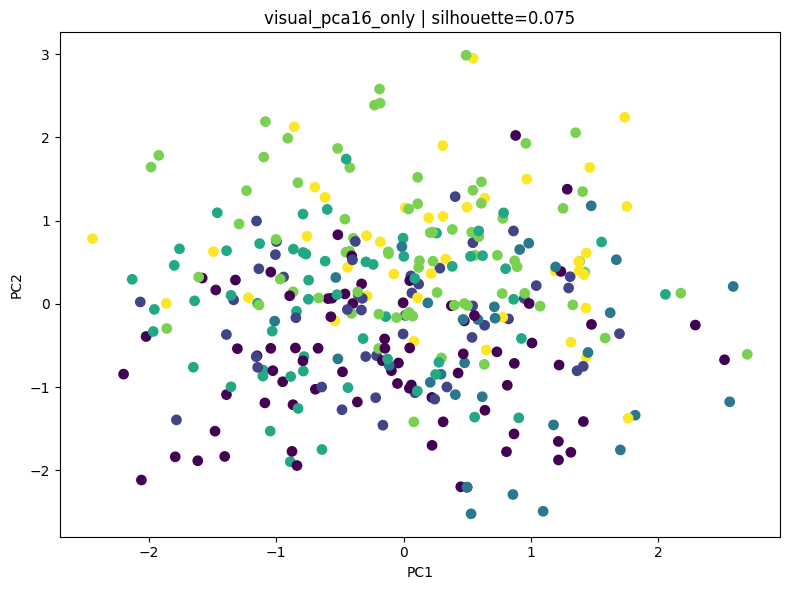

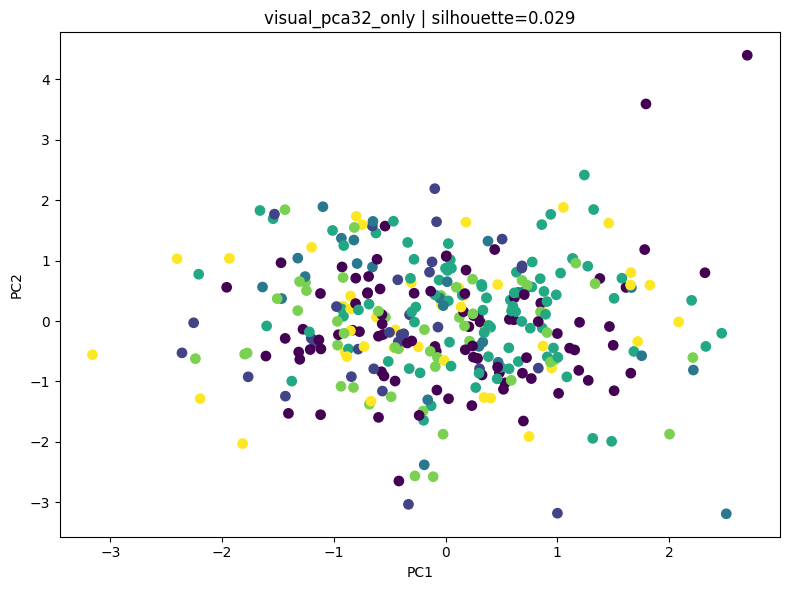

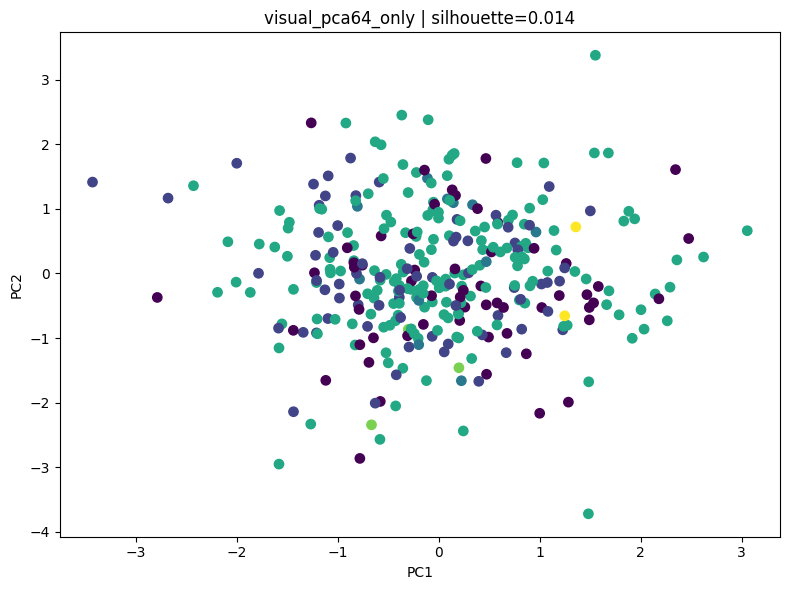

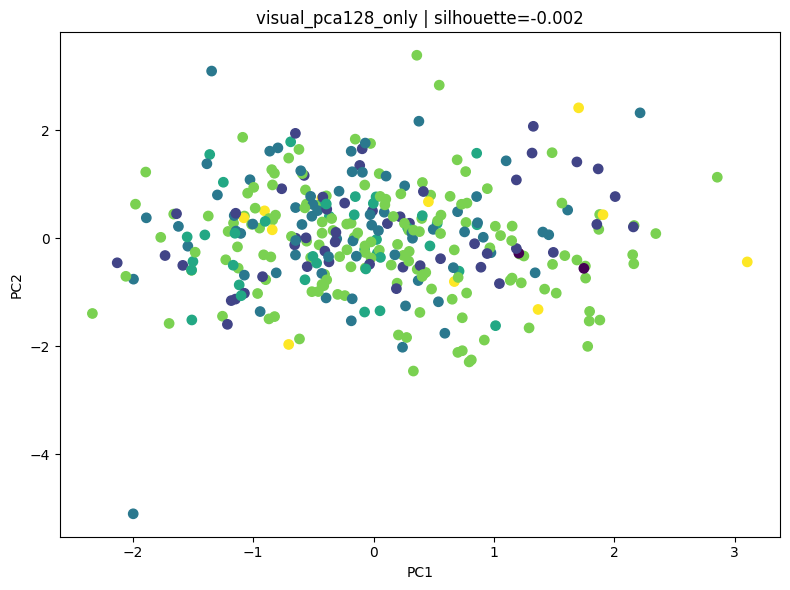

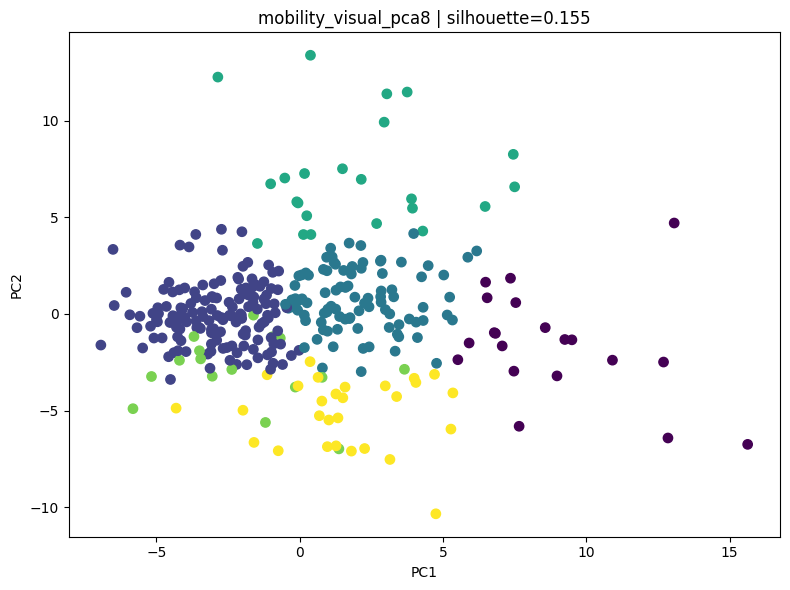

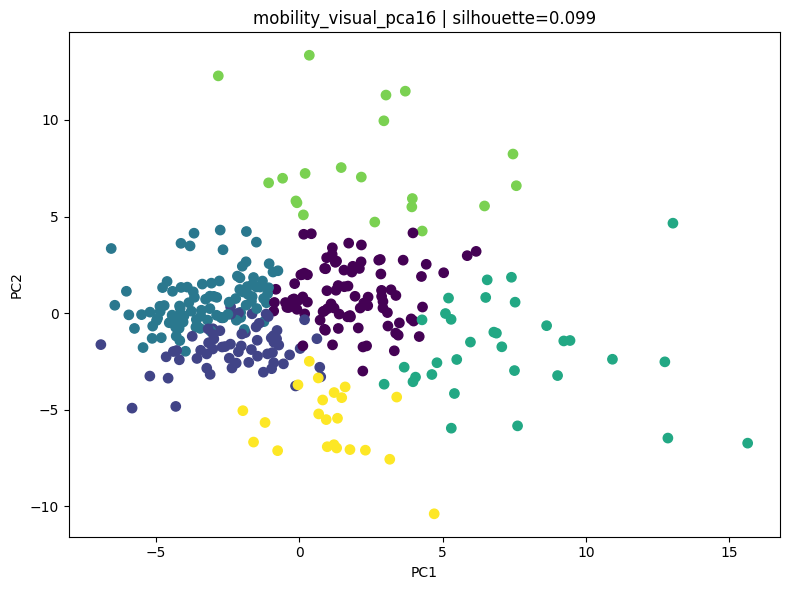

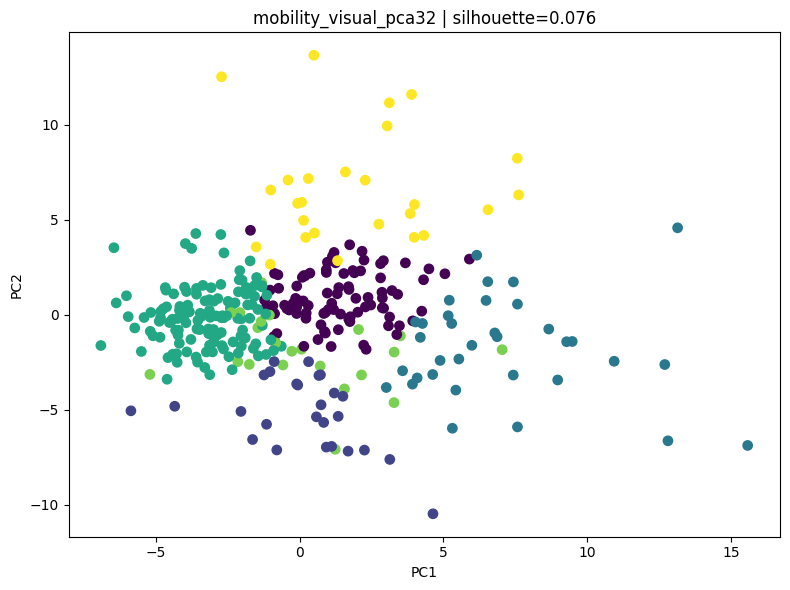

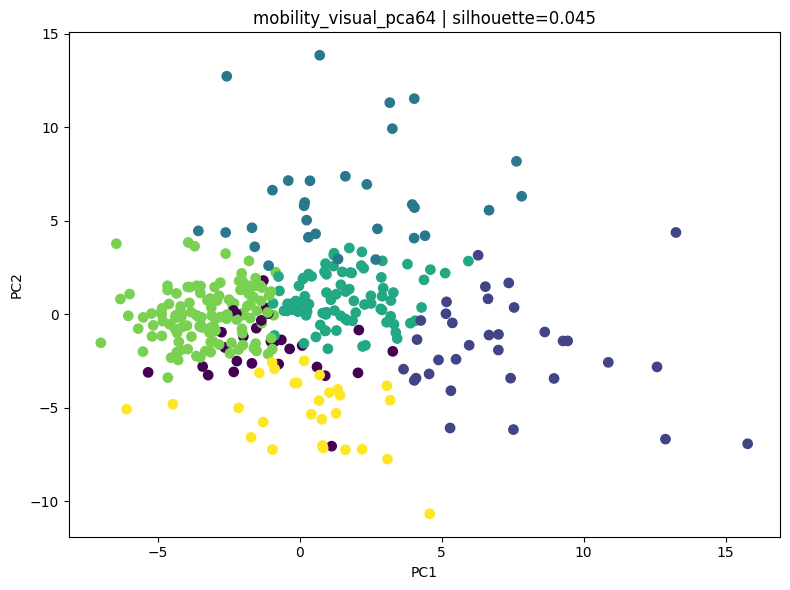

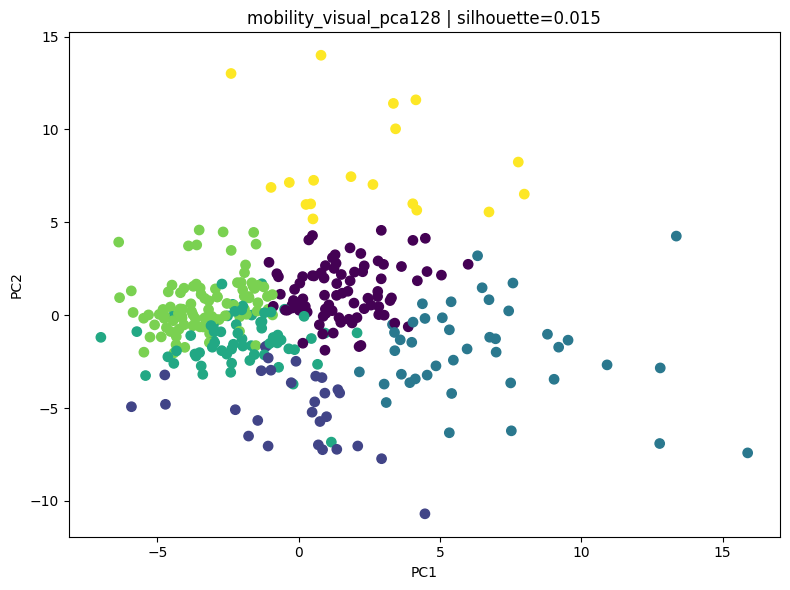

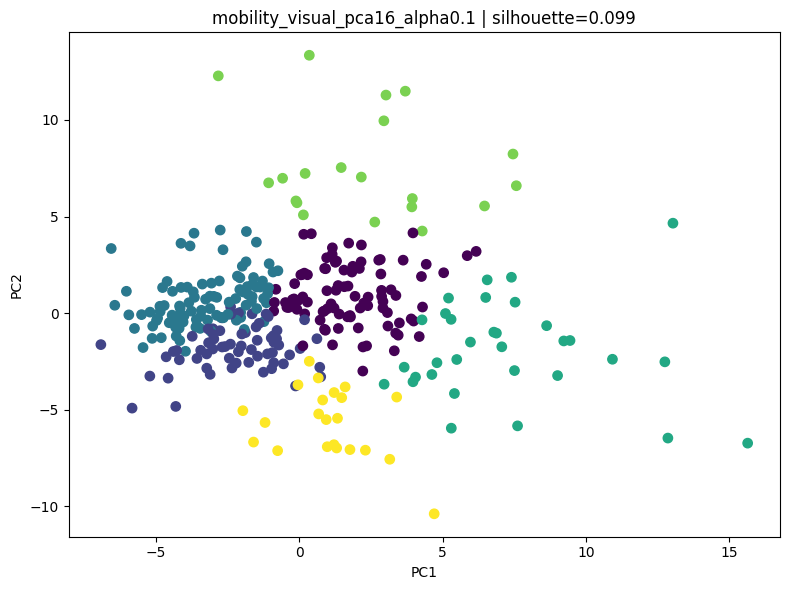

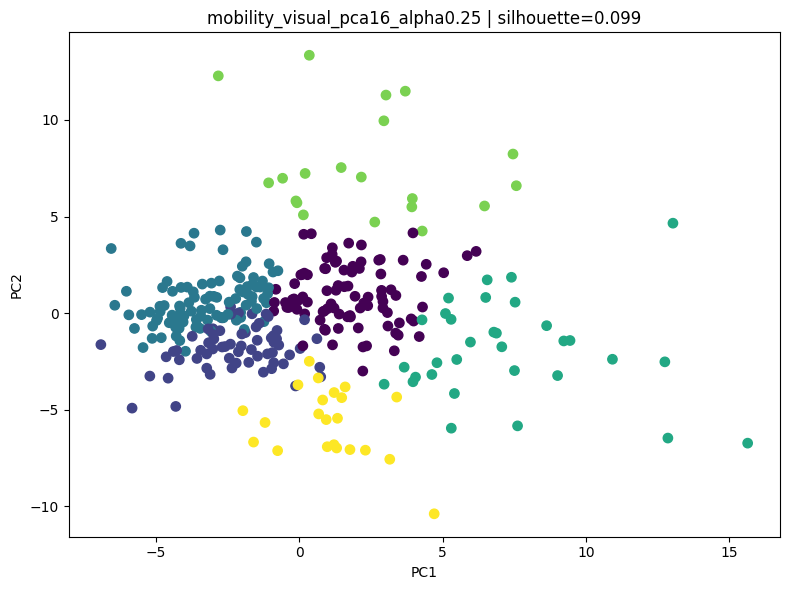

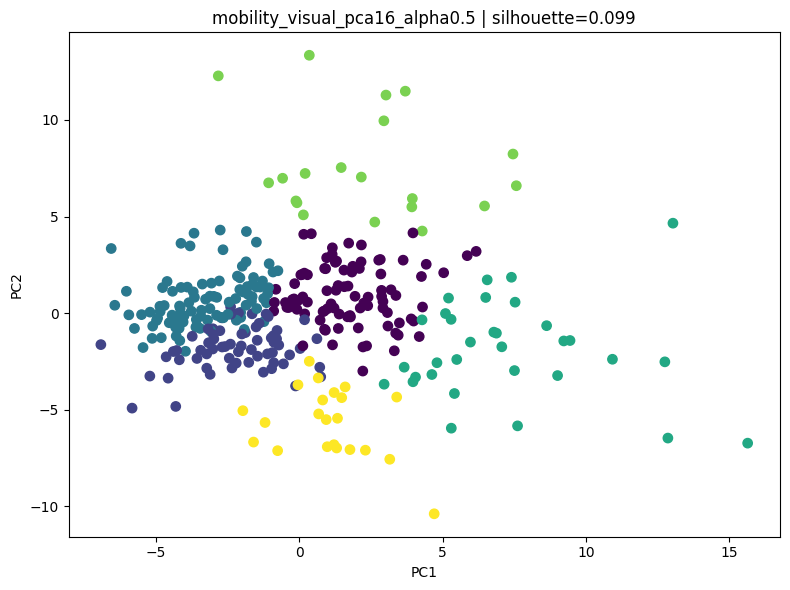

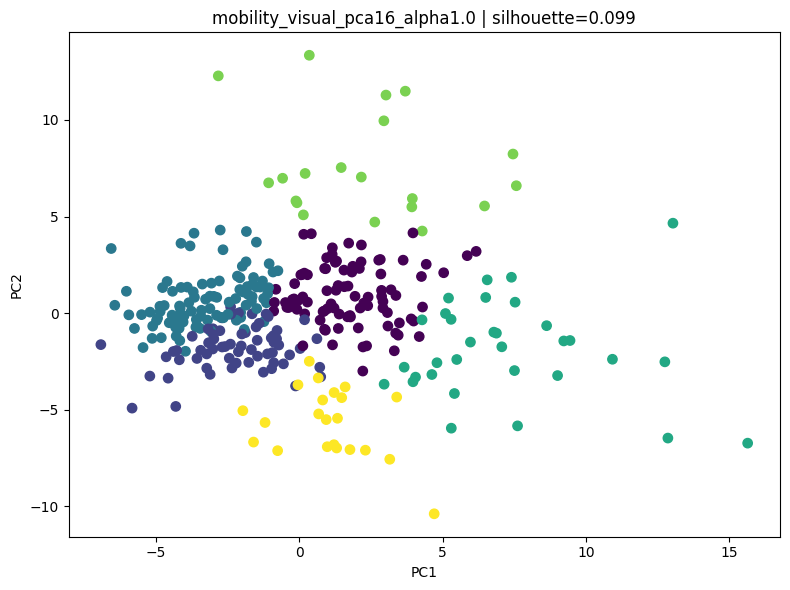

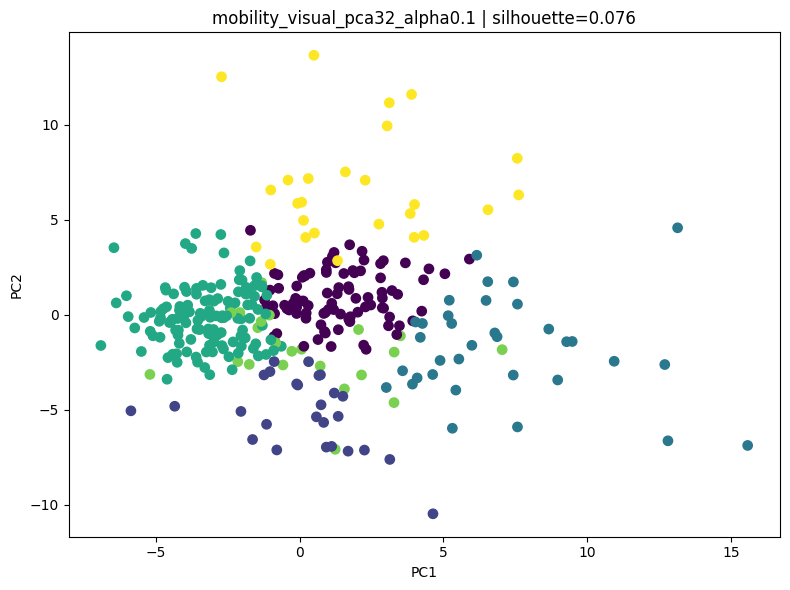

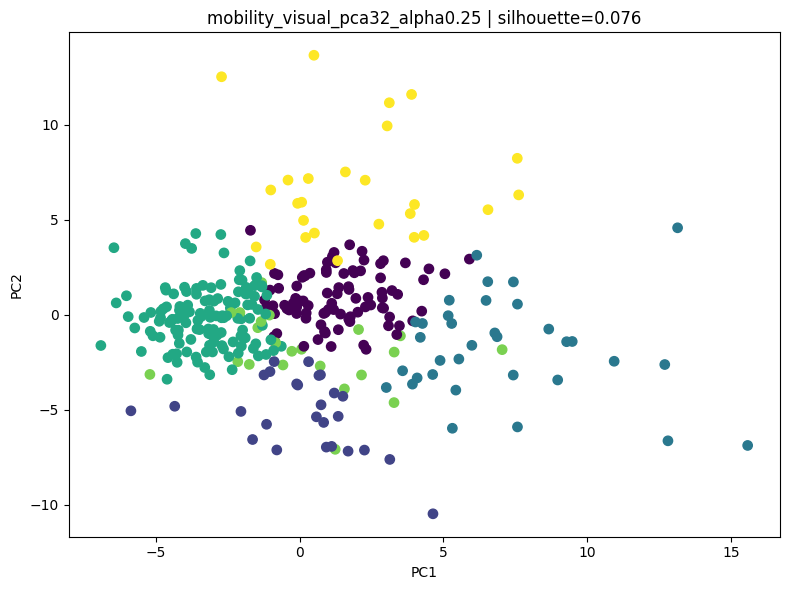

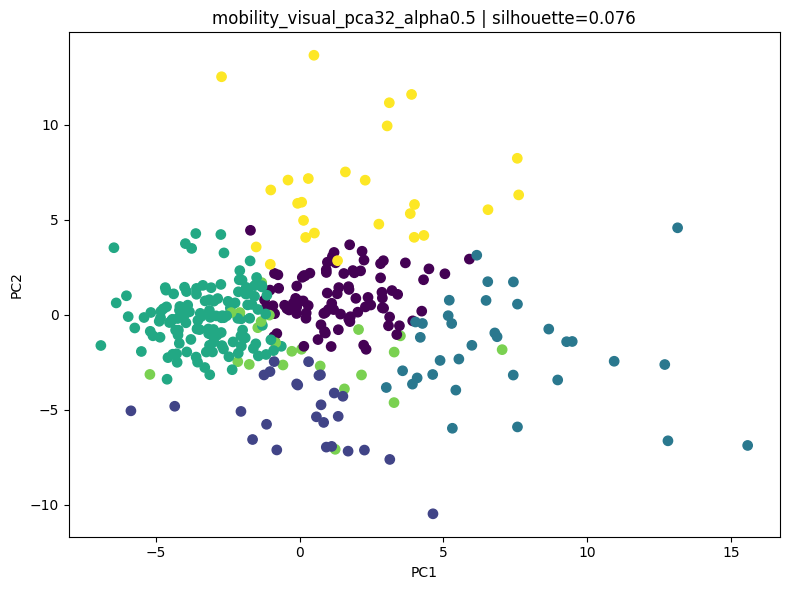

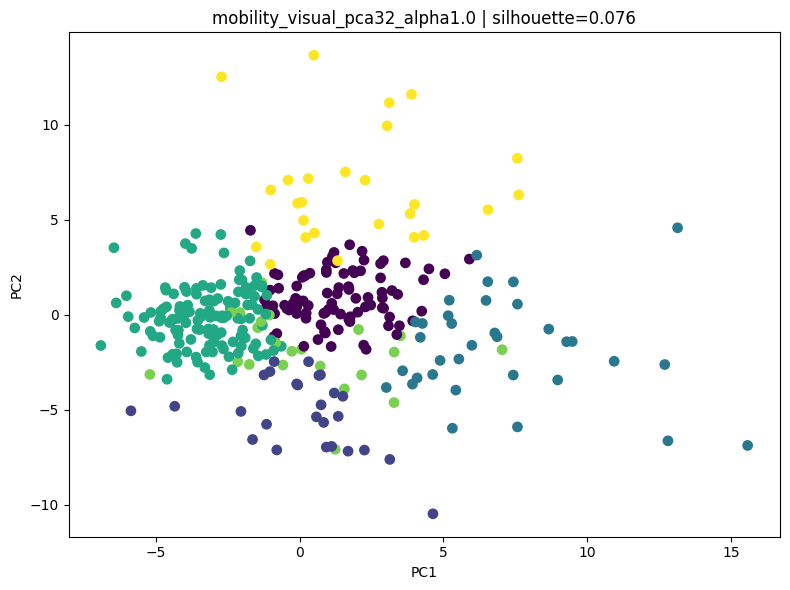

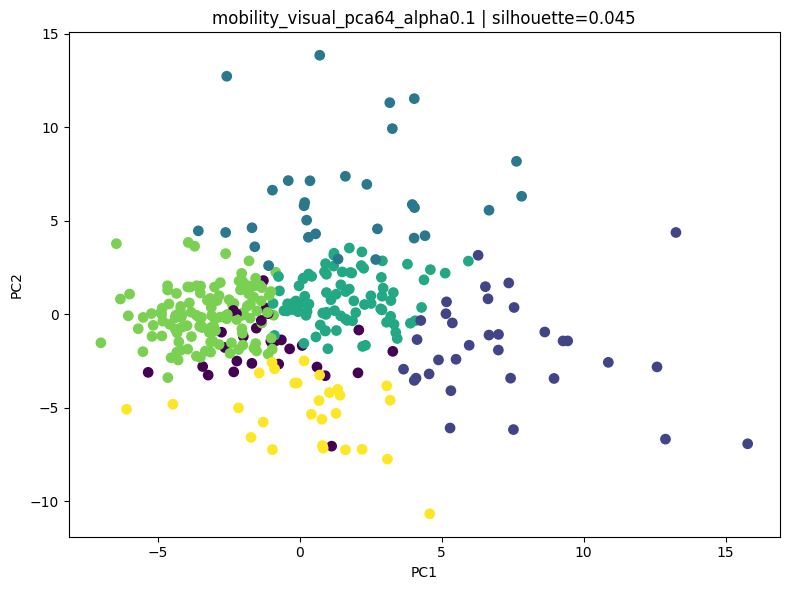

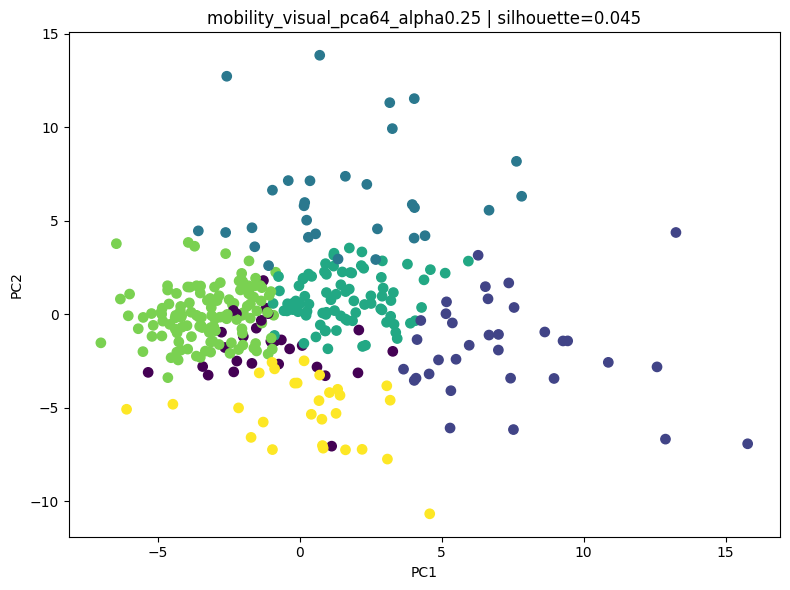

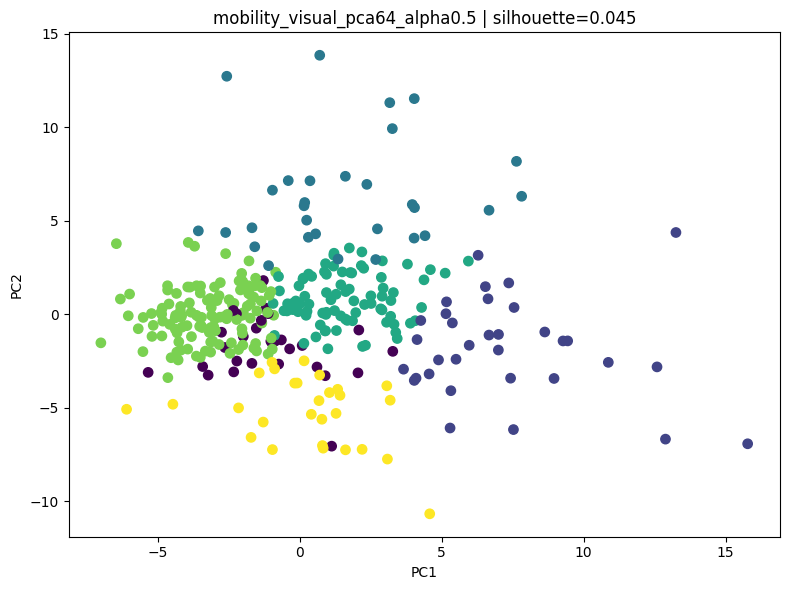

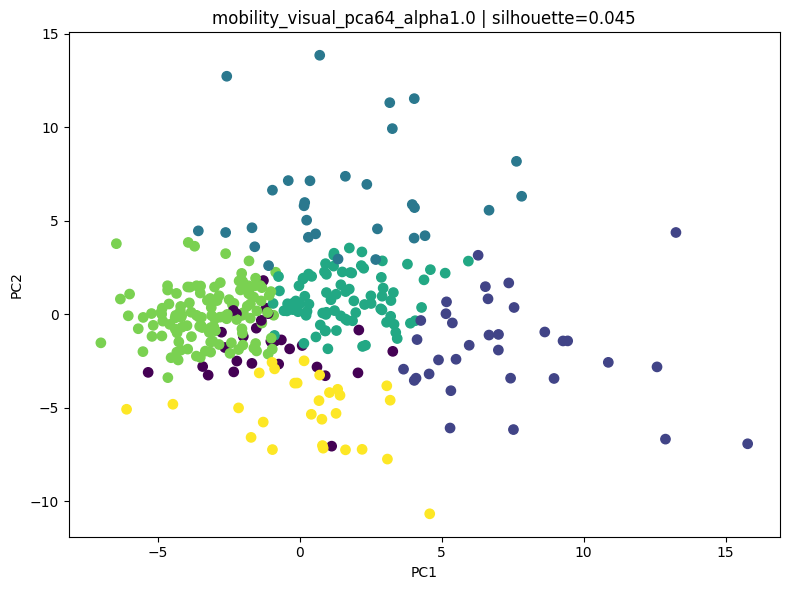


Fusion ablation summary:
                        setting  n_features  silhouette
                  mobility_only          42    0.193575
               visual_pca8_only           8    0.155536
           mobility_visual_pca8          50    0.155099
          mobility_visual_pca16          58    0.098622
mobility_visual_pca16_alpha0.25          58    0.098622
 mobility_visual_pca16_alpha0.5          58    0.098622
 mobility_visual_pca16_alpha1.0          58    0.098622
 mobility_visual_pca16_alpha0.1          58    0.098622
 mobility_visual_pca32_alpha0.1          74    0.076374
          mobility_visual_pca32          74    0.076374
 mobility_visual_pca32_alpha0.5          74    0.076374
mobility_visual_pca32_alpha0.25          74    0.076374
 mobility_visual_pca32_alpha1.0          74    0.076374
              visual_pca16_only          16    0.074957
 mobility_visual_pca64_alpha0.1         106    0.044637
          mobility_visual_pca64         106    0.044637
 mobility_visual_pca64

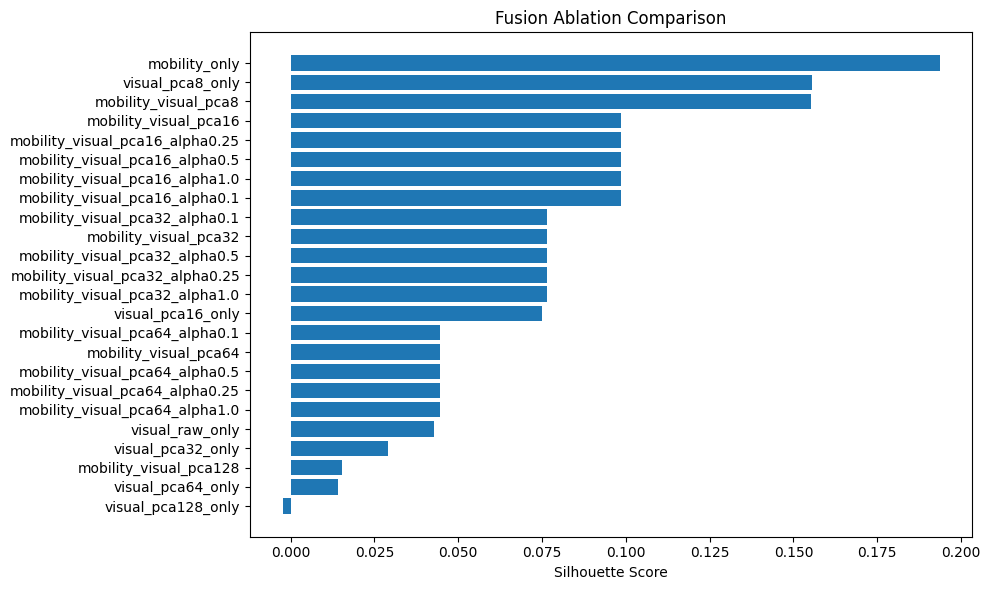

In [6]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score


RESULT_DIR = "seoul_station_multimodal/results"
CSV = f"{RESULT_DIR}/multimodal_cluster_result.csv"

df = pd.read_csv(CSV)

N_CLUSTERS = 6
RANDOM_STATE = 42

visual_cols = [c for c in df.columns if c.startswith("visual_emb_")]

exclude = {
    "station_id",
    "station_name",
    "station_name_mobility",
    "station_name_visual",
    "nearest_station",
    "nearest_line",
    "hidden_type",
    "map_path",
    "satellite_path",
    "caption",
    "cluster",
    "pca_x",
    "pca_y",
}

numeric_cols = [
    c for c in df.columns
    if pd.api.types.is_numeric_dtype(df[c])
    and c not in exclude
]

mobility_cols = [
    c for c in numeric_cols
    if not c.startswith("visual_emb_")
]

print("Mobility dims:", len(mobility_cols))
print("Visual dims:", len(visual_cols))


def cluster_eval(X, name):
    X = np.nan_to_num(X)
    X = StandardScaler().fit_transform(X)

    km = KMeans(
        n_clusters=N_CLUSTERS,
        random_state=RANDOM_STATE,
        n_init=10,
    )

    labels = km.fit_predict(X)
    sil = silhouette_score(X, labels)

    pca2 = PCA(n_components=2, random_state=RANDOM_STATE)
    xy = pca2.fit_transform(X)

    out = df[["station_id", "nearest_station"]].copy()
    out["cluster"] = labels
    out["pca_x"] = xy[:, 0]
    out["pca_y"] = xy[:, 1]

    if "hidden_type" in df.columns:
        out["hidden_type"] = df["hidden_type"]

    out.to_csv(f"{RESULT_DIR}/experiment_{name}.csv", index=False)

    plt.figure(figsize=(8, 6))
    plt.scatter(xy[:, 0], xy[:, 1], c=labels, s=45)
    plt.title(f"{name} | silhouette={sil:.3f}")
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.tight_layout()
    plt.savefig(f"{RESULT_DIR}/experiment_{name}.png", dpi=220)
    plt.show()

    return {
        "setting": name,
        "n_features": X.shape[1],
        "silhouette": sil,
    }


results = []

# 1. mobility only
X_mob = df[mobility_cols].fillna(0).values
results.append(
    cluster_eval(X_mob, "mobility_only")
)

# 2. visual raw only
X_vis = df[visual_cols].fillna(0).values
results.append(
    cluster_eval(X_vis, "visual_raw_only")
)

# 3. visual PCA only
for dim in [8, 16, 32, 64, 128]:
    pca = PCA(n_components=dim, random_state=RANDOM_STATE)
    X_vis_pca = pca.fit_transform(StandardScaler().fit_transform(X_vis))

    results.append(
        cluster_eval(X_vis_pca, f"visual_pca{dim}_only")
    )

# 4. mobility + visual PCA
X_mob_scaled = StandardScaler().fit_transform(X_mob)

for dim in [8, 16, 32, 64, 128]:
    pca = PCA(n_components=dim, random_state=RANDOM_STATE)
    X_vis_pca = pca.fit_transform(StandardScaler().fit_transform(X_vis))

    X_fused = np.concatenate(
        [
            X_mob_scaled,
            X_vis_pca,
        ],
        axis=1,
    )

    results.append(
        cluster_eval(X_fused, f"mobility_visual_pca{dim}")
    )

# 5. weighted fusion
for dim in [16, 32, 64]:
    pca = PCA(n_components=dim, random_state=RANDOM_STATE)
    X_vis_pca = pca.fit_transform(StandardScaler().fit_transform(X_vis))

    X_vis_pca = StandardScaler().fit_transform(X_vis_pca)

    for alpha in [0.1, 0.25, 0.5, 1.0]:
        # alpha 낮을수록 visual 영향 작음
        X_fused = np.concatenate(
            [
                X_mob_scaled,
                alpha * X_vis_pca,
            ],
            axis=1,
        )

        results.append(
            cluster_eval(
                X_fused,
                f"mobility_visual_pca{dim}_alpha{alpha}"
            )
        )

summary = pd.DataFrame(results)
summary = summary.sort_values("silhouette", ascending=False)

summary.to_csv(
    f"{RESULT_DIR}/fusion_ablation_summary.csv",
    index=False
)

print("\nFusion ablation summary:")
print(summary.to_string(index=False))

plt.figure(figsize=(10, 6))
plt.barh(
    summary["setting"],
    summary["silhouette"]
)
plt.xlabel("Silhouette Score")
plt.title("Fusion Ablation Comparison")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig(
    f"{RESULT_DIR}/fusion_ablation_summary.png",
    dpi=220
)
plt.show()

Rows: 327
Mobility dims: 42
Visual dims: 1536

=== Fusion Experiment Summary ===
                        setting  n_features  silhouette
        visual_pca2_only_ev0.17           2    0.418364
        visual_pca4_only_ev0.24           4    0.255858
                  mobility_only          42    0.193575
           mobility_visual_pca2          44    0.186092
  mobility_visual_pca2_alpha0.1          44    0.186092
 mobility_visual_pca2_alpha0.05          44    0.186092
 mobility_visual_pca2_alpha0.03          44    0.186092
 mobility_visual_pca2_alpha0.01          44    0.186092
  mobility_visual_pca2_alpha2.0          44    0.186092
  mobility_visual_pca2_alpha1.0          44    0.186092
  mobility_visual_pca2_alpha0.5          44    0.186092
 mobility_visual_pca2_alpha0.25          44    0.186092
 mobility_visual_pca4_alpha0.03          46    0.166208
 mobility_visual_pca4_alpha0.01          46    0.166208
           mobility_visual_pca4          46    0.166208
 mobility_visual_pca4_a

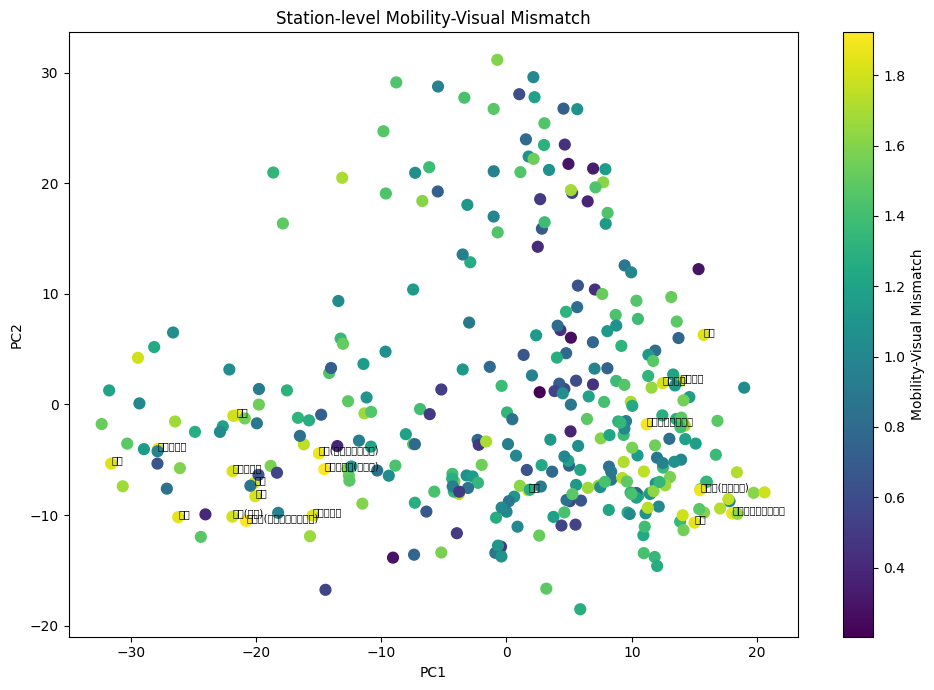


=== FINAL REPORT ===
best_silhouette_setting : visual_pca2_only_ev0.17
best_silhouette : 0.41836401369481674
mobility_only_silhouette : 0.19357483008121754
visual_raw_only_silhouette : 0.04267664625816343
mean_neighbor_overlap_pca8 : 0.08409785932721713
mean_modality_agreement_pca8 : -0.20153782724234207
mean_modality_mismatch_pca8 : 1.201537827242342

Saved all experiment outputs to: seoul_station_multimodal/results


In [8]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler, normalize
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, adjusted_rand_score, normalized_mutual_info_score
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.neighbors import NearestNeighbors
from scipy.stats import spearmanr, pearsonr


# ============================================================
# PATH
# ============================================================

RESULT_DIR = "seoul_station_multimodal/results"
CSV = f"{RESULT_DIR}/multimodal_cluster_result.csv"

os.makedirs(RESULT_DIR, exist_ok=True)

df = pd.read_csv(CSV)

N_CLUSTERS = 6
RANDOM_STATE = 42

name_col = "nearest_station" if "nearest_station" in df.columns else "station_name"

visual_cols = [c for c in df.columns if c.startswith("visual_emb_")]

exclude = {
    "station_id", "station_name", "station_name_mobility",
    "station_name_visual", "nearest_station", "nearest_line",
    "hidden_type", "map_path", "satellite_path", "caption",
    "cluster", "pca_x", "pca_y"
}

numeric_cols = [
    c for c in df.columns
    if pd.api.types.is_numeric_dtype(df[c])
    and c not in exclude
]

mobility_cols = [c for c in numeric_cols if not c.startswith("visual_emb_")]

print("Rows:", len(df))
print("Mobility dims:", len(mobility_cols))
print("Visual dims:", len(visual_cols))


# ============================================================
# HELPERS
# ============================================================

def scale(X):
    return StandardScaler().fit_transform(np.nan_to_num(X))


def cluster_eval(X, setting):
    Xs = scale(X)

    km = KMeans(
        n_clusters=N_CLUSTERS,
        random_state=RANDOM_STATE,
        n_init=10
    )
    labels = km.fit_predict(Xs)

    sil = silhouette_score(Xs, labels)

    pca2 = PCA(n_components=2, random_state=RANDOM_STATE)
    xy = pca2.fit_transform(Xs)

    out = pd.DataFrame({
        "station_id": df["station_id"],
        "station_name": df[name_col],
        "cluster": labels,
        "pca_x": xy[:, 0],
        "pca_y": xy[:, 1],
    })

    if "hidden_type" in df.columns:
        out["hidden_type"] = df["hidden_type"]

    out.to_csv(f"{RESULT_DIR}/exp_{setting}.csv", index=False)

    plt.figure(figsize=(7, 6))
    plt.scatter(xy[:, 0], xy[:, 1], c=labels, s=40)
    plt.title(f"{setting} | silhouette={sil:.3f}")
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.tight_layout()
    plt.savefig(f"{RESULT_DIR}/exp_{setting}.png", dpi=220)
    plt.close()

    return labels, sil


def pca_reduce(X, dim):
    Xs = scale(X)
    pca = PCA(n_components=dim, random_state=RANDOM_STATE)
    return pca.fit_transform(Xs), pca.explained_variance_ratio_.sum()


def save_bar(df_summary, x, y, filename, title):
    plt.figure(figsize=(10, 6))
    plt.barh(df_summary[x], df_summary[y])
    plt.gca().invert_yaxis()
    plt.xlabel(y)
    plt.title(title)
    plt.tight_layout()
    plt.savefig(f"{RESULT_DIR}/{filename}", dpi=220)
    plt.close()


# ============================================================
# BASE MATRICES
# ============================================================

X_mob = df[mobility_cols].fillna(0).values
X_vis = df[visual_cols].fillna(0).values

X_mob_s = scale(X_mob)
X_vis_s = scale(X_vis)

results = []
labels_store = {}


# ============================================================
# 1. BASIC CLUSTERING CASES
# ============================================================

cases = {}

cases["mobility_only"] = X_mob
cases["visual_raw_only"] = X_vis

for dim in [2, 4, 8, 16, 32, 64, 128]:
    Xvp, ev = pca_reduce(X_vis, dim)
    cases[f"visual_pca{dim}_only_ev{ev:.2f}"] = Xvp

for dim in [2, 4, 8, 16, 32, 64, 128]:
    Xvp, ev = pca_reduce(X_vis, dim)
    cases[f"mobility_visual_pca{dim}"] = np.concatenate([X_mob_s, Xvp], axis=1)

for dim in [2, 4, 8, 16, 32, 64]:
    Xvp, ev = pca_reduce(X_vis, dim)
    Xvp = scale(Xvp)

    for alpha in [0.01, 0.03, 0.05, 0.1, 0.25, 0.5, 1.0, 2.0]:
        cases[f"mobility_visual_pca{dim}_alpha{alpha}"] = np.concatenate(
            [X_mob_s, alpha * Xvp],
            axis=1
        )

for setting, X in cases.items():
    labels, sil = cluster_eval(X, setting)
    labels_store[setting] = labels
    results.append({
        "setting": setting,
        "n_features": X.shape[1],
        "silhouette": sil
    })

summary = pd.DataFrame(results).sort_values("silhouette", ascending=False)
summary.to_csv(f"{RESULT_DIR}/all_fusion_experiments_summary.csv", index=False)

print("\n=== Fusion Experiment Summary ===")
print(summary.to_string(index=False))

save_bar(
    summary.head(30),
    "setting",
    "silhouette",
    "all_fusion_experiments_top30.png",
    "Top Fusion Experiments"
)


# ============================================================
# 2. CLUSTER AGREEMENT BETWEEN MODALITIES
# ============================================================

agreement_rows = []

base_settings = list(labels_store.keys())

for a in base_settings:
    for b in base_settings:
        if a >= b:
            continue

        ari = adjusted_rand_score(labels_store[a], labels_store[b])
        nmi = normalized_mutual_info_score(labels_store[a], labels_store[b])

        agreement_rows.append({
            "setting_a": a,
            "setting_b": b,
            "ARI": ari,
            "NMI": nmi
        })

agreement_df = pd.DataFrame(agreement_rows).sort_values("ARI", ascending=False)
agreement_df.to_csv(f"{RESULT_DIR}/cluster_agreement_ari_nmi.csv", index=False)

print("\n=== Cluster Agreement Top ===")
print(agreement_df.head(30).to_string(index=False))


# ============================================================
# 3. MOBILITY-VISUAL LATENT SIMILARITY
# ============================================================

# 같은 차원으로 줄여서 station별 cosine similarity
for dim in [2, 4, 8, 16, 32]:
    Xm_pca, mob_ev = pca_reduce(X_mob, dim)
    Xv_pca, vis_ev = pca_reduce(X_vis, dim)

    Xm_n = normalize(Xm_pca)
    Xv_n = normalize(Xv_pca)

    same_station_sim = np.sum(Xm_n * Xv_n, axis=1)

    sim_df = pd.DataFrame({
        "station_id": df["station_id"],
        "station_name": df[name_col],
        f"mob_vis_cosine_pca{dim}": same_station_sim,
        "mobility_cluster": labels_store["mobility_only"],
        "visual_cluster": labels_store[[k for k in labels_store.keys() if k.startswith(f"visual_pca{dim}_only")][0]]
        if any(k.startswith(f"visual_pca{dim}_only") for k in labels_store.keys()) else None
    })

    if "hidden_type" in df.columns:
        sim_df["hidden_type"] = df["hidden_type"]

    sim_df = sim_df.sort_values(f"mob_vis_cosine_pca{dim}")

    sim_df.to_csv(f"{RESULT_DIR}/mobility_visual_similarity_pca{dim}.csv", index=False)

    print(f"\n=== Lowest mobility-visual agreement PCA{dim} ===")
    print(sim_df.head(20).to_string(index=False))

    print(f"\n=== Highest mobility-visual agreement PCA{dim} ===")
    print(sim_df.tail(20).to_string(index=False))


# ============================================================
# 4. NEAREST NEIGHBOR OVERLAP
# ============================================================

def neighbor_overlap(Xa, Xb, k=10):
    Xa = scale(Xa)
    Xb = scale(Xb)

    nn_a = NearestNeighbors(n_neighbors=k + 1).fit(Xa)
    nn_b = NearestNeighbors(n_neighbors=k + 1).fit(Xb)

    idx_a = nn_a.kneighbors(Xa, return_distance=False)[:, 1:]
    idx_b = nn_b.kneighbors(Xb, return_distance=False)[:, 1:]

    overlaps = []

    for i in range(len(df)):
        overlaps.append(
            len(set(idx_a[i]) & set(idx_b[i])) / k
        )

    return np.array(overlaps), idx_a, idx_b


neighbor_rows = []

for dim in [4, 8, 16, 32]:
    Xm_pca, _ = pca_reduce(X_mob, dim)
    Xv_pca, _ = pca_reduce(X_vis, dim)

    overlap, idx_m, idx_v = neighbor_overlap(Xm_pca, Xv_pca, k=10)

    tmp = pd.DataFrame({
        "station_id": df["station_id"],
        "station_name": df[name_col],
        f"nn_overlap_pca{dim}": overlap,
    })

    if "hidden_type" in df.columns:
        tmp["hidden_type"] = df["hidden_type"]

    tmp = tmp.sort_values(f"nn_overlap_pca{dim}")

    tmp.to_csv(f"{RESULT_DIR}/neighbor_overlap_pca{dim}.csv", index=False)

    neighbor_rows.append({
        "dim": dim,
        "mean_overlap": overlap.mean(),
        "median_overlap": np.median(overlap),
        "min_overlap": overlap.min(),
        "max_overlap": overlap.max()
    })

neighbor_summary = pd.DataFrame(neighbor_rows)
neighbor_summary.to_csv(f"{RESULT_DIR}/neighbor_overlap_summary.csv", index=False)

print("\n=== Neighbor Overlap Summary ===")
print(neighbor_summary.to_string(index=False))


# ============================================================
# 5. HIDDEN DEMAND SEPARABILITY
# ============================================================

if "hidden_type" in df.columns:
    hidden_mask = (
        df["hidden_type"]
        .astype(str)
        .str.contains("hidden", case=False, na=False)
    ).astype(int).values

    sep_rows = []

    for setting, labels in labels_store.items():
        tab = pd.crosstab(labels, hidden_mask)

        # cluster별 hidden ratio
        hidden_ratios = []
        for c in sorted(np.unique(labels)):
            idx = labels == c
            hidden_ratios.append(hidden_mask[idx].mean())

        sep_rows.append({
            "setting": setting,
            "max_hidden_ratio_cluster": np.max(hidden_ratios),
            "min_hidden_ratio_cluster": np.min(hidden_ratios),
            "std_hidden_ratio": np.std(hidden_ratios),
            "hidden_cluster_spread": np.max(hidden_ratios) - np.min(hidden_ratios),
        })

    sep_df = pd.DataFrame(sep_rows).sort_values("hidden_cluster_spread", ascending=False)
    sep_df.to_csv(f"{RESULT_DIR}/hidden_separability_by_setting.csv", index=False)

    print("\n=== Hidden Separability ===")
    print(sep_df.head(30).to_string(index=False))


# ============================================================
# 6. FEATURE CORRELATION WITH VISUAL-MOBILITY MISMATCH
# ============================================================

# PCA8 기준 mismatch 사용
Xm8, _ = pca_reduce(X_mob, 8)
Xv8, _ = pca_reduce(X_vis, 8)

Xm8_n = normalize(Xm8)
Xv8_n = normalize(Xv8)

agreement = np.sum(Xm8_n * Xv8_n, axis=1)
mismatch = 1 - agreement

corr_rows = []

for col in mobility_cols:
    x = pd.to_numeric(df[col], errors="coerce").fillna(0).values

    try:
        sp = spearmanr(x, mismatch).correlation
        pr = pearsonr(x, mismatch)[0]
    except Exception:
        sp = np.nan
        pr = np.nan

    corr_rows.append({
        "feature": col,
        "spearman_with_mismatch": sp,
        "pearson_with_mismatch": pr
    })

corr_df = pd.DataFrame(corr_rows)
corr_df["abs_spearman"] = corr_df["spearman_with_mismatch"].abs()
corr_df = corr_df.sort_values("abs_spearman", ascending=False)

corr_df.to_csv(f"{RESULT_DIR}/feature_correlation_with_modality_mismatch.csv", index=False)

print("\n=== Features correlated with modality mismatch ===")
print(corr_df.head(30).to_string(index=False))


# ============================================================
# 7. SAVE STATION-LEVEL DIAGNOSTICS
# ============================================================

diag = pd.DataFrame({
    "station_id": df["station_id"],
    "station_name": df[name_col],
    "mobility_cluster": labels_store["mobility_only"],
})

# best visual setting
visual_pca8_key = [k for k in labels_store.keys() if k.startswith("visual_pca8_only")][0]
diag["visual_cluster_pca8"] = labels_store[visual_pca8_key]

diag["mob_vis_agreement_pca8"] = agreement
diag["mob_vis_mismatch_pca8"] = mismatch

if "hidden_type" in df.columns:
    diag["hidden_type"] = df["hidden_type"]

for col in [
    "surrounding_total_flow",
    "subway_total_activity",
    "mobility_minus_subway_gap",
    "outer_1km_plus_share",
    "mapped_cell_count",
    "active_cell_count",
]:
    if col in df.columns:
        diag[col] = df[col]

diag = diag.sort_values("mob_vis_mismatch_pca8", ascending=False)
diag.to_csv(f"{RESULT_DIR}/station_level_modality_diagnostics.csv", index=False)

print("\n=== Highest modality mismatch stations ===")
print(diag.head(30).to_string(index=False))

print("\n=== Lowest modality mismatch stations ===")
print(diag.tail(30).to_string(index=False))


# ============================================================
# 8. VISUALIZE MISMATCH
# ============================================================

plt.figure(figsize=(10, 7))
plt.scatter(
    df["pca_x"],
    df["pca_y"],
    c=mismatch,
    s=60,
)
plt.colorbar(label="Mobility-Visual Mismatch")
plt.title("Station-level Mobility-Visual Mismatch")
plt.xlabel("PC1")
plt.ylabel("PC2")

for _, row in diag.head(20).iterrows():
    station_id = row["station_id"]
    rr = df[df["station_id"] == station_id].iloc[0]
    plt.text(
        rr["pca_x"],
        rr["pca_y"],
        str(row["station_name"]),
        fontsize=7
    )

plt.tight_layout()
plt.savefig(f"{RESULT_DIR}/mobility_visual_mismatch_map.png", dpi=220)
plt.show()


# ============================================================
# 9. FINAL SUMMARY FILE
# ============================================================

final_report = {
    "best_silhouette_setting": summary.iloc[0]["setting"],
    "best_silhouette": float(summary.iloc[0]["silhouette"]),
    "mobility_only_silhouette": float(summary[summary["setting"] == "mobility_only"]["silhouette"].iloc[0]),
    "visual_raw_only_silhouette": float(summary[summary["setting"] == "visual_raw_only"]["silhouette"].iloc[0]),
    "mean_neighbor_overlap_pca8": float(
        neighbor_summary[neighbor_summary["dim"] == 8]["mean_overlap"].iloc[0]
    ),
    "mean_modality_agreement_pca8": float(agreement.mean()),
    "mean_modality_mismatch_pca8": float(mismatch.mean()),
}

with open(f"{RESULT_DIR}/experiment_final_report.txt", "w", encoding="utf-8") as f:
    for k, v in final_report.items():
        f.write(f"{k}: {v}\n")

print("\n=== FINAL REPORT ===")
for k, v in final_report.items():
    print(k, ":", v)

print("\nSaved all experiment outputs to:", RESULT_DIR)

Saved: seoul_station_multimodal/results/quad_latent_decomposition.csv
   station_id nearest_station nearest_line  cluster  \
0        2519             까치산          5호선        0   
1        2824           단대오거리          8호선        1   
2        2561              마천          5호선        1   
3         249           신정네거리          2호선        4   
4        2716              중계          7호선        1   

  quad_mobility_subway_label  quad_hidden_visual_label  \
0       Observed Core Demand  Behavioral Hidden Demand   
1      Hidden Transit Demand  Behavioral Hidden Demand   
2      Hidden Transit Demand  Behavioral Hidden Demand   
3      Hidden Transit Demand  Behavioral Hidden Demand   
4       Observed Core Demand  Behavioral Hidden Demand   

  quad_temporal_visual_label quad_signature  axis_mobility_demand_score  \
0    Dynamic Behavioral Area     M+S+H+V-T+                    0.956396   
1    Dynamic Behavioral Area     M+S-H+V-T+                    0.796495   
2    Dynamic Behavioral A

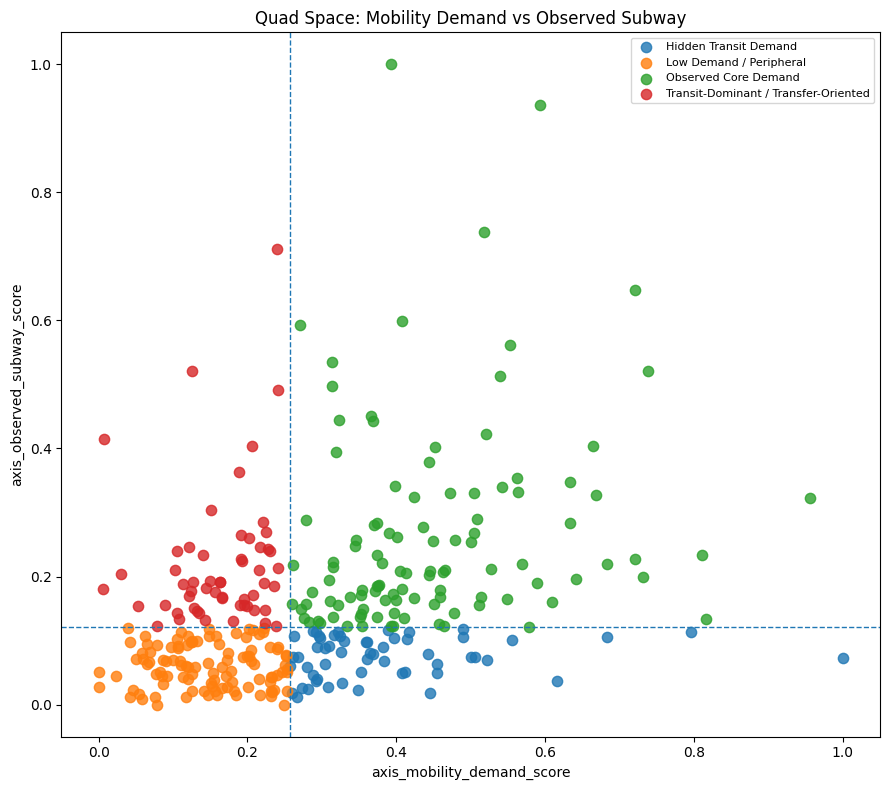

KeyError: 'quad_hidden_vs_visual.png'

<Figure size 900x800 with 0 Axes>

In [9]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA


# ============================================================
# LOAD
# ============================================================

RESULT_DIR = "seoul_station_multimodal/results"
CSV = f"{RESULT_DIR}/multimodal_cluster_result.csv"

df = pd.read_csv(CSV)

os.makedirs(RESULT_DIR, exist_ok=True)

name_col = "nearest_station" if "nearest_station" in df.columns else "station_name"


# ============================================================
# FEATURE GROUPS
# ============================================================

visual_cols = [c for c in df.columns if c.startswith("visual_emb_")]

subway_cols = [
    c for c in [
        "subway_total_activity",
        "subway_flow_ratio",
        "subway_capture_rate",
    ]
    if c in df.columns
]

mobility_cols = [
    c for c in [
        "surrounding_total_flow",
        "surrounding_outflow",
        "surrounding_inflow",
        "mean_cell_flow",
        "mapped_cell_count",
        "active_cell_count",
    ]
    if c in df.columns
]

hidden_cols = [
    c for c in [
        "mobility_minus_subway_gap",
        "outer_1km_plus_share",
    ]
    if c in df.columns
]

temporal_cols = [
    c for c in df.columns
    if (
        "time" in c.lower()
        or "temporal" in c.lower()
        or "morning" in c.lower()
        or "evening" in c.lower()
        or "night" in c.lower()
        or "weekend" in c.lower()
        or "peak" in c.lower()
    )
    and pd.api.types.is_numeric_dtype(df[c])
]


# ============================================================
# HELPERS
# ============================================================

def zscore_series(x):
    x = pd.to_numeric(x, errors="coerce").fillna(0).values.reshape(-1, 1)
    return StandardScaler().fit_transform(x).ravel()


def make_axis_from_cols(df, cols, axis_name):
    if len(cols) == 0:
        print(f"[WARN] No columns for {axis_name}. Using zeros.")
        return np.zeros(len(df))

    X = df[cols].fillna(0).values
    X = StandardScaler().fit_transform(X)

    if X.shape[1] == 1:
        axis = X[:, 0]
    else:
        pca = PCA(n_components=1, random_state=42)
        axis = pca.fit_transform(X).ravel()

    # 방향 맞추기: 평균 flow/activity와 양의 상관 되도록
    ref_candidates = [
        "surrounding_total_flow",
        "subway_total_activity",
        "mobility_minus_subway_gap",
        "outer_1km_plus_share",
    ]

    for ref in ref_candidates:
        if ref in cols:
            ref_z = zscore_series(df[ref])
            corr = np.corrcoef(axis, ref_z)[0, 1]
            if corr < 0:
                axis = -axis
            break

    return axis


def normalize_0_1(x):
    x = np.asarray(x)
    mn, mx = np.nanmin(x), np.nanmax(x)
    if mx - mn == 0:
        return np.zeros_like(x)
    return (x - mn) / (mx - mn)


def high_low_label(x, high_name, low_name):
    med = np.nanmedian(x)
    return np.where(x >= med, high_name, low_name)


# ============================================================
# QUAD AXES
# ============================================================

df["axis_mobility_demand"] = make_axis_from_cols(
    df,
    mobility_cols,
    "mobility_demand"
)

df["axis_observed_subway"] = make_axis_from_cols(
    df,
    subway_cols,
    "observed_subway"
)

df["axis_hidden_gap"] = make_axis_from_cols(
    df,
    hidden_cols,
    "hidden_gap"
)

df["axis_visual_morphology"] = make_axis_from_cols(
    df,
    visual_cols,
    "visual_morphology"
)

df["axis_temporal_dynamics"] = make_axis_from_cols(
    df,
    temporal_cols,
    "temporal_dynamics"
)


# 0~1 score도 저장
for col in [
    "axis_mobility_demand",
    "axis_observed_subway",
    "axis_hidden_gap",
    "axis_visual_morphology",
    "axis_temporal_dynamics",
]:
    df[col + "_score"] = normalize_0_1(df[col])


# ============================================================
# CORE QUADRANT 1: Mobility Demand vs Observed Subway
# ============================================================

df["quad_mobility_subway"] = (
    high_low_label(df["axis_mobility_demand"], "HighMobility", "LowMobility")
    + "_"
    + high_low_label(df["axis_observed_subway"], "HighSubway", "LowSubway")
)

quad_map_1 = {
    "HighMobility_HighSubway": "Observed Core Demand",
    "HighMobility_LowSubway": "Hidden Transit Demand",
    "LowMobility_HighSubway": "Transit-Dominant / Transfer-Oriented",
    "LowMobility_LowSubway": "Low Demand / Peripheral",
}

df["quad_mobility_subway_label"] = df["quad_mobility_subway"].map(quad_map_1)


# ============================================================
# CORE QUADRANT 2: Hidden Gap vs Visual Morphology
# ============================================================

df["quad_hidden_visual"] = (
    high_low_label(df["axis_hidden_gap"], "HighHiddenGap", "LowHiddenGap")
    + "_"
    + high_low_label(df["axis_visual_morphology"], "HighVisual", "LowVisual")
)

quad_map_2 = {
    "HighHiddenGap_HighVisual": "Morphology-Supported Hidden Demand",
    "HighHiddenGap_LowVisual": "Behavioral Hidden Demand",
    "LowHiddenGap_HighVisual": "Visually Dense but Transit-Captured",
    "LowHiddenGap_LowVisual": "Low Visual / Low Hidden",
}

df["quad_hidden_visual_label"] = df["quad_hidden_visual"].map(quad_map_2)


# ============================================================
# CORE QUADRANT 3: Temporal Dynamics vs Visual Morphology
# ============================================================

df["quad_temporal_visual"] = (
    high_low_label(df["axis_temporal_dynamics"], "HighTemporal", "LowTemporal")
    + "_"
    + high_low_label(df["axis_visual_morphology"], "HighVisual", "LowVisual")
)

quad_map_3 = {
    "HighTemporal_HighVisual": "Dynamic Dense Urban Area",
    "HighTemporal_LowVisual": "Dynamic Behavioral Area",
    "LowTemporal_HighVisual": "Stable Dense Urban Area",
    "LowTemporal_LowVisual": "Stable Low-Intensity Area",
}

df["quad_temporal_visual_label"] = df["quad_temporal_visual"].map(quad_map_3)


# ============================================================
# MULTI-AXIS QUAD SIGNATURE
# ============================================================

df["quad_signature"] = (
    high_low_label(df["axis_mobility_demand"], "M+", "M-")
    + high_low_label(df["axis_observed_subway"], "S+", "S-")
    + high_low_label(df["axis_hidden_gap"], "H+", "H-")
    + high_low_label(df["axis_visual_morphology"], "V+", "V-")
    + high_low_label(df["axis_temporal_dynamics"], "T+", "T-")
)


# ============================================================
# SAVE TABLE
# ============================================================

quad_cols = [
    "station_id",
    name_col,
    "nearest_line" if "nearest_line" in df.columns else None,
    "cluster" if "cluster" in df.columns else None,
    "quad_mobility_subway_label",
    "quad_hidden_visual_label",
    "quad_temporal_visual_label",
    "quad_signature",
    "axis_mobility_demand_score",
    "axis_observed_subway_score",
    "axis_hidden_gap_score",
    "axis_visual_morphology_score",
    "axis_temporal_dynamics_score",
    "surrounding_total_flow" if "surrounding_total_flow" in df.columns else None,
    "subway_total_activity" if "subway_total_activity" in df.columns else None,
    "mobility_minus_subway_gap" if "mobility_minus_subway_gap" in df.columns else None,
    "outer_1km_plus_share" if "outer_1km_plus_share" in df.columns else None,
]

quad_cols = [c for c in quad_cols if c is not None and c in df.columns]

quad_df = df[quad_cols].copy()

quad_csv = f"{RESULT_DIR}/quad_latent_decomposition.csv"
quad_df.to_csv(quad_csv, index=False)

print("Saved:", quad_csv)
print(quad_df.head())


# ============================================================
# SUMMARY TABLES
# ============================================================

for col in [
    "quad_mobility_subway_label",
    "quad_hidden_visual_label",
    "quad_temporal_visual_label",
    "quad_signature",
]:
    summary = (
        df[col]
        .value_counts()
        .reset_index()
    )
    summary.columns = [col, "count"]
    summary.to_csv(f"{RESULT_DIR}/{col}_summary.csv", index=False)

    print("\n" + "=" * 70)
    print(col)
    print(summary)


# ============================================================
# REPRESENTATIVE STATIONS PER QUAD
# ============================================================

rep_rows = []

for label_col in [
    "quad_mobility_subway_label",
    "quad_hidden_visual_label",
    "quad_temporal_visual_label",
]:
    for label, tmp in df.groupby(label_col):
        tmp = tmp.copy()

        if label_col == "quad_mobility_subway_label":
            tmp["rank_score"] = (
                tmp["axis_mobility_demand_score"]
                + tmp["axis_observed_subway_score"]
            )

        elif label_col == "quad_hidden_visual_label":
            tmp["rank_score"] = (
                tmp["axis_hidden_gap_score"]
                + tmp["axis_visual_morphology_score"]
            )

        else:
            tmp["rank_score"] = (
                tmp["axis_temporal_dynamics_score"]
                + tmp["axis_visual_morphology_score"]
            )

        tmp = tmp.sort_values("rank_score", ascending=False).head(10)

        for _, row in tmp.iterrows():
            rep_rows.append({
                "quad_type": label_col,
                "quad_label": label,
                "station_id": row["station_id"],
                "station_name": row[name_col],
                "nearest_line": row["nearest_line"] if "nearest_line" in row else None,
                "rank_score": row["rank_score"],
                "mobility_score": row["axis_mobility_demand_score"],
                "subway_score": row["axis_observed_subway_score"],
                "hidden_gap_score": row["axis_hidden_gap_score"],
                "visual_score": row["axis_visual_morphology_score"],
                "temporal_score": row["axis_temporal_dynamics_score"],
            })

rep_df = pd.DataFrame(rep_rows)
rep_df.to_csv(f"{RESULT_DIR}/quad_representative_stations.csv", index=False)

print("\nSaved representative stations.")
print(rep_df.head(30).to_string(index=False))


# ============================================================
# PLOTS
# ============================================================

def plot_quad(x_col, y_col, label_col, filename, title):
    plt.figure(figsize=(9, 8))

    labels = df[label_col].astype(str)
    unique_labels = sorted(labels.unique())

    for lab in unique_labels:
        idx = labels == lab
        plt.scatter(
            df.loc[idx, x_col],
            df.loc[idx, y_col],
            s=55,
            alpha=0.8,
            label=lab,
        )

    plt.axvline(np.nanmedian(df[x_col]), linestyle="--", linewidth=1)
    plt.axhline(np.nanmedian(df[y_col]), linestyle="--", linewidth=1)

    plt.xlabel(x_col)
    plt.ylabel(y_col)
    plt.title(title)
    plt.legend(fontsize=8)
    plt.tight_layout()
    plt.savefig(f"{RESULT_DIR}/{filename}", dpi=220)
    plt.show()


plot_quad(
    "axis_mobility_demand_score",
    "axis_observed_subway_score",
    "quad_mobility_subway_label",
    "quad_mobility_vs_subway.png",
    "Quad Space: Mobility Demand vs Observed Subway"
)

plot_quad(
    "axis_hidden_gap_score",
    "axis_visual_morphology_score",
    "quad_hidden_vs_visual.png",
    "quad_hidden_visual_label",
    "Quad Space: Hidden Gap vs Visual Morphology"
)

plot_quad(
    "axis_temporal_dynamics_score",
    "axis_visual_morphology_score",
    "quad_temporal_visual.png",
    "quad_temporal_visual_label",
    "Quad Space: Temporal Dynamics vs Visual Morphology"
)


# ============================================================
# TOP HIDDEN DEMAND CANDIDATES
# ============================================================

candidate = df[
    df["quad_mobility_subway_label"]
    == "Hidden Transit Demand"
].copy()

candidate["quad_hidden_priority_score"] = (
    0.40 * candidate["axis_mobility_demand_score"]
    + 0.30 * candidate["axis_hidden_gap_score"]
    + 0.20 * candidate["axis_visual_morphology_score"]
    + 0.10 * candidate["axis_temporal_dynamics_score"]
)

candidate = candidate.sort_values(
    "quad_hidden_priority_score",
    ascending=False
)

candidate_cols = [
    "station_id",
    name_col,
    "nearest_line" if "nearest_line" in candidate.columns else None,
    "quad_hidden_priority_score",
    "axis_mobility_demand_score",
    "axis_observed_subway_score",
    "axis_hidden_gap_score",
    "axis_visual_morphology_score",
    "axis_temporal_dynamics_score",
    "surrounding_total_flow" if "surrounding_total_flow" in candidate.columns else None,
    "subway_total_activity" if "subway_total_activity" in candidate.columns else None,
    "mobility_minus_subway_gap" if "mobility_minus_subway_gap" in candidate.columns else None,
]

candidate_cols = [c for c in candidate_cols if c is not None]

candidate[candidate_cols].to_csv(
    f"{RESULT_DIR}/quad_hidden_transit_demand_candidates.csv",
    index=False,
)

print("\nTop Hidden Transit Demand Candidates:")
print(candidate[candidate_cols].head(30).to_string(index=False))


# ============================================================
# FINAL REPORT
# ============================================================

report_path = f"{RESULT_DIR}/quad_decomposition_report.txt"

with open(report_path, "w", encoding="utf-8") as f:
    f.write("Quad Latent Decomposition Report\n")
    f.write("=" * 50 + "\n\n")

    f.write("Axis definitions:\n")
    f.write("- Mobility axis: surrounding mobility demand features\n")
    f.write("- Subway axis: observed subway activity features\n")
    f.write("- Hidden gap axis: mobility-subway mismatch features\n")
    f.write("- Visual axis: CLIP-derived map/satellite/text visual-semantic embedding\n")
    f.write("- Temporal axis: temporal/peak/entropy features if available\n\n")

    for col in [
        "quad_mobility_subway_label",
        "quad_hidden_visual_label",
        "quad_temporal_visual_label",
    ]:
        f.write(f"\n{col}\n")
        f.write(str(df[col].value_counts()) + "\n")

    f.write("\nTop hidden transit demand candidates:\n")
    f.write(candidate[candidate_cols].head(30).to_string(index=False))

print("\nSaved report:", report_path)
print("DONE.")

Saved reconstruction result: seoul_station_multimodal/results/quad_reconstructed_hidden_demand_result.csv

Top 30 reconstructed hidden demand stations:
 priority_rank  station_id  nearest_station nearest_line quad_mobility_subway_label           quad_hidden_visual_label quad_temporal_visual_label quad_signature               reconstruction_label  reconstructed_latent_demand_score  axis_observed_subway_score  hidden_demand_reconstruction_score  hidden_demand_reconstruction_score_norm  axis_mobility_demand_score  axis_hidden_gap_score  axis_temporal_dynamics_score  axis_visual_morphology_score  surrounding_total_flow  subway_total_activity  mobility_minus_subway_gap  outer_1km_plus_share
             1        2561               마천          5호선      Hidden Transit Demand           Behavioral Hidden Demand    Dynamic Behavioral Area     M+S-H+V-T+        High Priority Hidden Demand                           0.842636                    0.073462                            0.769174           

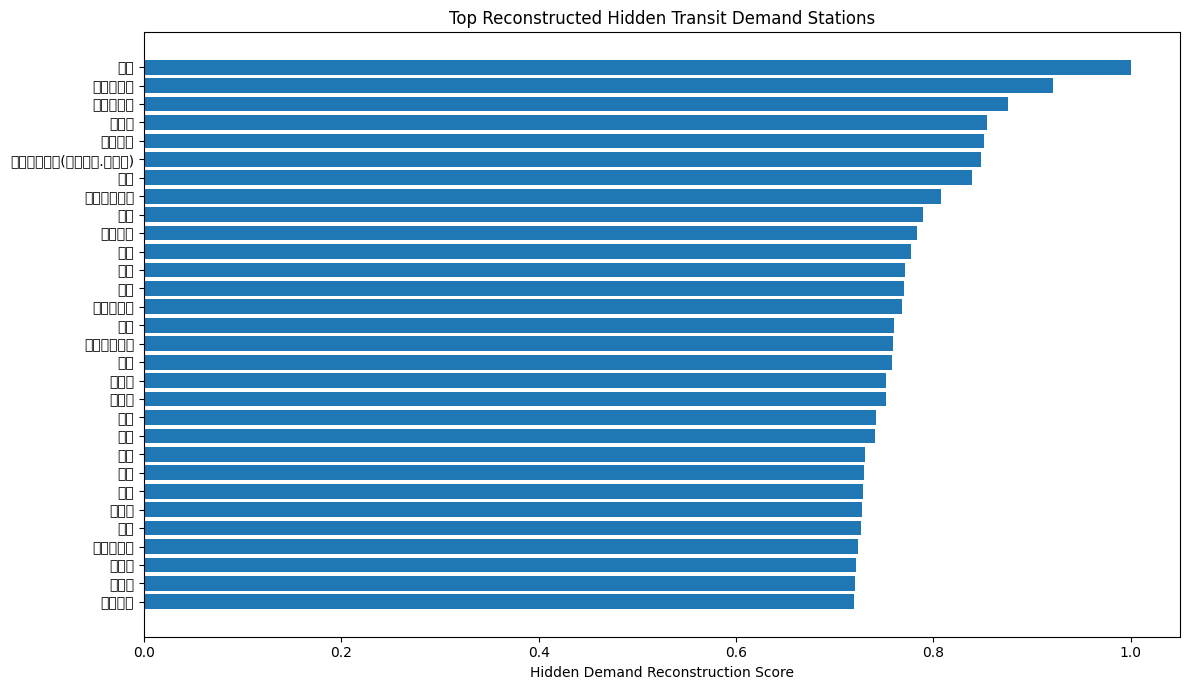

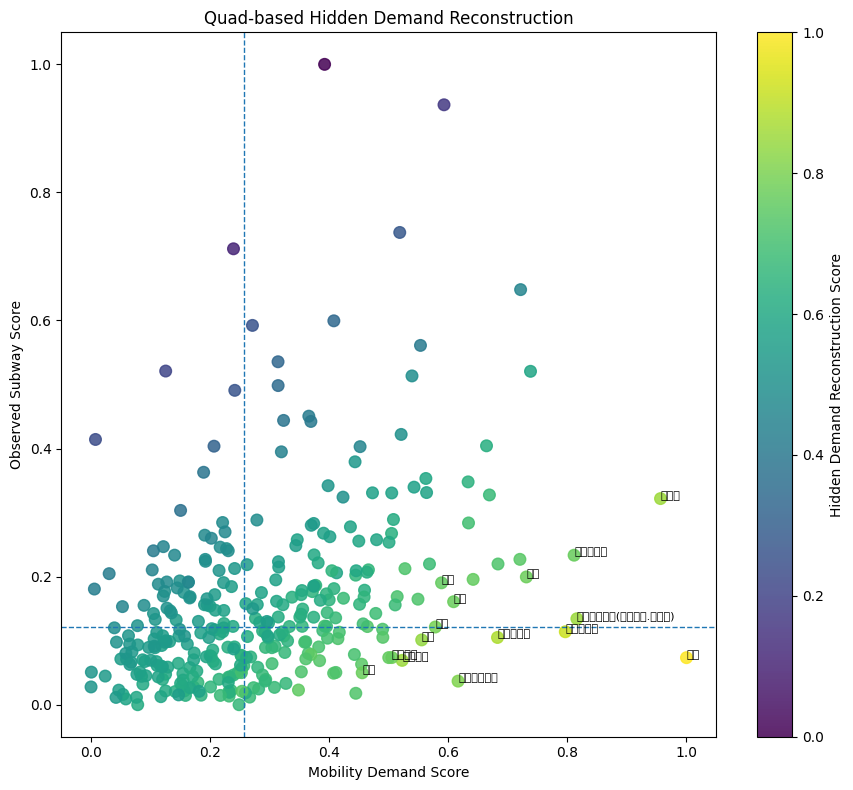

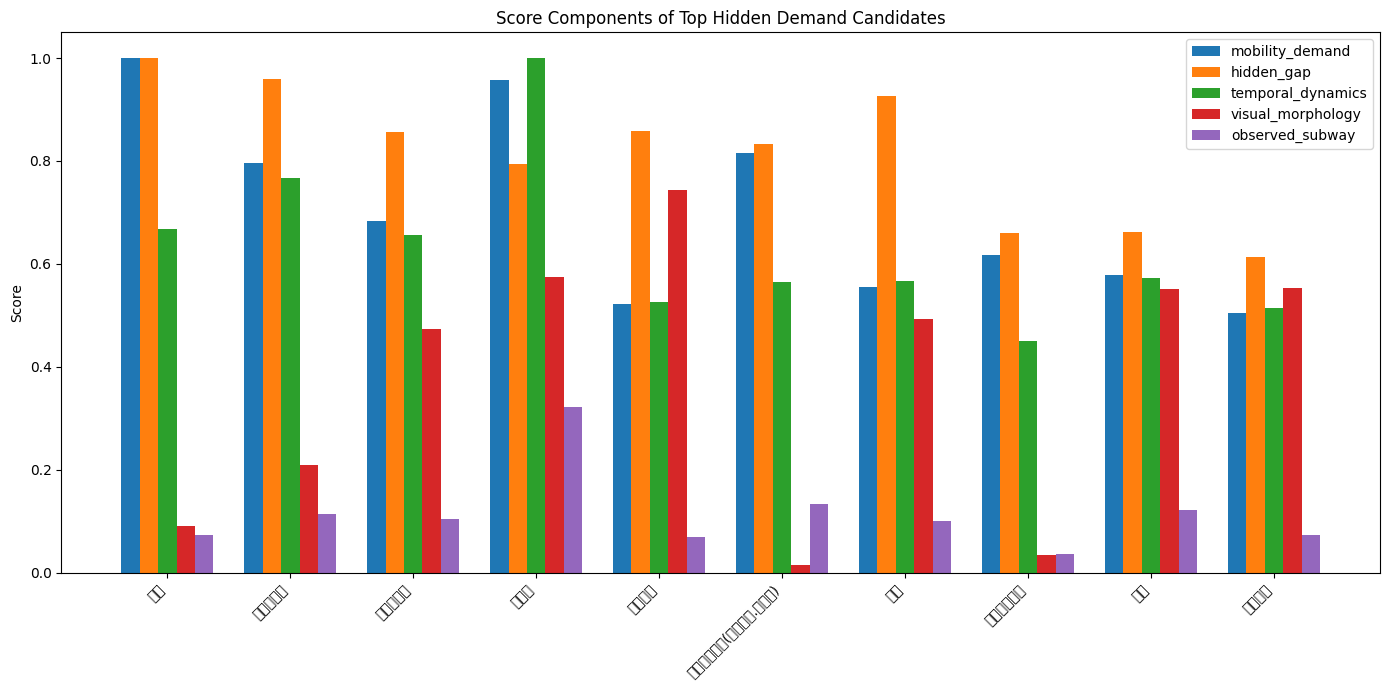


Saved report: seoul_station_multimodal/results/reconstruction_report.txt
DONE.


In [10]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr, pearsonr

# ============================================================
# PATH
# ============================================================

RESULT_DIR = "seoul_station_multimodal/results"
QUAD_CSV = f"{RESULT_DIR}/quad_latent_decomposition.csv"

os.makedirs(RESULT_DIR, exist_ok=True)

df = pd.read_csv(QUAD_CSV)

name_col = "nearest_station" if "nearest_station" in df.columns else "station_name"

# ============================================================
# 1. RECONSTRUCT LATENT DEMAND SCORE
# ============================================================

required_cols = [
    "axis_mobility_demand_score",
    "axis_observed_subway_score",
    "axis_hidden_gap_score",
    "axis_visual_morphology_score",
    "axis_temporal_dynamics_score",
]

for c in required_cols:
    if c not in df.columns:
        raise ValueError(f"Missing required column: {c}")

df["reconstructed_latent_demand_score"] = (
    0.45 * df["axis_mobility_demand_score"]
    + 0.25 * df["axis_hidden_gap_score"]
    + 0.20 * df["axis_temporal_dynamics_score"]
    + 0.10 * df["axis_visual_morphology_score"]
)

df["hidden_demand_reconstruction_score"] = (
    df["reconstructed_latent_demand_score"]
    - df["axis_observed_subway_score"]
)

x = df["hidden_demand_reconstruction_score"].values
df["hidden_demand_reconstruction_score_norm"] = (
    (x - x.min()) / (x.max() - x.min())
)

# ============================================================
# 2. RECONSTRUCTION LABEL
# ============================================================

def label_reconstruction(row):
    if row["quad_mobility_subway_label"] == "Hidden Transit Demand":
        return "High Priority Hidden Demand"
    if row["hidden_demand_reconstruction_score_norm"] >= 0.75:
        return "Potential Hidden Demand"
    if row["quad_hidden_visual_label"] == "Morphology-Supported Hidden Demand":
        return "Morphology-Supported Hidden Demand"
    if row["quad_mobility_subway_label"] == "Observed Core Demand":
        return "Already Captured Core Demand"
    if row["quad_mobility_subway_label"] == "Transit-Dominant / Transfer-Oriented":
        return "Transit-Dominant Demand"
    return "Low Priority"

df["reconstruction_label"] = df.apply(label_reconstruction, axis=1)

df["priority_rank"] = (
    df["hidden_demand_reconstruction_score_norm"]
    .rank(ascending=False, method="dense")
    .astype(int)
)

# ============================================================
# 3. SAVE MAIN RECONSTRUCTION RESULT
# ============================================================

out_cols = [
    "priority_rank",
    "station_id",
    name_col,
    "nearest_line" if "nearest_line" in df.columns else None,
    "quad_mobility_subway_label",
    "quad_hidden_visual_label",
    "quad_temporal_visual_label",
    "quad_signature" if "quad_signature" in df.columns else None,
    "reconstruction_label",
    "reconstructed_latent_demand_score",
    "axis_observed_subway_score",
    "hidden_demand_reconstruction_score",
    "hidden_demand_reconstruction_score_norm",
    "axis_mobility_demand_score",
    "axis_hidden_gap_score",
    "axis_temporal_dynamics_score",
    "axis_visual_morphology_score",
    "surrounding_total_flow" if "surrounding_total_flow" in df.columns else None,
    "subway_total_activity" if "subway_total_activity" in df.columns else None,
    "mobility_minus_subway_gap" if "mobility_minus_subway_gap" in df.columns else None,
    "outer_1km_plus_share" if "outer_1km_plus_share" in df.columns else None,
]

out_cols = [c for c in out_cols if c is not None and c in df.columns]

recon = df[out_cols].sort_values("priority_rank")

recon_csv = f"{RESULT_DIR}/quad_reconstructed_hidden_demand_result.csv"
recon.to_csv(recon_csv, index=False)

print("Saved reconstruction result:", recon_csv)
print("\nTop 30 reconstructed hidden demand stations:")
print(recon.head(30).to_string(index=False))

# ============================================================
# 4. SUMMARY TABLES
# ============================================================

summary = (
    df["reconstruction_label"]
    .value_counts()
    .reset_index()
)
summary.columns = ["reconstruction_label", "count"]
summary.to_csv(f"{RESULT_DIR}/reconstruction_label_summary.csv", index=False)

quad_summary = pd.crosstab(
    df["quad_mobility_subway_label"],
    df["reconstruction_label"]
)
quad_summary.to_csv(f"{RESULT_DIR}/reconstruction_by_quad_summary.csv")

print("\nReconstruction label summary:")
print(summary)

print("\nReconstruction by quad:")
print(quad_summary)

# ============================================================
# 5. VALIDATION
# ============================================================

validation_targets = [
    "mobility_minus_subway_gap",
    "outer_1km_plus_share",
    "surrounding_total_flow",
    "subway_total_activity",
    "axis_mobility_demand_score",
    "axis_hidden_gap_score",
    "axis_observed_subway_score",
]

val_rows = []

score = df["hidden_demand_reconstruction_score_norm"].values

for col in validation_targets:
    if col not in df.columns:
        continue

    y = pd.to_numeric(df[col], errors="coerce").fillna(0).values

    sp = spearmanr(score, y).correlation
    pr = pearsonr(score, y)[0]

    val_rows.append({
        "target": col,
        "spearman_corr_with_reconstruction": sp,
        "pearson_corr_with_reconstruction": pr,
    })

validation_df = pd.DataFrame(val_rows)
validation_df.to_csv(f"{RESULT_DIR}/reconstruction_validation_correlations.csv", index=False)

print("\nValidation correlations:")
print(validation_df.to_string(index=False))

# ============================================================
# 6. TOP-K CASE STUDY TABLE
# ============================================================

case = recon.head(20).copy()

case["case_interpretation"] = case.apply(
    lambda r: (
        f"{r[name_col]} shows high reconstructed latent demand "
        f"with mobility score={r['axis_mobility_demand_score']:.2f}, "
        f"hidden gap={r['axis_hidden_gap_score']:.2f}, "
        f"temporal dynamics={r['axis_temporal_dynamics_score']:.2f}, "
        f"but observed subway score={r['axis_observed_subway_score']:.2f}."
    ),
    axis=1
)

case_csv = f"{RESULT_DIR}/reconstruction_case_study_top20.csv"
case.to_csv(case_csv, index=False)

print("\nSaved case study:", case_csv)
print(case[["priority_rank", name_col, "reconstruction_label", "case_interpretation"]].head(10).to_string(index=False))

# ============================================================
# 7. FIGURE 1: RECONSTRUCTION SCORE RANKING
# ============================================================

top_n = 30
top = recon.head(top_n).copy()

plt.figure(figsize=(12, 7))
plt.barh(
    top[name_col].astype(str)[::-1],
    top["hidden_demand_reconstruction_score_norm"][::-1],
)
plt.xlabel("Hidden Demand Reconstruction Score")
plt.title("Top Reconstructed Hidden Transit Demand Stations")
plt.tight_layout()
plt.savefig(f"{RESULT_DIR}/top_hidden_demand_reconstruction_ranking.png", dpi=220)
plt.show()

# ============================================================
# 8. FIGURE 2: QUAD SPACE WITH RECONSTRUCTION SCORE
# ============================================================

plt.figure(figsize=(9, 8))

scatter = plt.scatter(
    df["axis_mobility_demand_score"],
    df["axis_observed_subway_score"],
    c=df["hidden_demand_reconstruction_score_norm"],
    s=70,
    alpha=0.85,
)

plt.axvline(df["axis_mobility_demand_score"].median(), linestyle="--", linewidth=1)
plt.axhline(df["axis_observed_subway_score"].median(), linestyle="--", linewidth=1)

plt.colorbar(scatter, label="Hidden Demand Reconstruction Score")

plt.xlabel("Mobility Demand Score")
plt.ylabel("Observed Subway Score")
plt.title("Quad-based Hidden Demand Reconstruction")

hidden_top = recon.head(15)

for _, row in hidden_top.iterrows():
    station_id = row["station_id"]
    rr = df[df["station_id"] == station_id].iloc[0]

    plt.text(
        rr["axis_mobility_demand_score"],
        rr["axis_observed_subway_score"],
        str(row[name_col]),
        fontsize=8,
    )

plt.tight_layout()
plt.savefig(f"{RESULT_DIR}/quad_reconstruction_space.png", dpi=220)
plt.show()

# ============================================================
# 9. FIGURE 3: SCORE COMPONENTS FOR TOP STATIONS
# ============================================================

component_cols = [
    "axis_mobility_demand_score",
    "axis_hidden_gap_score",
    "axis_temporal_dynamics_score",
    "axis_visual_morphology_score",
    "axis_observed_subway_score",
]

top10 = recon.head(10).copy()

x = np.arange(len(top10))
width = 0.15

plt.figure(figsize=(14, 7))

for i, col in enumerate(component_cols):
    plt.bar(
        x + i * width,
        top10[col],
        width=width,
        label=col.replace("axis_", "").replace("_score", "")
    )

plt.xticks(
    x + width * 2,
    top10[name_col].astype(str),
    rotation=45,
    ha="right"
)

plt.ylabel("Score")
plt.title("Score Components of Top Hidden Demand Candidates")
plt.legend()
plt.tight_layout()
plt.savefig(f"{RESULT_DIR}/top_hidden_demand_score_components.png", dpi=220)
plt.show()

# ============================================================
# 10. FINAL REPORT TEXT
# ============================================================

report_path = f"{RESULT_DIR}/reconstruction_report.txt"

with open(report_path, "w", encoding="utf-8") as f:
    f.write("Quad-based Hidden Transit Demand Reconstruction Report\n")
    f.write("=" * 60 + "\n\n")

    f.write("Definition:\n")
    f.write(
        "Reconstructed latent demand is computed from mobility demand, hidden gap, "
        "temporal dynamics, and visual morphology. Hidden demand reconstruction score "
        "is defined as reconstructed latent demand minus observed subway score.\n\n"
    )

    f.write("Formula:\n")
    f.write(
        "ReconstructedDemand = 0.45*Mobility + 0.25*HiddenGap "
        "+ 0.20*Temporal + 0.10*Visual\n"
    )
    f.write("HiddenDemandScore = ReconstructedDemand - ObservedSubway\n\n")

    f.write("Reconstruction label summary:\n")
    f.write(summary.to_string(index=False))
    f.write("\n\n")

    f.write("Top 20 hidden demand candidates:\n")
    f.write(recon.head(20).to_string(index=False))
    f.write("\n\n")

    f.write("Validation correlations:\n")
    f.write(validation_df.to_string(index=False))

print("\nSaved report:", report_path)
print("DONE.")

Selected case stations:
 priority_rank  station_id nearest_station nearest_line        reconstruction_label  hidden_demand_reconstruction_score_norm  axis_mobility_demand_score  axis_observed_subway_score  axis_hidden_gap_score  axis_visual_morphology_score  axis_temporal_dynamics_score                                                                 map_path                                                                 satellite_path
             1        2561              마천          5호선 High Priority Hidden Demand                                 1.000000                    1.000000                    0.073462               1.000000                      0.090634                      0.667866    /workspace/yunsoyoung_cikm_kdd../images/station_tiles/map/2561_마천.png    /workspace/yunsoyoung_cikm_kdd../images/station_tiles/satellite/2561_마천.png
             2        2824           단대오거리          8호선 High Priority Hidden Demand                                 0.921235                    

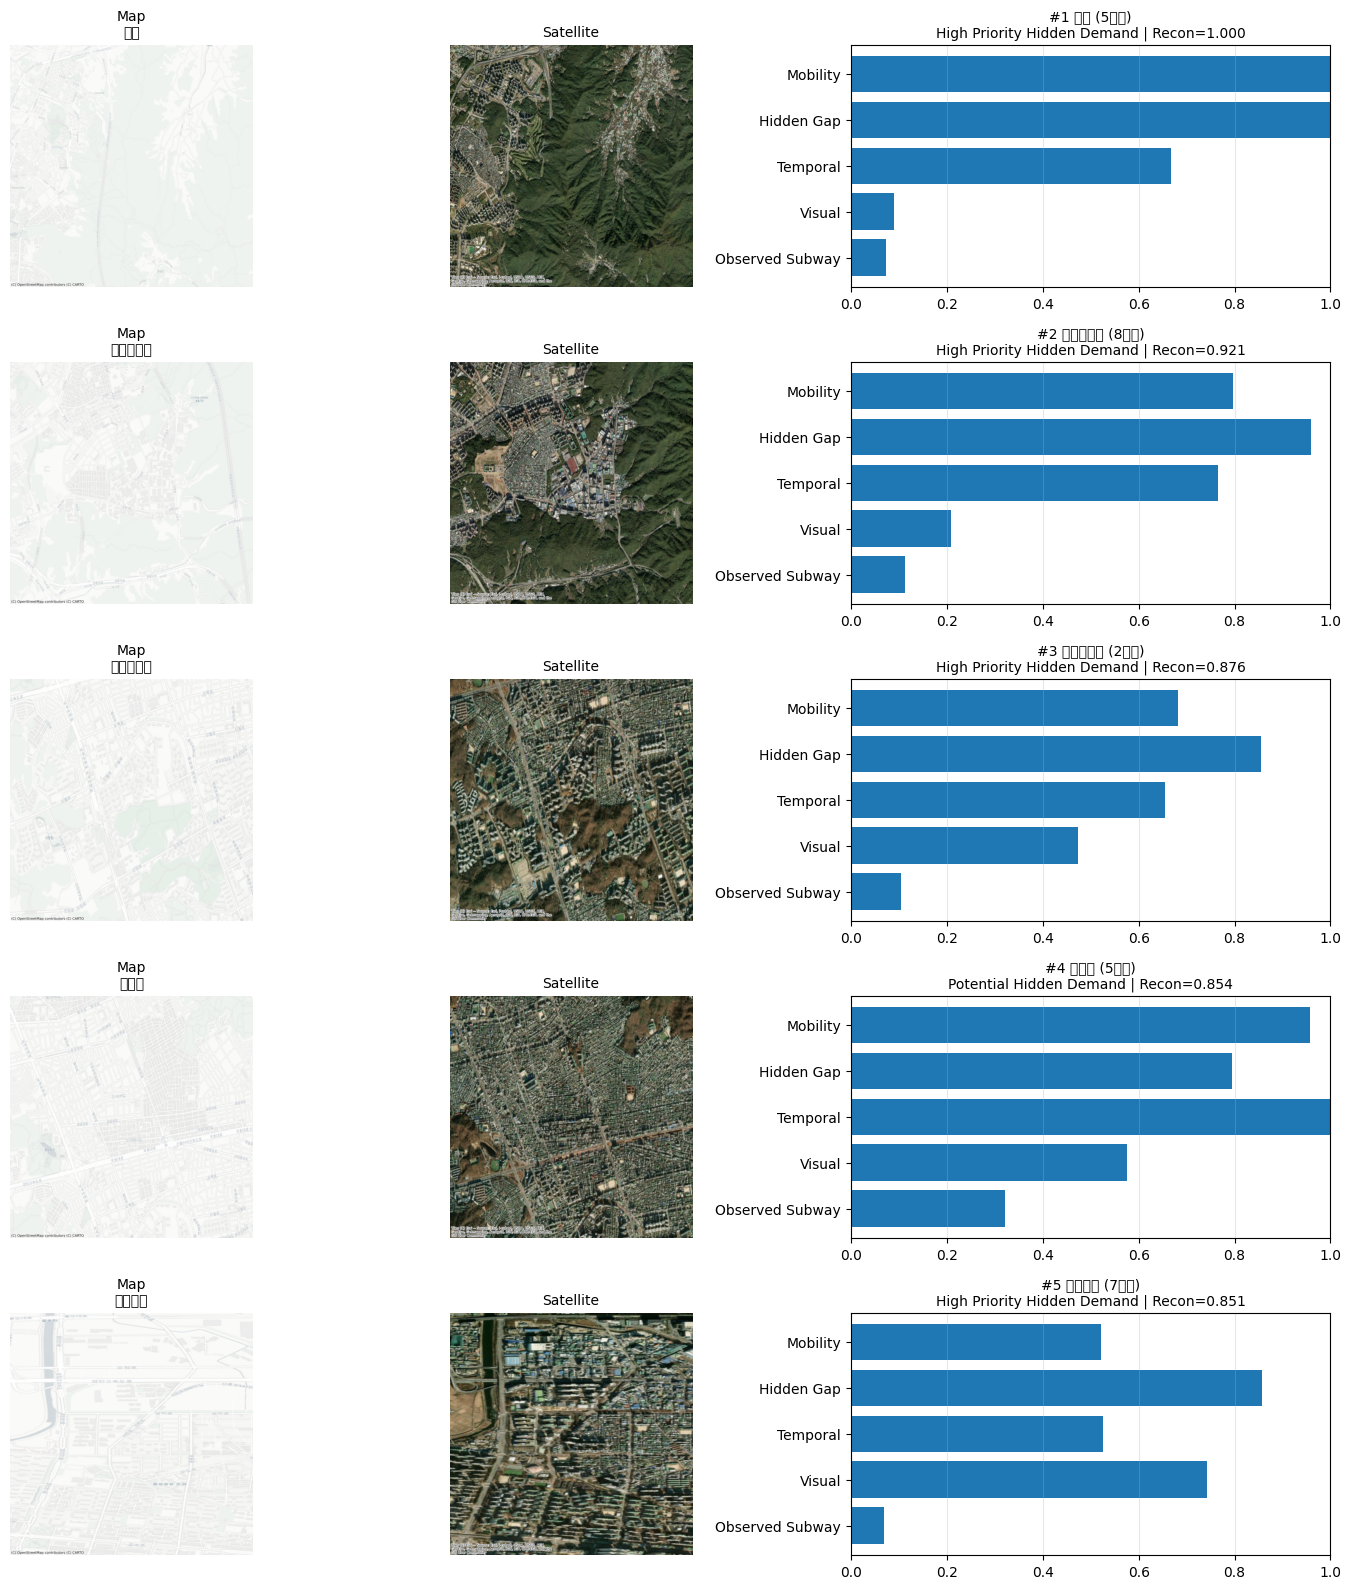

Saved figure: seoul_station_multimodal/results/case_study_top_hidden_demand.png
Saved table: seoul_station_multimodal/results/case_study_top_hidden_demand_table.csv


In [11]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from glob import glob

# ============================================================
# PATHS
# ============================================================

RESULT_DIR = "seoul_station_multimodal/results"

RECON_CSV = f"{RESULT_DIR}/quad_reconstructed_hidden_demand_result.csv"

IMAGE_ROOT = r"/workspace/yunsoyoung_cikm_kdd../images/station_tiles"
MAP_DIR = f"{IMAGE_ROOT}/map"
SAT_DIR = f"{IMAGE_ROOT}/satellite"

OUT_FIG = f"{RESULT_DIR}/case_study_top_hidden_demand.png"
OUT_TABLE = f"{RESULT_DIR}/case_study_top_hidden_demand_table.csv"

df = pd.read_csv(RECON_CSV)

name_col = "nearest_station" if "nearest_station" in df.columns else "station_name"


# ============================================================
# UTILS
# ============================================================

def find_image(img_dir, station_id):
    station_id = str(station_id)

    patterns = [
        os.path.join(img_dir, f"{station_id}_*.png"),
        os.path.join(img_dir, f"{station_id}_*.jpg"),
        os.path.join(img_dir, f"{station_id}_*.jpeg"),
    ]

    matches = []
    for p in patterns:
        matches.extend(glob(p))

    return matches[0] if matches else None


# ============================================================
# SELECT TOP CASES
# ============================================================

top = (
    df[
        df["reconstruction_label"]
        .astype(str)
        .str.contains("Hidden|Potential", case=False, na=False)
    ]
    .sort_values("priority_rank")
    .head(5)
    .copy()
)

top["map_path"] = top["station_id"].apply(lambda x: find_image(MAP_DIR, x))
top["satellite_path"] = top["station_id"].apply(lambda x: find_image(SAT_DIR, x))

top.to_csv(OUT_TABLE, index=False)

print("Selected case stations:")
print(
    top[
        [
            "priority_rank",
            "station_id",
            name_col,
            "nearest_line",
            "reconstruction_label",
            "hidden_demand_reconstruction_score_norm",
            "axis_mobility_demand_score",
            "axis_observed_subway_score",
            "axis_hidden_gap_score",
            "axis_visual_morphology_score",
            "axis_temporal_dynamics_score",
            "map_path",
            "satellite_path",
        ]
    ].to_string(index=False)
)


# ============================================================
# FIGURE: MAP + SATELLITE + SCORE COMPONENTS
# ============================================================

score_cols = [
    "axis_mobility_demand_score",
    "axis_hidden_gap_score",
    "axis_temporal_dynamics_score",
    "axis_visual_morphology_score",
    "axis_observed_subway_score",
]

score_labels = [
    "Mobility",
    "Hidden Gap",
    "Temporal",
    "Visual",
    "Observed Subway",
]

n = len(top)

fig, axes = plt.subplots(
    nrows=n,
    ncols=3,
    figsize=(14, 3.2 * n),
    gridspec_kw={"width_ratios": [1.2, 1.2, 1.8]}
)

if n == 1:
    axes = axes.reshape(1, -1)

for i, (_, row) in enumerate(top.iterrows()):

    station_name = row[name_col]
    station_id = row["station_id"]

    # ------------------------
    # Map image
    # ------------------------
    ax = axes[i, 0]
    if row["map_path"] and os.path.exists(row["map_path"]):
        img = Image.open(row["map_path"]).convert("RGB")
        ax.imshow(img)
    ax.axis("off")
    ax.set_title(f"Map\n{station_name}", fontsize=10)

    # ------------------------
    # Satellite image
    # ------------------------
    ax = axes[i, 1]
    if row["satellite_path"] and os.path.exists(row["satellite_path"]):
        img = Image.open(row["satellite_path"]).convert("RGB")
        ax.imshow(img)
    ax.axis("off")
    ax.set_title("Satellite", fontsize=10)

    # ------------------------
    # Score bar
    # ------------------------
    ax = axes[i, 2]

    values = [row[c] for c in score_cols]

    ax.barh(score_labels, values)

    ax.set_xlim(0, 1)
    ax.invert_yaxis()

    title = (
        f"#{int(row['priority_rank'])} {station_name} ({row['nearest_line']})\n"
        f"{row['reconstruction_label']} | "
        f"Recon={row['hidden_demand_reconstruction_score_norm']:.3f}"
    )

    ax.set_title(title, fontsize=10)
    ax.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.savefig(OUT_FIG, dpi=240, bbox_inches="tight")
plt.show()

print("Saved figure:", OUT_FIG)
print("Saved table:", OUT_TABLE)


=== Baseline Comparison ===
               method  spearman_with_gap  pearson_with_gap
mobility_minus_subway           0.956405          0.958106
      hidden_gap_only           0.927238          0.848908
  quad_reconstruction           0.905919          0.922644
        mobility_only           0.760649          0.708225
        temporal_only           0.716114          0.639704
  subway_inverse_only           0.119081          0.343035
          visual_only          -0.433454         -0.385320


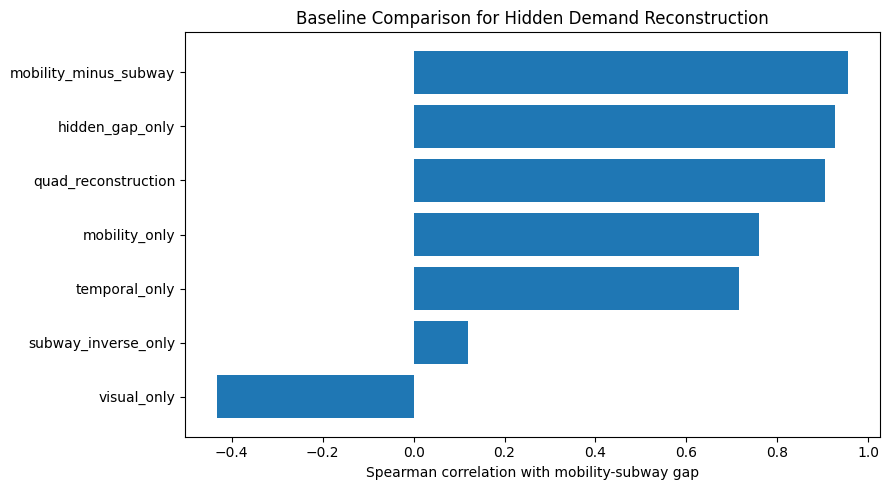


=== Weight Sensitivity Top 20 ===
 w_mobility  w_hidden_gap  w_temporal  w_visual  spearman_with_gap  pearson_with_gap                                                       top10_stations
   0.550000      0.150000    0.300000  0.000000           0.958234          0.965017 마천; 단대오거리; 까치산; 남한산성입구(성남법원.검찰청); 신정네거리; 북한산보국문; 홍제; 거여; 광명사거리; 부천시청
   0.500000      0.166667    0.333333  0.000000           0.957886          0.964950 마천; 단대오거리; 까치산; 남한산성입구(성남법원.검찰청); 신정네거리; 북한산보국문; 거여; 홍제; 부천시청; 광명사거리
   0.437500      0.187500    0.375000  0.000000           0.957320          0.964618 마천; 단대오거리; 까치산; 신정네거리; 남한산성입구(성남법원.검찰청); 거여; 북한산보국문; 부천시청; 홍제; 광명사거리
   0.611111      0.166667    0.222222  0.000000           0.949308          0.957547 마천; 단대오거리; 남한산성입구(성남법원.검찰청); 까치산; 신정네거리; 북한산보국문; 홍제; 광명사거리; 거여; 부천시청
   0.562500      0.187500    0.250000  0.000000           0.948274          0.956543 마천; 단대오거리; 남한산성입구(성남법원.검찰청); 까치산; 신정네거리; 북한산보국문; 거여; 홍제; 부천시청; 광명사거리
   0.500000      0.214286    0.285714  0.

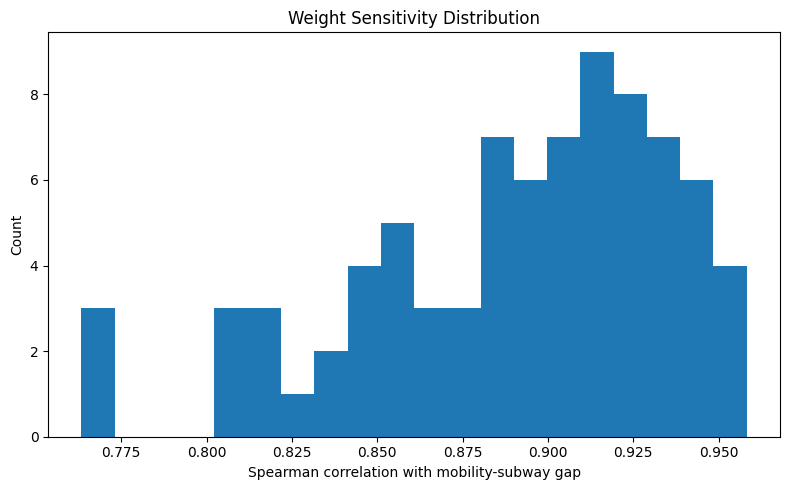


=== Top Station Robustness ===
    station_name  top10_frequency
              마천               81
           단대오거리               81
             까치산               81
남한산성입구(성남법원.검찰청)               81
           신정네거리               81
              거여               81
            부천시청               81
          북한산보국문               72
              가양               53
            양천구청               44
              홍제               32
           광명사거리               25
          중앙보훈병원                6
             신중동                6
              개화                2
             신목동                2
              장지                1


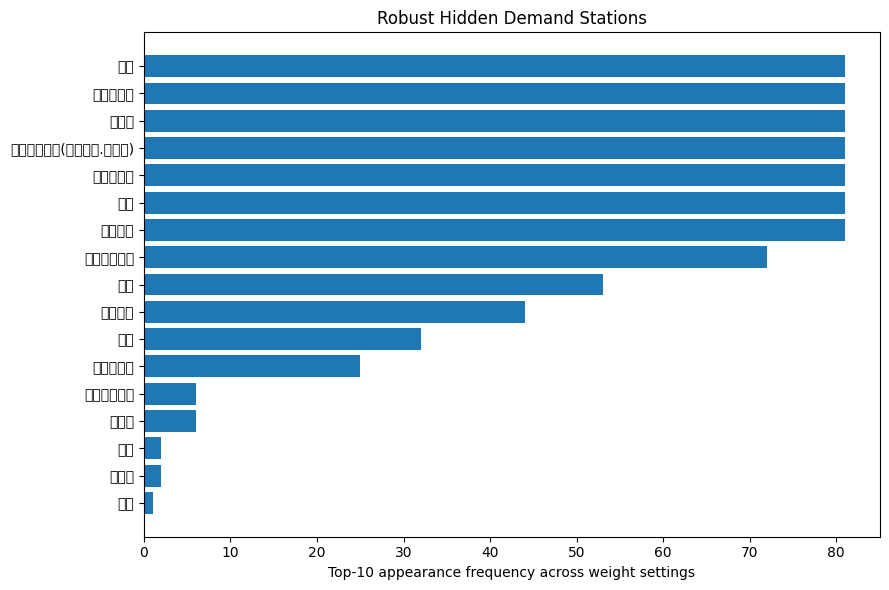


Saved:
seoul_station_multimodal/results/baseline_reconstruction_comparison.csv
seoul_station_multimodal/results/weight_sensitivity_results.csv
seoul_station_multimodal/results/top_station_robustness.csv
seoul_station_multimodal/results/additional_experiment_report.txt


In [12]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr, pearsonr

# ============================================================
# PATH
# ============================================================

RESULT_DIR = "seoul_station_multimodal/results"
QUAD_CSV = f"{RESULT_DIR}/quad_latent_decomposition.csv"

df = pd.read_csv(QUAD_CSV)

name_col = "nearest_station" if "nearest_station" in df.columns else "station_name"

os.makedirs(RESULT_DIR, exist_ok=True)

# ============================================================
# TARGET
# ============================================================

target_col = "mobility_minus_subway_gap"

if target_col not in df.columns:
    raise ValueError(f"Missing target column: {target_col}")

target = df[target_col].values

# ============================================================
# 1. BASELINE COMPARISON
# ============================================================

score_defs = {
    "subway_inverse_only": 1 - df["axis_observed_subway_score"],
    "mobility_only": df["axis_mobility_demand_score"],
    "hidden_gap_only": df["axis_hidden_gap_score"],
    "temporal_only": df["axis_temporal_dynamics_score"],
    "visual_only": df["axis_visual_morphology_score"],
    "mobility_minus_subway": (
        df["axis_mobility_demand_score"]
        - df["axis_observed_subway_score"]
    ),
    "quad_reconstruction": (
        0.45 * df["axis_mobility_demand_score"]
        + 0.25 * df["axis_hidden_gap_score"]
        + 0.20 * df["axis_temporal_dynamics_score"]
        + 0.10 * df["axis_visual_morphology_score"]
        - df["axis_observed_subway_score"]
    ),
}

rows = []

for name, score in score_defs.items():
    score = np.asarray(score)

    sp = spearmanr(score, target).correlation
    pr = pearsonr(score, target)[0]

    rows.append({
        "method": name,
        "spearman_with_gap": sp,
        "pearson_with_gap": pr,
    })

baseline_df = pd.DataFrame(rows).sort_values(
    "spearman_with_gap",
    ascending=False
)

baseline_csv = f"{RESULT_DIR}/baseline_reconstruction_comparison.csv"
baseline_df.to_csv(baseline_csv, index=False)

print("\n=== Baseline Comparison ===")
print(baseline_df.to_string(index=False))


plt.figure(figsize=(9, 5))
plt.barh(
    baseline_df["method"],
    baseline_df["spearman_with_gap"]
)
plt.gca().invert_yaxis()
plt.xlabel("Spearman correlation with mobility-subway gap")
plt.title("Baseline Comparison for Hidden Demand Reconstruction")
plt.tight_layout()
plt.savefig(f"{RESULT_DIR}/baseline_reconstruction_comparison.png", dpi=220)
plt.show()


# ============================================================
# 2. WEIGHT SENSITIVITY
# ============================================================

weight_results = []

mob_w_list = [0.35, 0.45, 0.55]
gap_w_list = [0.15, 0.25, 0.35]
temp_w_list = [0.10, 0.20, 0.30]
vis_w_list = [0.00, 0.10, 0.20]

for wm in mob_w_list:
    for wg in gap_w_list:
        for wt in temp_w_list:
            for wv in vis_w_list:

                total = wm + wg + wt + wv

                wm_n = wm / total
                wg_n = wg / total
                wt_n = wt / total
                wv_n = wv / total

                latent = (
                    wm_n * df["axis_mobility_demand_score"]
                    + wg_n * df["axis_hidden_gap_score"]
                    + wt_n * df["axis_temporal_dynamics_score"]
                    + wv_n * df["axis_visual_morphology_score"]
                )

                score = latent - df["axis_observed_subway_score"]

                sp = spearmanr(score, target).correlation
                pr = pearsonr(score, target)[0]

                top10 = (
                    df.assign(score=score)
                    .sort_values("score", ascending=False)
                    .head(10)[name_col]
                    .tolist()
                )

                weight_results.append({
                    "w_mobility": wm_n,
                    "w_hidden_gap": wg_n,
                    "w_temporal": wt_n,
                    "w_visual": wv_n,
                    "spearman_with_gap": sp,
                    "pearson_with_gap": pr,
                    "top10_stations": "; ".join(map(str, top10)),
                })

weight_df = pd.DataFrame(weight_results).sort_values(
    "spearman_with_gap",
    ascending=False
)

weight_csv = f"{RESULT_DIR}/weight_sensitivity_results.csv"
weight_df.to_csv(weight_csv, index=False)

print("\n=== Weight Sensitivity Top 20 ===")
print(weight_df.head(20).to_string(index=False))


plt.figure(figsize=(8, 5))
plt.hist(
    weight_df["spearman_with_gap"],
    bins=20
)
plt.xlabel("Spearman correlation with mobility-subway gap")
plt.ylabel("Count")
plt.title("Weight Sensitivity Distribution")
plt.tight_layout()
plt.savefig(f"{RESULT_DIR}/weight_sensitivity_distribution.png", dpi=220)
plt.show()


# ============================================================
# 3. TOP STATION ROBUSTNESS
# ============================================================

top_k = 20

station_counts = {}

for _, row in weight_df.iterrows():
    stations = str(row["top10_stations"]).split("; ")

    for s in stations:
        station_counts[s] = station_counts.get(s, 0) + 1

robust_df = (
    pd.DataFrame(
        [
            {"station_name": k, "top10_frequency": v}
            for k, v in station_counts.items()
        ]
    )
    .sort_values("top10_frequency", ascending=False)
)

robust_csv = f"{RESULT_DIR}/top_station_robustness.csv"
robust_df.to_csv(robust_csv, index=False)

print("\n=== Top Station Robustness ===")
print(robust_df.head(30).to_string(index=False))


plt.figure(figsize=(9, 6))
plt.barh(
    robust_df.head(20)["station_name"][::-1],
    robust_df.head(20)["top10_frequency"][::-1]
)
plt.xlabel("Top-10 appearance frequency across weight settings")
plt.title("Robust Hidden Demand Stations")
plt.tight_layout()
plt.savefig(f"{RESULT_DIR}/top_station_robustness.png", dpi=220)
plt.show()


# ============================================================
# 4. FINAL ROBUSTNESS REPORT
# ============================================================

report_path = f"{RESULT_DIR}/additional_experiment_report.txt"

with open(report_path, "w", encoding="utf-8") as f:
    f.write("Additional Experiments Report\n")
    f.write("=" * 50 + "\n\n")

    f.write("1. Baseline Comparison\n")
    f.write(baseline_df.to_string(index=False))
    f.write("\n\n")

    f.write("2. Weight Sensitivity Top 20\n")
    f.write(weight_df.head(20).to_string(index=False))
    f.write("\n\n")

    f.write("3. Robust Top Stations\n")
    f.write(robust_df.head(30).to_string(index=False))
    f.write("\n")

print("\nSaved:")
print(baseline_csv)
print(weight_csv)
print(robust_csv)
print(report_path)

DEVICE: cuda
Loading CLIP...


Loading weights: 100%|██████████| 398/398 [00:00<00:00, 25273.78it/s]


Prompt embeddings: (15, 512)
Valid stations: 327


Encoding images: 100%|██████████| 6/6 [00:35<00:00,  5.96s/it]


Saved semantic profile: seoul_station_multimodal/results/station_semantic_prompt_profile.csv
   station_id nearest_station nearest_line         reconstruction_label  \
0        2561              마천          5호선  High Priority Hidden Demand   
1        2824           단대오거리          8호선  High Priority Hidden Demand   
2         249           신정네거리          2호선  High Priority Hidden Demand   
3        2519             까치산          5호선      Potential Hidden Demand   
4        2757            부천시청          7호선  High Priority Hidden Demand   

   hidden_demand_reconstruction_score_norm quad_mobility_subway_label  \
0                                 1.000000      Hidden Transit Demand   
1                                 0.921235      Hidden Transit Demand   
2                                 0.875657      Hidden Transit Demand   
3                                 0.854334       Observed Core Demand   
4                                 0.850947      Hidden Transit Demand   

             quad

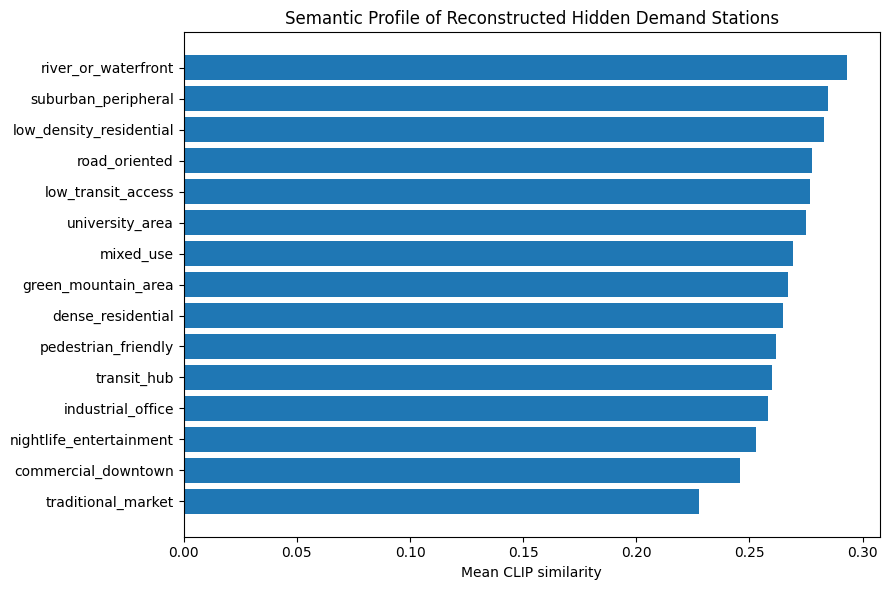

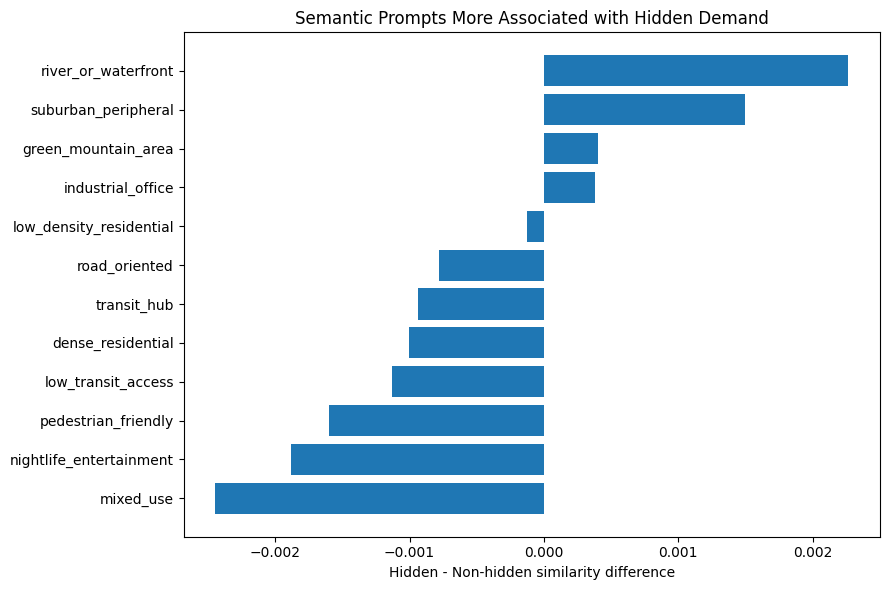


Top hidden demand semantic labels:
 station_id  nearest_station nearest_line               reconstruction_label  hidden_demand_reconstruction_score_norm          top_semantic_1  top_semantic_1_score                                                    top_semantic_3
       2561               마천          5호선        High Priority Hidden Demand                                 1.000000     suburban_peripheral              0.290371 suburban_peripheral; green_mountain_area; low_density_residential
       2824            단대오거리          8호선        High Priority Hidden Demand                                 0.921235     suburban_peripheral              0.287675     suburban_peripheral; low_density_residential; university_area
        249            신정네거리          2호선        High Priority Hidden Demand                                 0.875657 low_density_residential              0.304417 low_density_residential; suburban_peripheral; river_or_waterfront
       2519              까치산          5호선   

In [13]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from glob import glob
from PIL import Image
from tqdm import tqdm

import torch
from transformers import CLIPModel, CLIPProcessor


# ============================================================
# PATHS
# ============================================================

RESULT_DIR = "seoul_station_multimodal/results"
RECON_CSV = f"{RESULT_DIR}/quad_reconstructed_hidden_demand_result.csv"

IMAGE_ROOT = r"/workspace/yunsoyoung_cikm_kdd../images/station_tiles"
MAP_DIR = f"{IMAGE_ROOT}/map"
SAT_DIR = f"{IMAGE_ROOT}/satellite"

OUT_SEMANTIC = f"{RESULT_DIR}/station_semantic_prompt_profile.csv"
OUT_HIDDEN_PROFILE = f"{RESULT_DIR}/hidden_demand_semantic_profile.csv"

os.makedirs(RESULT_DIR, exist_ok=True)

df = pd.read_csv(RECON_CSV)

name_col = "nearest_station" if "nearest_station" in df.columns else "station_name"


# ============================================================
# CONFIG
# ============================================================

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
CLIP_NAME = "openai/clip-vit-base-patch32"
BATCH_SIZE = 64

print("DEVICE:", DEVICE)


# ============================================================
# PROMPTS
# ============================================================

prompts = {
    "dense_residential": "a dense residential neighborhood with many apartment buildings",
    "low_density_residential": "a low density residential neighborhood",
    "commercial_downtown": "a dense commercial downtown district with offices and shops",
    "mixed_use": "a mixed use urban area with residential and commercial buildings",
    "suburban_peripheral": "a suburban peripheral district at the edge of the city",
    "transit_hub": "a major public transit hub with high accessibility",
    "low_transit_access": "an urban area with low public transit accessibility",
    "road_oriented": "a road oriented urban area with wide roads and car traffic",
    "pedestrian_friendly": "a pedestrian friendly walkable neighborhood",
    "green_mountain_area": "an area near mountains, forests, parks, or green space",
    "river_or_waterfront": "an urban area near a river or waterfront",
    "industrial_office": "an industrial or office district with large buildings",
    "university_area": "a university or education oriented neighborhood",
    "nightlife_entertainment": "a nightlife and entertainment district",
    "traditional_market": "a traditional market or local commercial street district",
}


# ============================================================
# UTILS
# ============================================================

def find_image(img_dir, station_id):
    station_id = str(station_id)

    patterns = [
        os.path.join(img_dir, f"{station_id}_*.png"),
        os.path.join(img_dir, f"{station_id}_*.jpg"),
        os.path.join(img_dir, f"{station_id}_*.jpeg"),
    ]

    matches = []
    for p in patterns:
        matches.extend(glob(p))

    return matches[0] if matches else None


def normalize_rows(x):
    return x / np.linalg.norm(x, axis=1, keepdims=True)


# ============================================================
# LOAD CLIP
# ============================================================

print("Loading CLIP...")

model = CLIPModel.from_pretrained(CLIP_NAME).to(DEVICE)
processor = CLIPProcessor.from_pretrained(CLIP_NAME)
model.eval()


# ============================================================
# TEXT PROMPT EMBEDDINGS
# ============================================================

@torch.no_grad()
def encode_texts(texts):
    inputs = processor(
        text=texts,
        return_tensors="pt",
        padding=True,
        truncation=True,
    ).to(DEVICE)

    outputs = model.text_model(
        input_ids=inputs["input_ids"],
        attention_mask=inputs["attention_mask"],
    )

    z = outputs.pooler_output
    z = model.text_projection(z)
    z = torch.nn.functional.normalize(z, dim=-1)

    return z.cpu().numpy()


prompt_names = list(prompts.keys())
prompt_texts = list(prompts.values())

prompt_emb = encode_texts(prompt_texts)

print("Prompt embeddings:", prompt_emb.shape)


# ============================================================
# IMAGE EMBEDDINGS
# ============================================================

@torch.no_grad()
def encode_images(image_paths):
    all_embs = []

    for i in tqdm(range(0, len(image_paths), BATCH_SIZE), desc="Encoding images"):
        batch_paths = image_paths[i:i + BATCH_SIZE]

        images = [
            Image.open(p).convert("RGB").resize((224, 224))
            for p in batch_paths
        ]

        inputs = processor(
            images=images,
            return_tensors="pt",
            padding=True,
        ).to(DEVICE)

        outputs = model.vision_model(
            pixel_values=inputs["pixel_values"]
        )

        z = outputs.pooler_output
        z = model.visual_projection(z)
        z = torch.nn.functional.normalize(z, dim=-1)

        all_embs.append(z.cpu().numpy())

    return np.vstack(all_embs)


df["map_path"] = df["station_id"].apply(lambda x: find_image(MAP_DIR, x))
df["satellite_path"] = df["station_id"].apply(lambda x: find_image(SAT_DIR, x))

valid = df["map_path"].notna() & df["satellite_path"].notna()
df_valid = df[valid].copy()

print("Valid stations:", len(df_valid))

map_emb = encode_images(df_valid["map_path"].tolist())
sat_emb = encode_images(df_valid["satellite_path"].tolist())

# map + satellite 평균 visual semantic embedding
img_emb = normalize_rows((map_emb + sat_emb) / 2)


# ============================================================
# COSINE SIMILARITY: IMAGE ↔ TEXT PROMPTS
# ============================================================

sim = img_emb @ prompt_emb.T

semantic_df = df_valid[
    [
        "station_id",
        name_col,
        "nearest_line",
        "reconstruction_label",
        "hidden_demand_reconstruction_score_norm",
        "quad_mobility_subway_label",
        "quad_hidden_visual_label",
        "quad_temporal_visual_label",
    ]
].copy()

for j, pname in enumerate(prompt_names):
    semantic_df[f"sem_{pname}"] = sim[:, j]

# top semantic labels
sem_cols = [f"sem_{p}" for p in prompt_names]

semantic_df["top_semantic_1"] = semantic_df[sem_cols].idxmax(axis=1).str.replace("sem_", "")
semantic_df["top_semantic_1_score"] = semantic_df[sem_cols].max(axis=1)

semantic_df["top_semantic_3"] = semantic_df[sem_cols].apply(
    lambda r: "; ".join(
        r.sort_values(ascending=False).head(3).index.str.replace("sem_", "").tolist()
    ),
    axis=1
)

semantic_df.to_csv(OUT_SEMANTIC, index=False)

print("Saved semantic profile:", OUT_SEMANTIC)
print(semantic_df.head())


# ============================================================
# HIDDEN DEMAND SEMANTIC PROFILE
# ============================================================

hidden_mask = (
    semantic_df["reconstruction_label"]
    .astype(str)
    .str.contains("Hidden|Potential", case=False, na=False)
)

hidden_profile = (
    semantic_df.loc[hidden_mask, sem_cols]
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)

hidden_profile.columns = ["semantic_prompt", "mean_similarity"]
hidden_profile["semantic_prompt"] = hidden_profile["semantic_prompt"].str.replace("sem_", "")

hidden_profile.to_csv(OUT_HIDDEN_PROFILE, index=False)

print("\nHidden demand semantic profile:")
print(hidden_profile.to_string(index=False))


# ============================================================
# GROUP COMPARISON: HIDDEN VS NON-HIDDEN
# ============================================================

group_rows = []

for col in sem_cols:
    hidden_mean = semantic_df.loc[hidden_mask, col].mean()
    non_hidden_mean = semantic_df.loc[~hidden_mask, col].mean()

    group_rows.append({
        "semantic_prompt": col.replace("sem_", ""),
        "hidden_mean": hidden_mean,
        "non_hidden_mean": non_hidden_mean,
        "difference_hidden_minus_nonhidden": hidden_mean - non_hidden_mean,
    })

group_df = (
    pd.DataFrame(group_rows)
    .sort_values("difference_hidden_minus_nonhidden", ascending=False)
)

group_df.to_csv(f"{RESULT_DIR}/hidden_vs_nonhidden_semantic_difference.csv", index=False)

print("\nHidden vs non-hidden semantic difference:")
print(group_df.to_string(index=False))


# ============================================================
# VISUALIZE HIDDEN SEMANTIC PROFILE
# ============================================================

plt.figure(figsize=(9, 6))
plt.barh(
    hidden_profile["semantic_prompt"][::-1],
    hidden_profile["mean_similarity"][::-1],
)
plt.xlabel("Mean CLIP similarity")
plt.title("Semantic Profile of Reconstructed Hidden Demand Stations")
plt.tight_layout()
plt.savefig(f"{RESULT_DIR}/hidden_demand_semantic_profile.png", dpi=220)
plt.show()


plt.figure(figsize=(9, 6))
top_diff = group_df.head(12)
plt.barh(
    top_diff["semantic_prompt"][::-1],
    top_diff["difference_hidden_minus_nonhidden"][::-1],
)
plt.xlabel("Hidden - Non-hidden similarity difference")
plt.title("Semantic Prompts More Associated with Hidden Demand")
plt.tight_layout()
plt.savefig(f"{RESULT_DIR}/hidden_vs_nonhidden_semantic_difference.png", dpi=220)
plt.show()


# ============================================================
# TOP HIDDEN STATIONS WITH SEMANTIC LABELS
# ============================================================

top_hidden = (
    semantic_df.loc[hidden_mask]
    .sort_values("hidden_demand_reconstruction_score_norm", ascending=False)
    .head(30)
)

cols = [
    "station_id",
    name_col,
    "nearest_line",
    "reconstruction_label",
    "hidden_demand_reconstruction_score_norm",
    "top_semantic_1",
    "top_semantic_1_score",
    "top_semantic_3",
]

top_hidden[cols].to_csv(
    f"{RESULT_DIR}/top_hidden_demand_semantic_labels.csv",
    index=False,
)

print("\nTop hidden demand semantic labels:")
print(top_hidden[cols].to_string(index=False))


# ============================================================
# REPORT
# ============================================================

report_path = f"{RESULT_DIR}/semantic_prompt_report.txt"

with open(report_path, "w", encoding="utf-8") as f:
    f.write("CLIP Semantic Prompt Analysis Report\n")
    f.write("=" * 60 + "\n\n")

    f.write("Prompt set:\n")
    for k, v in prompts.items():
        f.write(f"- {k}: {v}\n")

    f.write("\nHidden demand semantic profile:\n")
    f.write(hidden_profile.to_string(index=False))

    f.write("\n\nHidden vs non-hidden semantic difference:\n")
    f.write(group_df.to_string(index=False))

    f.write("\n\nTop hidden stations with semantic labels:\n")
    f.write(top_hidden[cols].to_string(index=False))

print("\nSaved report:", report_path)
print("DONE.")

In [1]:
# ============================================================
# KDD WORKSHOP FIGURE EXPORT SCRIPT
# Uses EXISTING result CSVs from your KDD pipeline
# Exports all paper-ready figures automatically
# ============================================================

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

RESULT_DIR = "seoul_station_multimodal/results"
FIG_DIR = f"{RESULT_DIR}/paper_figures"

os.makedirs(FIG_DIR, exist_ok=True)

# ============================================================
# LOAD FILES
# ============================================================

recon = pd.read_csv(
    f"{RESULT_DIR}/quad_reconstructed_hidden_demand_result.csv"
)

quad = pd.read_csv(
    f"{RESULT_DIR}/quad_latent_decomposition.csv"
)

baseline = pd.read_csv(
    f"{RESULT_DIR}/baseline_reconstruction_comparison.csv"
)

weights = pd.read_csv(
    f"{RESULT_DIR}/weight_sensitivity_results.csv"
)

robust = pd.read_csv(
    f"{RESULT_DIR}/top_station_robustness.csv"
)

semantic = pd.read_csv(
    f"{RESULT_DIR}/hidden_demand_semantic_profile.csv"
)

semantic_diff = pd.read_csv(
    f"{RESULT_DIR}/hidden_vs_nonhidden_semantic_difference.csv"
)

# ============================================================
# STYLE
# ============================================================

plt.rcParams["font.family"] = "DejaVu Sans"
plt.rcParams["axes.unicode_minus"] = False

# ============================================================
# FIGURE 1
# QUAD RECONSTRUCTION SPACE
# ============================================================

plt.figure(figsize=(8, 7))

labels = recon["reconstruction_label"].astype(str)

for lab in sorted(labels.unique()):
    sub = recon[labels == lab]

    plt.scatter(
        sub["axis_mobility_demand_score"],
        sub["axis_observed_subway_score"],
        s=55,
        alpha=0.75,
        label=lab,
    )

plt.axvline(0.5, linestyle="--", alpha=0.4)
plt.axhline(0.5, linestyle="--", alpha=0.4)

top10 = recon.sort_values(
    "hidden_demand_reconstruction_score_norm",
    ascending=False
).head(10)

for _, row in top10.iterrows():
    plt.text(
        row["axis_mobility_demand_score"],
        row["axis_observed_subway_score"],
        str(row["nearest_station"]),
        fontsize=8,
    )

plt.xlabel("Mobility Demand Score")
plt.ylabel("Observed Subway Score")
plt.title("QuadHDR Reconstruction Space")
plt.legend(fontsize=8)

plt.tight_layout()
plt.savefig(
    f"{FIG_DIR}/figure1_quad_reconstruction_space.png",
    dpi=300,
    bbox_inches="tight",
)
plt.close()

# ============================================================
# FIGURE 2
# BASELINE COMPARISON
# ============================================================

baseline = baseline.sort_values(
    "spearman_with_gap",
    ascending=True,
)

plt.figure(figsize=(8, 5))

plt.barh(
    baseline["method"],
    baseline["spearman_with_gap"],
)

plt.xlabel("Spearman Correlation")
plt.ylabel("Method")
plt.title("Baseline Comparison")

plt.tight_layout()
plt.savefig(
    f"{FIG_DIR}/figure2_baseline_comparison.png",
    dpi=300,
    bbox_inches="tight",
)
plt.close()

# ============================================================
# FIGURE 3
# WEIGHT SENSITIVITY DISTRIBUTION
# ============================================================

plt.figure(figsize=(7, 5))

plt.hist(
    weights["spearman_with_gap"],
    bins=20,
)

plt.xlabel("Spearman Correlation")
plt.ylabel("Frequency")
plt.title("Weight Sensitivity Distribution")

plt.tight_layout()
plt.savefig(
    f"{FIG_DIR}/figure3_weight_sensitivity_distribution.png",
    dpi=300,
    bbox_inches="tight",
)
plt.close()

# ============================================================
# FIGURE 4
# ROBUST TOP STATIONS
# ============================================================

robust = robust.sort_values(
    "top10_frequency",
    ascending=True,
).tail(15)

plt.figure(figsize=(8, 6))

plt.barh(
    robust["station_name"],
    robust["top10_frequency"],
)

plt.xlabel("Top-10 Frequency")
plt.ylabel("Station")
plt.title("Robust Hidden-Demand Stations")

plt.tight_layout()
plt.savefig(
    f"{FIG_DIR}/figure4_station_robustness.png",
    dpi=300,
    bbox_inches="tight",
)
plt.close()

# ============================================================
# FIGURE 5
# SEMANTIC PROFILE
# ============================================================

semantic = semantic.sort_values(
    "mean_similarity",
    ascending=True,
)

plt.figure(figsize=(8, 6))

plt.barh(
    semantic["semantic_prompt"],
    semantic["mean_similarity"],
)

plt.xlabel("Mean Similarity")
plt.ylabel("Semantic Prompt")
plt.title("Hidden-Demand Semantic Profile")

plt.tight_layout()
plt.savefig(
    f"{FIG_DIR}/figure5_semantic_profile.png",
    dpi=300,
    bbox_inches="tight",
)
plt.close()

# ============================================================
# FIGURE 6
# HIDDEN VS NON-HIDDEN
# ============================================================

semantic_diff = semantic_diff.sort_values(
    "difference_hidden_minus_nonhidden",
    ascending=True,
)

plt.figure(figsize=(8, 6))

plt.barh(
    semantic_diff["semantic_prompt"],
    semantic_diff["difference_hidden_minus_nonhidden"],
)

plt.xlabel("Hidden - NonHidden Difference")
plt.ylabel("Semantic Prompt")
plt.title("Semantic Difference Analysis")

plt.tight_layout()
plt.savefig(
    f"{FIG_DIR}/figure6_hidden_vs_nonhidden.png",
    dpi=300,
    bbox_inches="tight",
)
plt.close()

# ============================================================
# FIGURE 7
# PCA CLUSTER SPACE
# ============================================================

if "pca_x" in quad.columns and "pca_y" in quad.columns:

    plt.figure(figsize=(8, 7))

    scatter = plt.scatter(
        quad["pca_x"],
        quad["pca_y"],
        c=quad["cluster"],
        s=45,
        alpha=0.8,
    )

    plt.xlabel("PCA-1")
    plt.ylabel("PCA-2")
    plt.title("Multimodal Cluster Space")

    plt.colorbar(scatter)

    plt.tight_layout()
    plt.savefig(
        f"{FIG_DIR}/figure7_multimodal_cluster_space.png",
        dpi=300,
        bbox_inches="tight",
    )
    plt.close()

# ============================================================
# FIGURE 8
# RECONSTRUCTION SCORE DISTRIBUTION
# ============================================================

plt.figure(figsize=(7, 5))

plt.hist(
    recon["hidden_demand_reconstruction_score_norm"],
    bins=25,
)

plt.xlabel("Normalized Reconstruction Score")
plt.ylabel("Frequency")
plt.title("Hidden-Demand Reconstruction Score Distribution")

plt.tight_layout()
plt.savefig(
    f"{FIG_DIR}/figure8_reconstruction_distribution.png",
    dpi=300,
    bbox_inches="tight",
)
plt.close()

# ============================================================
# FIGURE 9
# TOP RECONSTRUCTED STATIONS
# ============================================================

top20 = recon.sort_values(
    "hidden_demand_reconstruction_score_norm",
    ascending=False,
).head(20)

top20 = top20.iloc[::-1]

plt.figure(figsize=(8, 7))

plt.barh(
    top20["nearest_station"],
    top20["hidden_demand_reconstruction_score_norm"],
)

plt.xlabel("Normalized Reconstruction Score")
plt.ylabel("Station")
plt.title("Top Reconstructed Hidden-Demand Stations")

plt.tight_layout()
plt.savefig(
    f"{FIG_DIR}/figure9_top_hidden_stations.png",
    dpi=300,
    bbox_inches="tight",
)
plt.close()

# ============================================================
# FIGURE 10
# QUAD SIGNATURE DISTRIBUTION
# ============================================================

quad_count = (
    quad["quad_signature"]
    .value_counts()
    .head(15)
    .sort_values()
)

plt.figure(figsize=(9, 6))

plt.barh(
    quad_count.index,
    quad_count.values,
)

plt.xlabel("Count")
plt.ylabel("Quad Signature")
plt.title("Quad Signature Distribution")

plt.tight_layout()
plt.savefig(
    f"{FIG_DIR}/figure10_quad_signature_distribution.png",
    dpi=300,
    bbox_inches="tight",
)
plt.close()

# ============================================================
# SAVE FIGURE CAPTIONS
# ============================================================

captions = """
Figure 1. QuadHDR reconstruction space.

Figure 2. Baseline comparison against reconstruction methods.

Figure 3. Weight sensitivity distribution.

Figure 4. Robust hidden-demand stations across weight settings.

Figure 5. Semantic profile of hidden-demand stations.

Figure 6. Semantic difference between hidden and non-hidden stations.

Figure 7. Multimodal PCA cluster space.

Figure 8. Distribution of reconstruction scores.

Figure 9. Top reconstructed hidden-demand stations.

Figure 10. Distribution of quad signatures.
"""

with open(
    f"{FIG_DIR}/figure_captions.txt",
    "w",
    encoding="utf-8",
) as f:
    f.write(captions)

print("\nDONE.")
print("Figures saved to:")
print(FIG_DIR)

/tmp/ipykernel_5623/4020512689.py:97: UserWarning: Glyph 47560 (\N{HANGUL SYLLABLE MA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_5623/4020512689.py:97: UserWarning: Glyph 52380 (\N{HANGUL SYLLABLE CEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_5623/4020512689.py:97: UserWarning: Glyph 45800 (\N{HANGUL SYLLABLE DAN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_5623/4020512689.py:97: UserWarning: Glyph 45824 (\N{HANGUL SYLLABLE DAE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_5623/4020512689.py:97: UserWarning: Glyph 50724 (\N{HANGUL SYLLABLE O}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_5623/4020512689.py:97: UserWarning: Glyph 44144 (\N{HANGUL SYLLABLE GEO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_5623/4020512689.py:97: UserWarning: Glyph 47532 (\N{HANGUL SYLLABLE RI}) missing from font(s) DejaVu Sans.
  plt.tight_layo


DONE.
Figures saved to:
seoul_station_multimodal/results/paper_figures


In [2]:
# ============================================================
# AUTO KDD FIGURE BUILDER
# Automatically scans result directory
# and generates publication-ready figures
# ============================================================

import os
import glob
import pandas as pd
import matplotlib.pyplot as plt

RESULT_DIR = "seoul_station_multimodal/results"

print("=" * 60)
print("AUTO KDD FIGURE BUILDER")
print("=" * 60)

# ============================================================
# FIND FILES
# ============================================================

csv_files = glob.glob(f"{RESULT_DIR}/*.csv")
png_files = glob.glob(f"{RESULT_DIR}/*.png")

print("\n[CSV FILES]")
for x in csv_files:
    print(x)

print("\n[PNG FILES]")
for x in png_files:
    print(x)

# ============================================================
# FIGURE SAVE UTIL
# ============================================================

def savefig(name):
    path = f"{RESULT_DIR}/{name}"
    plt.tight_layout()
    plt.savefig(path, dpi=300, bbox_inches="tight")
    plt.close()
    print("Saved:", path)

# ============================================================
# 1. BASELINE COMPARISON
# ============================================================

baseline_path = f"{RESULT_DIR}/baseline_reconstruction_comparison.csv"

if os.path.exists(baseline_path):

    df = pd.read_csv(baseline_path)

    plt.figure(figsize=(8,5))

    df = df.sort_values(
        "spearman_with_gap",
        ascending=True,
    )

    plt.barh(
        df["method"],
        df["spearman_with_gap"],
    )

    plt.xlabel("Spearman Correlation")
    plt.title("Baseline Comparison")

    savefig("paper_baseline_comparison.png")

# ============================================================
# 2. WEIGHT SENSITIVITY
# ============================================================

weight_path = f"{RESULT_DIR}/weight_sensitivity_results.csv"

if os.path.exists(weight_path):

    df = pd.read_csv(weight_path)

    plt.figure(figsize=(7,5))

    plt.hist(
        df["spearman_with_gap"],
        bins=20,
    )

    plt.xlabel("Spearman Correlation")
    plt.ylabel("Count")

    plt.title("Weight Sensitivity Distribution")

    savefig("paper_weight_sensitivity.png")

# ============================================================
# 3. ROBUSTNESS
# ============================================================

robust_path = f"{RESULT_DIR}/top_station_robustness.csv"

if os.path.exists(robust_path):

    df = pd.read_csv(robust_path)

    df = df.sort_values(
        "top10_frequency",
        ascending=False,
    ).head(15)

    # 영어 fallback
    if "station_name" in df.columns:
        names = df["station_name"].astype(str)
    else:
        names = [f"station_{i}" for i in range(len(df))]

    plt.figure(figsize=(8,6))

    plt.barh(
        names[::-1],
        df["top10_frequency"][::-1],
    )

    plt.xlabel("Top-10 Frequency")
    plt.title("Robust Hidden-Demand Stations")

    savefig("paper_station_robustness.png")

# ============================================================
# 4. SEMANTIC PROFILE
# ============================================================

semantic_path = (
    f"{RESULT_DIR}/hidden_demand_semantic_profile.csv"
)

if os.path.exists(semantic_path):

    df = pd.read_csv(semantic_path)

    df = df.sort_values(
        "mean_similarity",
        ascending=True,
    )

    plt.figure(figsize=(8,6))

    plt.barh(
        df["semantic_prompt"],
        df["mean_similarity"],
    )

    plt.xlabel("Mean Similarity")
    plt.title("Hidden-Demand Semantic Profile")

    savefig("paper_semantic_profile.png")

# ============================================================
# 5. SEMANTIC DIFFERENCE
# ============================================================

diff_path = (
    f"{RESULT_DIR}/hidden_vs_nonhidden_semantic_difference.csv"
)

if os.path.exists(diff_path):

    df = pd.read_csv(diff_path)

    df = df.sort_values(
        "difference_hidden_minus_nonhidden",
        ascending=True,
    )

    plt.figure(figsize=(8,6))

    plt.barh(
        df["semantic_prompt"],
        df["difference_hidden_minus_nonhidden"],
    )

    plt.xlabel("Hidden - NonHidden")
    plt.title("Semantic Difference")

    savefig("paper_semantic_difference.png")

# ============================================================
# 6. QUAD RECONSTRUCTION SPACE
# ============================================================

recon_path = (
    f"{RESULT_DIR}/quad_reconstructed_hidden_demand_result.csv"
)

if os.path.exists(recon_path):

    df = pd.read_csv(recon_path)

    plt.figure(figsize=(8,7))

    for label, sub in df.groupby("reconstruction_label"):

        plt.scatter(
            sub["axis_mobility_demand_score"],
            sub["axis_observed_subway_score"],
            alpha=0.75,
            s=45,
            label=label,
        )

    plt.axvline(0.5, linestyle="--", alpha=0.4)
    plt.axhline(0.5, linestyle="--", alpha=0.4)

    plt.xlabel("Mobility Demand")
    plt.ylabel("Observed Subway")

    plt.title("QuadHDR Reconstruction Space")

    plt.legend(fontsize=7)

    savefig("paper_quad_reconstruction_space.png")

# ============================================================
# 7. TOP HIDDEN STATIONS
# ============================================================

if os.path.exists(recon_path):

    df = pd.read_csv(recon_path)

    top20 = df.sort_values(
        "hidden_demand_reconstruction_score_norm",
        ascending=False,
    ).head(20)

    if "nearest_station" in top20.columns:
        names = top20["nearest_station"].astype(str)
    else:
        names = [f"station_{i}" for i in range(len(top20))]

    plt.figure(figsize=(8,7))

    plt.barh(
        names[::-1],
        top20[
            "hidden_demand_reconstruction_score_norm"
        ][::-1],
    )

    plt.xlabel("Reconstruction Score")

    plt.title("Top Hidden-Demand Stations")

    savefig("paper_top_hidden_stations.png")

# ============================================================
# 8. PCA CLUSTER SPACE
# ============================================================

cluster_path = (
    f"{RESULT_DIR}/multimodal_cluster_result.csv"
)

if os.path.exists(cluster_path):

    df = pd.read_csv(cluster_path)

    if (
        "pca_x" in df.columns
        and "pca_y" in df.columns
        and "cluster" in df.columns
    ):

        plt.figure(figsize=(8,7))

        scatter = plt.scatter(
            df["pca_x"],
            df["pca_y"],
            c=df["cluster"],
            s=40,
            alpha=0.8,
        )

        plt.xlabel("PCA-1")
        plt.ylabel("PCA-2")

        plt.title("Multimodal Cluster Space")

        plt.colorbar(scatter)

        savefig("paper_multimodal_cluster_space.png")

print("\nDONE.")
print("Paper figures exported.")

AUTO KDD FIGURE BUILDER

[CSV FILES]
seoul_station_multimodal/results/case_study_top_hidden_demand_table_en.csv
seoul_station_multimodal/results/exp_visual_pca8_only_ev0.35.csv
seoul_station_multimodal/results/experiment_mobility_only.csv
seoul_station_multimodal/results/multimodal_feature_table.csv
seoul_station_multimodal/results/experiment_mobility_visual_pca16.csv
seoul_station_multimodal/results/exp_mobility_visual_pca8_alpha0.1.csv
seoul_station_multimodal/results/quad_signature_summary.csv
seoul_station_multimodal/results/experiment_mobility_visual_pca64.csv
seoul_station_multimodal/results/exp_visual_pca2_only_ev0.17.csv
seoul_station_multimodal/results/exp_mobility_visual_pca32_alpha0.05.csv
seoul_station_multimodal/results/reconstruction_label_summary.csv
seoul_station_multimodal/results/cluster_representative_stations.csv
seoul_station_multimodal/results/exp_visual_pca32_only_ev0.63.csv
seoul_station_multimodal/results/mobility_visual_similarity_pca8.csv
seoul_station_multim

/tmp/ipykernel_5623/341288198.py:39: UserWarning: Glyph 44060 (\N{HANGUL SYLLABLE GAE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_5623/341288198.py:39: UserWarning: Glyph 54868 (\N{HANGUL SYLLABLE HWA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_5623/341288198.py:39: UserWarning: Glyph 49888 (\N{HANGUL SYLLABLE SIN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_5623/341288198.py:39: UserWarning: Glyph 51473 (\N{HANGUL SYLLABLE JUNG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_5623/341288198.py:39: UserWarning: Glyph 46041 (\N{HANGUL SYLLABLE DONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_5623/341288198.py:39: UserWarning: Glyph 50521 (\N{HANGUL SYLLABLE ANG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_5623/341288198.py:39: UserWarning: Glyph 48372 (\N{HANGUL SYLLABLE BO}) missing from font(s) DejaVu Sans.
  plt.tight_layout(

Saved: seoul_station_multimodal/results/paper_station_robustness.png
Saved: seoul_station_multimodal/results/paper_semantic_profile.png
Saved: seoul_station_multimodal/results/paper_semantic_difference.png
Saved: seoul_station_multimodal/results/paper_quad_reconstruction_space.png


/tmp/ipykernel_5623/341288198.py:39: UserWarning: Glyph 52384 (\N{HANGUL SYLLABLE CEOL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_5623/341288198.py:39: UserWarning: Glyph 49328 (\N{HANGUL SYLLABLE SAN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_5623/341288198.py:39: UserWarning: Glyph 49888 (\N{HANGUL SYLLABLE SIN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_5623/341288198.py:39: UserWarning: Glyph 51473 (\N{HANGUL SYLLABLE JUNG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_5623/341288198.py:39: UserWarning: Glyph 46041 (\N{HANGUL SYLLABLE DONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_5623/341288198.py:39: UserWarning: Glyph 47785 (\N{HANGUL SYLLABLE MOG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_5623/341288198.py:39: UserWarning: Glyph 51025 (\N{HANGUL SYLLABLE EUNG}) missing from font(s) DejaVu Sans.
  plt.tight_layo

Saved: seoul_station_multimodal/results/paper_top_hidden_stations.png
Saved: seoul_station_multimodal/results/paper_multimodal_cluster_space.png

DONE.
Paper figures exported.


In [1]:
# ============================================================
# AUTO KDD FIGURE BUILDER - ENGLISH ONLY VERSION
# Reads existing result files and exports paper-ready figures
# ============================================================

import os
import glob
import warnings
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# CONFIG
# ============================================================

RESULT_DIR = "seoul_station_multimodal/results"
FIG_DIR = f"{RESULT_DIR}/paper_figures_en"

os.makedirs(FIG_DIR, exist_ok=True)

plt.rcParams["font.family"] = "DejaVu Sans"
plt.rcParams["axes.unicode_minus"] = False
warnings.filterwarnings("ignore", category=UserWarning)

# ============================================================
# STATION NAME ENGLISH MAPPING
# ============================================================

station_name_map = {
    "마천": "Macheon",
    "단대오거리": "Dandaeogeori",
    "신정네거리": "Sinjeongnegeori",
    "까치산": "Kkachisan",
    "부천시청": "Bucheon City Hall",
    "남한산성입구(성남법원.검찰청)": "Namhansanseong",
    "거여": "Geoyeo",
    "북한산보국문": "Bukhansan Bogungmun",
    "가양": "Gayang",
    "양천구청": "Yangcheon-gu Office",
    "홍제": "Hongje",
    "광명사거리": "Gwangmyeongsageori",
    "중앙보훈병원": "VHS Medical Center",
    "신중동": "Sinjung-dong",
    "개화": "Gaehwa",
    "신목동": "Sinmokdong",
    "장지": "Jangji",
    "수진": "Sujin",
    "등촌": "Deungchon",
    "일원": "Irwon",
    "신흥": "Sinheung",
    "용마산": "Yongmasan",
    "매봉": "Maebong",
    "장한평": "Janghanpyeong",
    "구파발": "Gupabal",
    "양천향교": "Yangcheon Hyanggyo",
    "철산": "Cheolsan",
    "중계": "Junggye",
    "응암": "Eungam",
    "고덕": "Godeok",
    "상계": "Sanggye",
    "화곡": "Hwagok",
    "대흥(서강대앞)": "Daeheung",
    "우장산": "Ujangsan",
    "쌍문": "Ssangmun",
    "남성": "Namseong",
    "역삼": "Yeoksam",
    "봉은사": "Bongeunsa",
    "발산": "Balsan",
}

def station_en(x):
    x = str(x)
    return station_name_map.get(x, x.encode("ascii", "ignore").decode() or "Station")

def method_en(x):
    mapping = {
        "subway_inverse_only": "Subway Inverse",
        "mobility_only": "Mobility Only",
        "hidden_gap_only": "Hidden Gap Only",
        "temporal_only": "Temporal Only",
        "visual_only": "Visual Only",
        "mobility_minus_subway": "Mobility - Subway",
        "quad_reconstruction": "QuadHDR",
    }
    return mapping.get(str(x), str(x).replace("_", " ").title())

def prompt_en(x):
    return str(x).replace("_", " ").title()

def savefig(filename):
    path = f"{FIG_DIR}/{filename}"
    plt.tight_layout()
    plt.savefig(path, dpi=300, bbox_inches="tight")
    plt.close()
    print("Saved:", path)

# ============================================================
# CHECK EXISTING FILES
# ============================================================

print("=" * 60)
print("AUTO KDD FIGURE BUILDER - ENGLISH ONLY")
print("=" * 60)

print("\nExisting CSV files:")
for p in sorted(glob.glob(f"{RESULT_DIR}/*.csv")):
    print(" -", p)

print("\nExisting PNG files:")
for p in sorted(glob.glob(f"{RESULT_DIR}/*.png")):
    print(" -", p)

# ============================================================
# 1. QUAD RECONSTRUCTION SPACE
# ============================================================

recon_path = f"{RESULT_DIR}/quad_reconstructed_hidden_demand_result.csv"

if os.path.exists(recon_path):
    recon = pd.read_csv(recon_path)

    name_col = "nearest_station" if "nearest_station" in recon.columns else "station_name"
    recon["station_name_en"] = recon[name_col].apply(station_en)

    plt.figure(figsize=(8.5, 7))

    for label, sub in recon.groupby("reconstruction_label"):
        plt.scatter(
            sub["axis_mobility_demand_score"],
            sub["axis_observed_subway_score"],
            s=48,
            alpha=0.75,
            label=label,
        )

    plt.axvline(0.5, linestyle="--", linewidth=1, alpha=0.4)
    plt.axhline(0.5, linestyle="--", linewidth=1, alpha=0.4)

    top8 = recon.sort_values(
        "hidden_demand_reconstruction_score_norm",
        ascending=False
    ).head(8)

    for _, row in top8.iterrows():
        plt.text(
            row["axis_mobility_demand_score"],
            row["axis_observed_subway_score"],
            row["station_name_en"],
            fontsize=8,
        )

    plt.xlabel("Mobility Demand Score")
    plt.ylabel("Observed Subway Score")
    plt.title("QuadHDR Reconstruction Space")
    plt.legend(fontsize=7)
    savefig("fig1_quad_reconstruction_space.png")

# ============================================================
# 2. TOP HIDDEN-DEMAND STATIONS
# ============================================================

if os.path.exists(recon_path):
    recon = pd.read_csv(recon_path)

    name_col = "nearest_station" if "nearest_station" in recon.columns else "station_name"
    recon["station_name_en"] = recon[name_col].apply(station_en)

    top20 = recon.sort_values(
        "hidden_demand_reconstruction_score_norm",
        ascending=False
    ).head(20)

    plt.figure(figsize=(8, 7))
    plt.barh(
        top20["station_name_en"][::-1],
        top20["hidden_demand_reconstruction_score_norm"][::-1],
    )
    plt.xlabel("Normalized Hidden-Demand Reconstruction Score")
    plt.ylabel("Station")
    plt.title("Top Reconstructed Hidden-Demand Stations")
    savefig("fig2_top_hidden_demand_stations.png")

# ============================================================
# 3. BASELINE COMPARISON
# ============================================================

baseline_path = f"{RESULT_DIR}/baseline_reconstruction_comparison.csv"

if os.path.exists(baseline_path):
    baseline = pd.read_csv(baseline_path)
    baseline["method_en"] = baseline["method"].apply(method_en)

    baseline = baseline.sort_values("spearman_with_gap", ascending=True)

    plt.figure(figsize=(8, 5))
    plt.barh(
        baseline["method_en"],
        baseline["spearman_with_gap"],
    )
    plt.xlabel("Spearman Correlation with Mobility-Subway Gap")
    plt.ylabel("Method")
    plt.title("Baseline Comparison for Hidden-Demand Reconstruction")
    savefig("fig3_baseline_comparison.png")

# ============================================================
# 4. WEIGHT SENSITIVITY
# ============================================================

weight_path = f"{RESULT_DIR}/weight_sensitivity_results.csv"

if os.path.exists(weight_path):
    weights = pd.read_csv(weight_path)

    plt.figure(figsize=(7, 5))
    plt.hist(
        weights["spearman_with_gap"],
        bins=20,
    )
    plt.xlabel("Spearman Correlation with Mobility-Subway Gap")
    plt.ylabel("Number of Weight Settings")
    plt.title("Weight Sensitivity Distribution")
    savefig("fig4_weight_sensitivity_distribution.png")

# ============================================================
# 5. TOP STATION ROBUSTNESS
# ============================================================

robust_path = f"{RESULT_DIR}/top_station_robustness.csv"

if os.path.exists(robust_path):
    robust = pd.read_csv(robust_path)

    robust["station_name_en"] = robust["station_name"].apply(station_en)
    robust = robust.sort_values(
        "top10_frequency",
        ascending=False
    ).head(15)

    plt.figure(figsize=(8, 6))
    plt.barh(
        robust["station_name_en"][::-1],
        robust["top10_frequency"][::-1],
    )
    plt.xlabel("Top-10 Appearance Frequency Across Weight Settings")
    plt.ylabel("Station")
    plt.title("Robust Hidden-Demand Stations")
    savefig("fig5_top_station_robustness.png")

# ============================================================
# 6. SEMANTIC PROFILE
# ============================================================

semantic_path = f"{RESULT_DIR}/hidden_demand_semantic_profile.csv"

if os.path.exists(semantic_path):
    sem = pd.read_csv(semantic_path)

    sem["semantic_prompt_en"] = sem["semantic_prompt"].apply(prompt_en)
    sem = sem.sort_values("mean_similarity", ascending=True)

    plt.figure(figsize=(8, 6))
    plt.barh(
        sem["semantic_prompt_en"],
        sem["mean_similarity"],
    )
    plt.xlabel("Mean CLIP Similarity")
    plt.ylabel("Semantic Prompt")
    plt.title("Semantic Profile of Hidden-Demand Stations")
    savefig("fig6_hidden_demand_semantic_profile.png")

# ============================================================
# 7. HIDDEN VS NON-HIDDEN SEMANTIC DIFFERENCE
# ============================================================

diff_path = f"{RESULT_DIR}/hidden_vs_nonhidden_semantic_difference.csv"

if os.path.exists(diff_path):
    diff = pd.read_csv(diff_path)

    diff["semantic_prompt_en"] = diff["semantic_prompt"].apply(prompt_en)
    diff = diff.sort_values(
        "difference_hidden_minus_nonhidden",
        ascending=True,
    )

    plt.figure(figsize=(8, 6))
    plt.barh(
        diff["semantic_prompt_en"],
        diff["difference_hidden_minus_nonhidden"],
    )
    plt.xlabel("Hidden - Non-Hidden Mean Similarity")
    plt.ylabel("Semantic Prompt")
    plt.title("Semantic Difference Between Hidden and Non-Hidden Stations")
    savefig("fig7_hidden_vs_nonhidden_semantic_difference.png")

# ============================================================
# 8. MULTIMODAL CLUSTER PCA SPACE
# ============================================================

cluster_path = f"{RESULT_DIR}/multimodal_cluster_result.csv"

if os.path.exists(cluster_path):
    cluster = pd.read_csv(cluster_path)

    if {"pca_x", "pca_y", "cluster"}.issubset(cluster.columns):
        plt.figure(figsize=(8, 7))
        scatter = plt.scatter(
            cluster["pca_x"],
            cluster["pca_y"],
            c=cluster["cluster"],
            s=42,
            alpha=0.8,
        )
        plt.xlabel("PCA Dimension 1")
        plt.ylabel("PCA Dimension 2")
        plt.title("Multimodal Cluster PCA Space")
        plt.colorbar(scatter, label="Cluster")
        savefig("fig8_multimodal_cluster_pca_space.png")

# ============================================================
# 9. RECONSTRUCTION SCORE DISTRIBUTION
# ============================================================

if os.path.exists(recon_path):
    recon = pd.read_csv(recon_path)

    plt.figure(figsize=(7, 5))
    plt.hist(
        recon["hidden_demand_reconstruction_score_norm"],
        bins=25,
    )
    plt.xlabel("Normalized Hidden-Demand Reconstruction Score")
    plt.ylabel("Number of Stations")
    plt.title("Distribution of Hidden-Demand Reconstruction Scores")
    savefig("fig9_reconstruction_score_distribution.png")

# ============================================================
# 10. QUAD SIGNATURE DISTRIBUTION
# ============================================================

quad_path = f"{RESULT_DIR}/quad_latent_decomposition.csv"

if os.path.exists(quad_path):
    quad = pd.read_csv(quad_path)

    if "quad_signature" in quad.columns:
        sig = (
            quad["quad_signature"]
            .value_counts()
            .head(15)
            .sort_values(ascending=True)
        )

        plt.figure(figsize=(8, 6))
        plt.barh(
            sig.index.astype(str),
            sig.values,
        )
        plt.xlabel("Number of Stations")
        plt.ylabel("Quad Signature")
        plt.title("Distribution of Quad Signatures")
        savefig("fig10_quad_signature_distribution.png")

# ============================================================
# 11. CASE STUDY MULTI-PANEL FIGURE
# ============================================================

IMAGE_ROOT = "/workspace/yunsoyoung_cikm_kdd../images/station_tiles"
MAP_DIR = f"{IMAGE_ROOT}/map"
SAT_DIR = f"{IMAGE_ROOT}/satellite"

def find_station_image(img_dir, station_id):
    patterns = [
        os.path.join(img_dir, f"{station_id}_*.png"),
        os.path.join(img_dir, f"{station_id}_*.jpg"),
        os.path.join(img_dir, f"{station_id}_*.jpeg"),
    ]
    matches = []
    for p in patterns:
        matches.extend(glob.glob(p))
    return matches[0] if matches else None

if os.path.exists(recon_path):
    from PIL import Image

    recon = pd.read_csv(recon_path)
    name_col = "nearest_station" if "nearest_station" in recon.columns else "station_name"
    recon["station_name_en"] = recon[name_col].apply(station_en)

    top_df = recon.sort_values(
        "hidden_demand_reconstruction_score_norm",
        ascending=False
    ).head(5).copy()

    score_cols = [
        "axis_mobility_demand_score",
        "axis_hidden_gap_score",
        "axis_temporal_dynamics_score",
        "axis_visual_morphology_score",
        "axis_observed_subway_score",
    ]

    score_labels = [
        "Mobility",
        "Hidden Gap",
        "Temporal",
        "Visual",
        "Observed Subway",
    ]

    fig, axes = plt.subplots(
        len(top_df),
        3,
        figsize=(14, 3.2 * len(top_df)),
        gridspec_kw={"width_ratios": [1.2, 1.2, 1.8]},
    )

    if len(top_df) == 1:
        axes = axes.reshape(1, -1)

    for i, (_, row) in enumerate(top_df.iterrows()):
        sid = row["station_id"]
        name = row["station_name_en"]

        map_path = find_station_image(MAP_DIR, sid)
        sat_path = find_station_image(SAT_DIR, sid)

        ax = axes[i, 0]
        if map_path and os.path.exists(map_path):
            ax.imshow(Image.open(map_path).convert("RGB"))
        ax.axis("off")
        ax.set_title(f"Map\n{name}", fontsize=10)

        ax = axes[i, 1]
        if sat_path and os.path.exists(sat_path):
            ax.imshow(Image.open(sat_path).convert("RGB"))
        ax.axis("off")
        ax.set_title("Satellite", fontsize=10)

        ax = axes[i, 2]
        vals = [row[c] for c in score_cols]
        ax.barh(score_labels, vals)
        ax.set_xlim(0, 1)
        ax.invert_yaxis()
        ax.grid(axis="x", alpha=0.3)
        ax.set_title(
            f"Rank {int(row['priority_rank'])}: {name}\n"
            f"{row['reconstruction_label']} | Score={row['hidden_demand_reconstruction_score_norm']:.3f}",
            fontsize=10,
        )

    plt.tight_layout()
    plt.savefig(
        f"{FIG_DIR}/fig11_case_study_top_hidden_demand.png",
        dpi=300,
        bbox_inches="tight",
    )
    plt.close()
    print("Saved:", f"{FIG_DIR}/fig11_case_study_top_hidden_demand.png")

    top_df[
        [
            "priority_rank",
            "station_id",
            "station_name_en",
            "nearest_line",
            "reconstruction_label",
            "hidden_demand_reconstruction_score_norm",
            "axis_mobility_demand_score",
            "axis_observed_subway_score",
            "axis_hidden_gap_score",
            "axis_temporal_dynamics_score",
            "axis_visual_morphology_score",
        ]
    ].to_csv(
        f"{FIG_DIR}/case_study_top_hidden_demand_table_en.csv",
        index=False,
    )

# ============================================================
# CAPTION FILE
# ============================================================

captions = """
Figure 1. QuadHDR reconstruction space.
Figure 2. Top reconstructed hidden-demand stations.
Figure 3. Baseline comparison for hidden-demand reconstruction.
Figure 4. Weight sensitivity distribution.
Figure 5. Robust hidden-demand stations across weight settings.
Figure 6. Semantic profile of hidden-demand stations.
Figure 7. Semantic difference between hidden and non-hidden stations.
Figure 8. Multimodal cluster PCA space.
Figure 9. Distribution of hidden-demand reconstruction scores.
Figure 10. Distribution of quad signatures.
Figure 11. Representative case studies of reconstructed hidden-demand stations.
"""

caption_path = f"{FIG_DIR}/paper_figure_captions_en.txt"

with open(caption_path, "w", encoding="utf-8") as f:
    f.write(captions)

print("Saved:", caption_path)

print("\nDONE.")
print("English-only paper figures saved to:")
print(FIG_DIR)

AUTO KDD FIGURE BUILDER - ENGLISH ONLY

Existing CSV files:
 - seoul_station_multimodal/results/ablation_mobility_only.csv
 - seoul_station_multimodal/results/ablation_mobility_visual.csv
 - seoul_station_multimodal/results/ablation_summary.csv
 - seoul_station_multimodal/results/ablation_visual_only.csv
 - seoul_station_multimodal/results/all_fusion_experiments_summary.csv
 - seoul_station_multimodal/results/baseline_reconstruction_comparison.csv
 - seoul_station_multimodal/results/case_study_top_hidden_demand_table.csv
 - seoul_station_multimodal/results/case_study_top_hidden_demand_table_en.csv
 - seoul_station_multimodal/results/cluster_agreement_ari_nmi.csv
 - seoul_station_multimodal/results/cluster_interpretation_summary.csv
 - seoul_station_multimodal/results/cluster_profile.csv
 - seoul_station_multimodal/results/cluster_representative_stations.csv
 - seoul_station_multimodal/results/exp_mobility_only.csv
 - seoul_station_multimodal/results/exp_mobility_visual_pca128.csv
 - se

In [2]:
import shutil
from IPython.display import FileLink, display

ZIP_PATH = OUT_DIR / "paper_figures_compact.zip"

if ZIP_PATH.exists():
    ZIP_PATH.unlink()

shutil.make_archive(
    base_name=str(ZIP_PATH.with_suffix("")),
    format="zip",
    root_dir=FIG_DIR
)

print("Download ZIP:")
display(FileLink(ZIP_PATH))

NameError: name 'OUT_DIR' is not defined